# Install

In [ ]:
!pip install rioxarray pystac_client planetary_computer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.2/62.2 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.8/206.8 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 86.2 MB/s eta 0:00:00


In [ ]:
#@title Mount
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
#@title Import Libraries
import warnings
warnings.filterwarnings('ignore')

import os
import glob
from tqdm import tqdm
import itertools
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import datetime
import xarray as xr
import rioxarray as rxr
import geopandas as gpd
import rasterio
from rasterio import windows
from rasterio import features
from rasterio import warp
from rasterio.warp import transform_bounds
from rasterio.windows import from_bounds
from scipy.signal import convolve2d
from PIL import Image
from pyproj import Proj, Transformer, CRS
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam
import pystac_client
import planetary_computer as pc
from pystac.extensions.eo import EOExtension as eo



# Constants

In [ ]:
# NOTE: change this directory to your data directory if you rerun it
DATA_PATH = "/content/drive/MyDrive/uhi/Code/Data"

UHI_DATA_FILE = f"{DATA_PATH}/Training_data_uhi_index_2025-02-18.csv"
SATELLITE_DATA = f"{DATA_PATH}/S2_median_fullBands_indeces.tiff"
BUILDING_DATA = f"{DATA_PATH}/Building_Footprints.csv"
TREE_DATA = f"{DATA_PATH}/2015_Street_Tree_Census_-_Tree_Data_20250421.csv"

# UHI_DATA_FILE features
n_inputs = 28
names = ["B01", "B02", "B03", "B04", "B05", "B06", "B07", "B08", "B8A", "B11", "B12", "ndwi", "ndvi", "ndbi",
        "B01 (pooled)", "B02 (pooled)", "B03 (pooled)", "B04 (pooled)", "B05 (pooled)", "B06 (pooled)", "B07 (pooled)", "B08 (pooled)", "B8A (pooled)", "B11 (pooled)", "B12 (pooled)", "ndwi (pooled)", "ndvi (pooled)", "ndbi (pooled)"]

BUFFER_DISTANCES = [25, 50, 100, 200, 500]

pd.set_option("display.max_columns", None)

# Part 1. Features

## Data Utils

In [ ]:
def find_latest_csv(directory, prefix="raw_feature_data_"):
    csv_files = glob.glob(os.path.join(directory, f"{prefix}*.csv"))
    if not csv_files:
        return None

    latest_file = max(csv_files, key=os.path.getmtime)
    return latest_file

def mean_pool_same(image, kernel_size=9):
    pad = kernel_size // 2
    kernel = np.ones((kernel_size, kernel_size)) / (kernel_size ** 2)
    padded = np.pad(image, pad_width=pad, mode='constant', constant_values=0)
    return convolve2d(padded, kernel, mode='valid')

def process_images(images, names, kernel_size=9):
    dataarrays = []
    for img, name in zip(images, names):
        pooled = mean_pool_same(img, kernel_size)
        da = xr.DataArray(
            pooled,
            dims=['latitude', 'longitude'],
            coords={'latitude': np.arange(pooled.shape[0]), 'longitude': np.arange(pooled.shape[1])},
            attrs={'title': name}
        )
        mapped = map_to_template(da, img, new_title=f"{name} (pooled)")
        dataarrays.append(mapped)
    return dataarrays

def map_to_template(processed, template, new_title=None):
    return xr.DataArray(
        processed.values,
        dims=template.dims,
        coords=template.coords,
        attrs={"title": new_title or "Processed", **template.attrs}
    )

def combine_two_datasets(dataset1, dataset2):
    data = pd.concat([dataset1, dataset2], axis=1)
    return data


## Map satellite pooling

Checking spatial alignment between UHI points and satellite data...
Raster bounds: BoundingBox(left=-74.01, bottom=40.75, right=-73.86, top=40.88)
Raster CRS: EPSG:4326
Points within raster bounds: 11229 out of 11229
Percentage of points in bounds: 100.00%
Percentage of valid data in raster sample: 100.00%


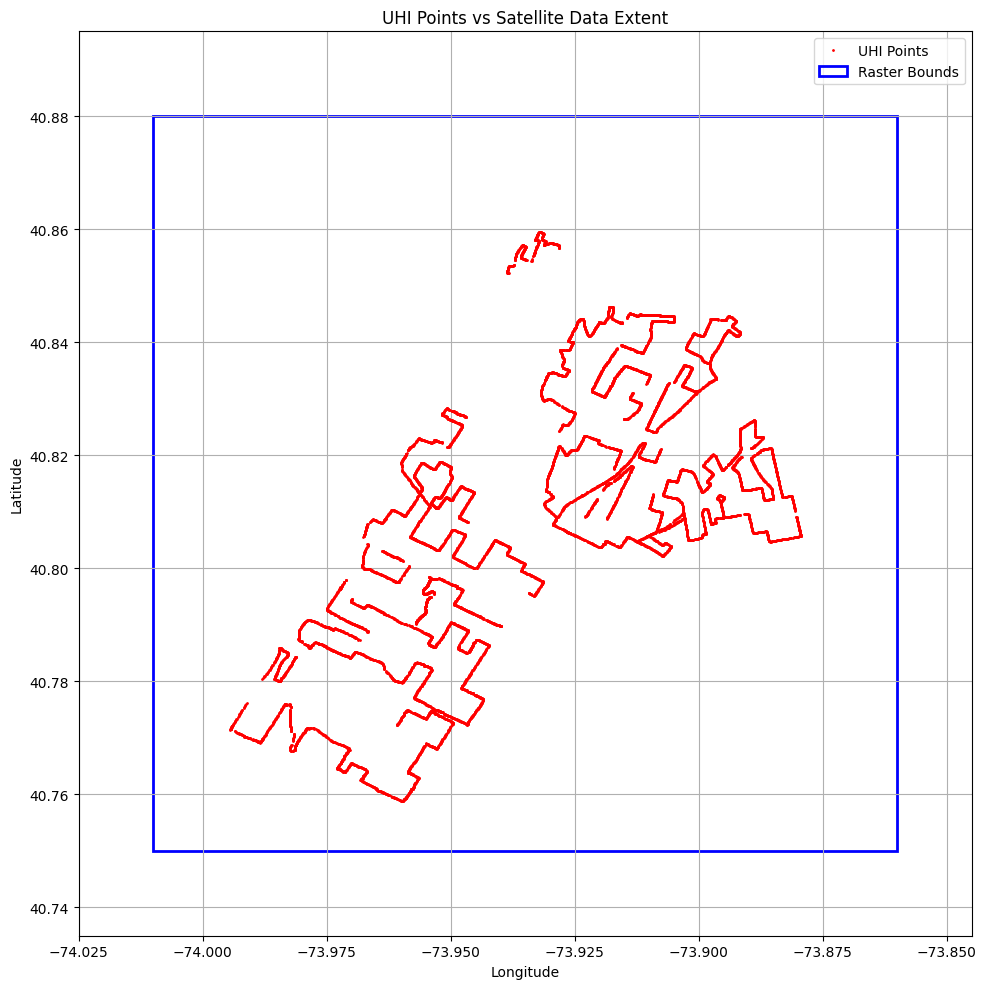

Loading satellite data and applying proper pooling...
Loaded raster with dimensions: 1448x1671, 14 bands
CRS: EPSG:4326
Transform: | 0.00, 0.00,-74.01|
| 0.00,-0.00, 40.88|
| 0.00, 0.00, 1.00|
Bounds: BoundingBox(left=-74.01, bottom=40.75, right=-73.86, top=40.88)
Sample data shape: (10, 10)
Sample data min/max/mean: 660.5/780.5/717.86
Sample UHI coordinates:
  Point 0: (40.81310667, -73.90916667)
  Point 1: (40.813045, -73.90918667)
  Point 2: (40.81297833, -73.909215)
  Point 3: (40.81290833, -73.90924167)
  Point 4: (40.812845, -73.90925667)
Checking if points are within raster bounds: BoundingBox(left=-74.01, bottom=40.75, right=-73.86, top=40.88)
Points in bounds: 100 out of 100 checked
Processing 14 bands: ['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B11', 'B12', 'ndwi', 'ndvi', 'ndbi']
Testing direct rasterio sample function...
Sample results shape: 5, First sample: [ 8.41500000e+02  1.05300000e+03  1.15500000e+03  1.20600000e+03
  1.48150000e+03  1.66050000e

Processing points: 100%|██████████| 11229/11229 [01:02<00:00, 178.84it/s]


Successfully processed 11229 out of 11229 points
Error types encountered:

Checking for NaN values in results:


In [ ]:
def map_satellite_data_with_pooling(tiff_path, csv_path, kernel_size=9):
    with rasterio.open(tiff_path) as src:
        transform = src.transform
        crs = src.crs
        width = src.width
        height = src.height
        band_count = src.count

    df = pd.read_csv(csv_path)
    latitudes = df['Latitude'].values
    longitudes = df['Longitude'].values

    base_band_names = ["B01", "B02", "B03", "B04", "B05", "B06", "B07", "B08", "B8A", "B11", "B12"]
    index_names = ["ndwi", "ndvi", "ndbi"]

    if band_count <= len(base_band_names):
        band_names = base_band_names[:band_count]
    else:
        band_names = base_band_names.copy()
        remaining_bands = band_count - len(band_names)
        band_names.extend(index_names[:min(remaining_bands, len(index_names))])

        remaining_bands = band_count - len(band_names)
        if remaining_bands > 0:
            band_names.extend([f"Band_{i+len(band_names)+1}" for i in range(remaining_bands)])

    raw_vals = [[] for _ in range(band_count)]
    pooled_vals = [[] for _ in range(band_count)]
    success_count = 0
    error_types = {}

    with rasterio.open(tiff_path) as src:
        for point_idx, (lat, lon) in enumerate(tqdm(zip(latitudes, longitudes), total=len(latitudes), desc="Processing points")):
            row, col = rasterio.transform.rowcol(src.transform, lon, lat)
            if 0 <= row < height and 0 <= col < width:
                point_data = src.read(window=((row, row+1), (col, col+1)))
                if point_data.size > 0 and not np.isnan(point_data).all():
                    success_count += 1
                    for band_idx in range(band_count):
                        raw_value = point_data[band_idx, 0, 0]
                        raw_vals[band_idx].append(raw_value)

                        window_size = kernel_size * 2
                        row_start = max(0, row - window_size//2)
                        row_end = min(height, row + window_size//2 + 1)
                        col_start = max(0, col - window_size//2)
                        col_end = min(width, col + window_size//2 + 1)

                        window_data = src.read(band_idx+1, window=((row_start, row_end), (col_start, col_end)))

                        if window_data.shape[0] >= kernel_size and window_data.shape[1] >= kernel_size:
                            pooled_window = mean_pool_same(window_data, kernel_size)
                            center_row = min(row - row_start, pooled_window.shape[0]-1)
                            center_col = min(col - col_start, pooled_window.shape[1]-1)
                            pooled_value = pooled_window[center_row, center_col]
                        else:
                            pooled_value = raw_value

                        pooled_vals[band_idx].append(pooled_value)
                else:
                    error_type = "No data at point"
                    error_types[error_type] = error_types.get(error_type, 0) + 1
                    for band_idx in range(band_count):
                        raw_vals[band_idx].append(np.nan)
                        pooled_vals[band_idx].append(np.nan)
            else:
                error_type = "Point out of bounds"
                error_types[error_type] = error_types.get(error_type, 0) + 1
                for band_idx in range(band_count):
                    raw_vals[band_idx].append(np.nan)
                    pooled_vals[band_idx].append(np.nan)

    result_df = pd.DataFrame()

    for i in range(band_count):
        result_df[band_names[i]] = raw_vals[i]

    for i in range(band_count):
        result_df[f"{band_names[i]} (pooled)"] = pooled_vals[i]

    for col in result_df.columns:
        na_count = result_df[col].isna().sum()
        if na_count > 0:
            col_mean = result_df[col].mean()
            if pd.isna(col_mean):
                result_df[col] = result_df[col].fillna(0)
            else:
                result_df[col] = result_df[col].fillna(col_mean)

    return result_df

def check_spatial_alignment(tiff_path, csv_path):
    points_df = pd.read_csv(csv_path)
    latitudes = points_df['Latitude'].values
    longitudes = points_df['Longitude'].values

    with rasterio.open(tiff_path) as src:
        bounds = src.bounds
        left, bottom, right, top = bounds

        points_in_bounds = 0
        for lat, lon in zip(latitudes, longitudes):
            if left <= lon <= right and bottom <= lat <= top:
                points_in_bounds += 1

    return points_in_bounds/len(latitudes)

alignment_percentage = check_spatial_alignment(SATELLITE_DATA, UHI_DATA_FILE)
if alignment_percentage > 0.5:
    feature_data = map_satellite_data_with_pooling(SATELLITE_DATA, UHI_DATA_FILE, kernel_size=9)
else:
    print("WARNING: Most UHI points are outside satellite data bounds.")
    print("Please check coordinate systems and data extents.")

In [ ]:
def map_satellite_data_with_pooling_and_uhi(tiff_path, csv_path, kernel_size=9):
    uhi_df = pd.read_csv(csv_path)
    uhi_df['original_index'] = uhi_df.index

    with rasterio.open(tiff_path) as src:
        transform = src.transform
        crs = src.crs
        width = src.width
        height = src.height
        band_count = src.count
        sample_data = src.read(1, window=((0, 10), (0, 10)))

    latitudes = uhi_df['Latitude'].values
    longitudes = uhi_df['Longitude'].values

    base_band_names = ["B01", "B02", "B03", "B04", "B05", "B06", "B07", "B08", "B8A", "B11", "B12"]
    index_names = ["ndwi", "ndvi", "ndbi"]

    if band_count <= len(base_band_names):
        band_names = base_band_names[:band_count]
    else:
        band_names = base_band_names.copy()
        remaining_bands = band_count - len(band_names)
        band_names.extend(index_names[:min(remaining_bands, len(index_names))])

        remaining_bands = band_count - len(band_names)
        if remaining_bands > 0:
            band_names.extend([f"Band_{i+len(band_names)+1}" for i in range(remaining_bands)])

    raw_vals = [[] for _ in range(band_count)]
    pooled_vals = [[] for _ in range(band_count)]
    original_indices = []
    success_count = 0
    error_types = {}

    with rasterio.open(tiff_path) as src:
        for point_idx, (lat, lon) in enumerate(tqdm(zip(latitudes, longitudes), total=len(latitudes), desc="Processing points")):
            original_indices.append(uhi_df.iloc[point_idx]['original_index'])
            row, col = rasterio.transform.rowcol(src.transform, lon, lat)

            if 0 <= row < height and 0 <= col < width:
                point_data = src.read(window=((row, row+1), (col, col+1)))

                if point_data.size > 0 and not np.isnan(point_data).all():
                    success_count += 1

                    for band_idx in range(band_count):
                        raw_value = point_data[band_idx, 0, 0]
                        raw_vals[band_idx].append(raw_value)

                        window_size = kernel_size * 2
                        row_start = max(0, row - window_size//2)
                        row_end = min(height, row + window_size//2 + 1)
                        col_start = max(0, col - window_size//2)
                        col_end = min(width, col + window_size//2 + 1)

                        window_data = src.read(band_idx+1, window=((row_start, row_end), (col_start, col_end)))

                        if window_data.shape[0] >= kernel_size and window_data.shape[1] >= kernel_size:
                            pooled_window = mean_pool_same(window_data, kernel_size)
                            center_row = min(row - row_start, pooled_window.shape[0]-1)
                            center_col = min(col - col_start, pooled_window.shape[1]-1)
                            pooled_value = pooled_window[center_row, center_col]
                        else:
                            pooled_value = raw_value

                        pooled_vals[band_idx].append(pooled_value)
                else:
                    error_type = "No data at point"
                    error_types[error_type] = error_types.get(error_type, 0) + 1
                    for band_idx in range(band_count):
                        raw_vals[band_idx].append(np.nan)
                        pooled_vals[band_idx].append(np.nan)
            else:
                error_type = "Point out of bounds"
                error_types[error_type] = error_types.get(error_type, 0) + 1
                for band_idx in range(band_count):
                    raw_vals[band_idx].append(np.nan)
                    pooled_vals[band_idx].append(np.nan)

    result_df = pd.DataFrame()
    result_df['original_index'] = original_indices

    for i in range(band_count):
        result_df[band_names[i]] = raw_vals[i]

    for i in range(band_count):
        result_df[f"{band_names[i]} (pooled)"] = pooled_vals[i]

    nan_summary = {}
    for col in result_df.columns:
        if col != 'original_index':
            na_count = result_df[col].isna().sum()
            nan_summary[col] = na_count

    for col in result_df.columns:
        if col != 'original_index':
            na_count = result_df[col].isna().sum()
            if na_count > 0:
                col_mean = result_df[col].mean()
                if pd.isna(col_mean):
                    result_df[col] = result_df[col].fillna(0)
                else:
                    result_df[col] = result_df[col].fillna(col_mean)

    combined_df = pd.merge(
        uhi_df,
        result_df,
        on='original_index',
        how='left'
    )

    for col in combined_df.columns:
        if col not in uhi_df.columns and col != 'original_index':
            na_count = combined_df[col].isna().sum()
            if na_count > 0:
                col_mean = combined_df[col].mean()
                if pd.isna(col_mean):
                    combined_df[col] = combined_df[col].fillna(0)
                else:
                    combined_df[col] = combined_df[col].fillna(col_mean)

    return combined_df

def check_spatial_alignment(tiff_path, csv_path):
    points_df = pd.read_csv(csv_path)
    latitudes = points_df['Latitude'].values
    longitudes = points_df['Longitude'].values
    original_indices = points_df.index.values

    with rasterio.open(tiff_path) as src:
        bounds = src.bounds
        left, bottom, right, top = bounds
        crs = src.crs
        transform = src.transform

        points_in_bounds = 0
        in_bound_indices = []

        for i, (lat, lon) in enumerate(zip(latitudes, longitudes)):
            if left <= lon <= right and bottom <= lat <= top:
                points_in_bounds += 1
                in_bound_indices.append(original_indices[i])

        sample_data = src.read(1, window=((0, min(100, src.height)), (0, min(100, src.width))))
        valid_data_percentage = np.sum(~np.isnan(sample_data)) / sample_data.size * 100

        import matplotlib.pyplot as plt
        from matplotlib.patches import Rectangle

        plt.figure(figsize=(10, 10))
        plt.plot(longitudes, latitudes, 'r.', markersize=2, label='UHI Points')

        rect = Rectangle((left, bottom), right-left, top-bottom,
                        fill=False, edgecolor='blue', linewidth=2, label='Raster Bounds')
        plt.gca().add_patch(rect)

        plt.xlabel('Longitude')
        plt.ylabel('Latitude')
        plt.title('UHI Points vs Satellite Data Extent')
        plt.legend()
        plt.grid(True)

        buffer = max((right-left), (top-bottom)) * 0.1
        plt.xlim(left - buffer, right + buffer)
        plt.ylim(bottom - buffer, top + buffer)

        plt.tight_layout()

        return plt.gcf(), points_in_bounds/len(latitudes), in_bound_indices

def run_alignment_check_and_pooling(tiff_path, csv_path, output_dir, kernel_size=9):
    os.makedirs(output_dir, exist_ok=True)

    fig, alignment_percentage, in_bound_indices = check_spatial_alignment(tiff_path, csv_path)

    if fig is not None:
        timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
        fig_path = os.path.join(output_dir, f"spatial_alignment_check_{timestamp}.png")
        fig.savefig(fig_path, dpi=300, bbox_inches='tight')
        plt.close(fig)

    if len(in_bound_indices) > 0:
        indices_df = pd.DataFrame({'index': in_bound_indices})
        timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
        indices_path = os.path.join(output_dir, f"in_bounds_indices_{timestamp}.csv")
        indices_df.to_csv(indices_path, index=False)

    if alignment_percentage > 0.5:
        feature_data = map_satellite_data_with_pooling_and_uhi(tiff_path, csv_path, kernel_size)

        timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
        output_filename = f"feature_data_with_uhi_{timestamp}.csv"
        output_path = os.path.join(output_dir, output_filename)
        feature_data.to_csv(output_path, index=False)

        return feature_data
    else:
        return None

DATA_PATH = "/content/drive/MyDrive/uhi/Code/Data"
SATELLITE_DATA = f"{DATA_PATH}/S2_median_fullBands_indeces.tiff"
UHI_DATA_FILE = f"{DATA_PATH}/Training_data_uhi_index_2025-02-18.csv"
OUTPUT_DIR = f"{DATA_PATH}/output"

feature_data = run_alignment_check_and_pooling(
    tiff_path=SATELLITE_DATA,
    csv_path=UHI_DATA_FILE,
    output_dir=OUTPUT_DIR,
    kernel_size=9
)

Checking spatial alignment between UHI points and satellite data...
Raster bounds: BoundingBox(left=-74.01, bottom=40.75, right=-73.86, top=40.88)
Raster CRS: EPSG:4326
Points within raster bounds: 11229 out of 11229
Percentage of points in bounds: 100.00%
Percentage of valid data in raster sample: 100.00%
Spatial alignment visualization saved to: /content/drive/MyDrive/uhi/Code/Data/output/spatial_alignment_check_20250504_214240.png
Indices of points within bounds saved to: /content/drive/MyDrive/uhi/Code/Data/output/in_bounds_indices_20250504_214240.csv

Alignment check passed. Proceeding with satellite data extraction...
Loading satellite data and applying proper pooling...
Loaded UHI data with 11229 points and 4 columns
Loaded raster with dimensions: 1448x1671, 14 bands
CRS: EPSG:4326
Transform: | 0.00, 0.00,-74.01|
| 0.00,-0.00, 40.88|
| 0.00, 0.00, 1.00|
Bounds: BoundingBox(left=-74.01, bottom=40.75, right=-73.86, top=40.88)
Sample data shape: (10, 10)
Sample data min/max/mean: 6

Processing points: 100%|██████████| 11229/11229 [01:04<00:00, 173.33it/s]


Successfully processed 11229 out of 11229 points
Error types encountered:

Checking for NaN values in results:

Combining satellite features with original UHI data...
Feature data with UHI values saved to: /content/drive/MyDrive/uhi/Code/Data/output/feature_data_with_uhi_20250504_214346.csv


## Data Loading and Feature Extraction

In [ ]:
def find_features_in_rings(uhi_points, features_gdf, max_search_distance=500,
                          feature_type="building", size_column=None):
    uhi_points_reset = uhi_points.reset_index()
    uhi_points_reset.rename(columns={'index': 'uhi_id'}, inplace=True)

    buffer_gdf = gpd.GeoDataFrame(
        {'uhi_id': uhi_points_reset.uhi_id},
        geometry=uhi_points_reset.geometry.buffer(max_search_distance),
        crs=uhi_points.crs
    )

    features_reset = features_gdf.reset_index(drop=True)

    if size_column and size_column in features_reset.columns:
        features_reset[f'safe_{size_column}'] = features_reset[size_column].clip(lower=1.0)

    joined = gpd.sjoin(
        features_reset,
        buffer_gdf,
        how='inner',
        predicate='intersects'
    )

    if len(joined) == 0:
        return pd.DataFrame()

    results = []

    for uhi_id, group in joined.groupby('uhi_id'):
        uhi_point = uhi_points_reset[uhi_points_reset.uhi_id == uhi_id].geometry.iloc[0]

        for idx, feature in group.iterrows():
            distance = uhi_point.distance(feature.geometry if feature_type == "tree" else feature.the_geom)

            if distance <= max_search_distance:
                result_dict = {
                    'uhi_id': uhi_id,
                    f'{feature_type}_id': idx,
                    'distance': distance,
                }

                if feature_type == "building":
                    result_dict.update({
                        'building_height': max(1.0, feature.building_height),
                        'building_area': feature.building_footprint_area
                    })
                elif feature_type == "tree":
                    result_dict['tree_dbh'] = feature.tree_dbh

                results.append(result_dict)

    if not results:
        return pd.DataFrame()

    result_df = pd.DataFrame(results)

    feature_count = result_df.groupby('uhi_id').size()
    uhi_with_features = len(feature_count)

    return result_df

def create_ring_buffer_features(uhi_points, nearby_features_df, feature_type="building",
                              buffer_distances=BUFFER_DISTANCES):
    uhi_df = uhi_points.reset_index()
    uhi_df.rename(columns={'index': 'uhi_id'}, inplace=True)

    bins = [0] + buffer_distances
    bin_labels = [f"{bins[i]}-{bins[i+1]}ft" for i in range(len(bins)-1)]

    nearby_features_df['distance_bin'] = pd.cut(
        nearby_features_df['distance'],
        bins=bins,
        labels=bin_labels,
        include_lowest=True
    )

    for bin_label in bin_labels:
        features_in_ring = nearby_features_df[nearby_features_df['distance_bin'] == bin_label]
        count_by_uhi = features_in_ring.groupby('uhi_id').size()
        count_by_uhi = count_by_uhi.reset_index(name=f'{feature_type}_count_{bin_label}')

        if feature_type == "building":
            features_in_ring['contribution'] = (
                features_in_ring['building_height'] *
                features_in_ring['building_area']
            ) / np.log(np.maximum(1.1, features_in_ring['distance']))

        elif feature_type == "tree":
            features_in_ring['contribution'] = (
                features_in_ring['tree_dbh'] ** 2
            ) / np.log(np.maximum(1.1, features_in_ring['distance']))

        impact_by_uhi = features_in_ring.groupby('uhi_id')['contribution'].sum()
        impact_by_uhi = impact_by_uhi.reset_index(name=f'{feature_type}_impact_{bin_label}')

        uhi_df = uhi_df.merge(count_by_uhi, on='uhi_id', how='left')
        uhi_df = uhi_df.merge(impact_by_uhi, on='uhi_id', how='left')

        uhi_df[f'{feature_type}_count_{bin_label}'] = uhi_df[f'{feature_type}_count_{bin_label}'].fillna(0)
        uhi_df[f'{feature_type}_impact_{bin_label}'] = uhi_df[f'{feature_type}_impact_{bin_label}'].fillna(0)

    idx = nearby_features_df.groupby('uhi_id')['distance'].idxmin()
    if len(idx) > 0:
        closest_features = nearby_features_df.loc[idx]

        if feature_type == "building":
            closest_data = closest_features[['uhi_id', 'distance', 'building_height', 'building_area']]
            closest_data.columns = [
                'uhi_id', 'closest_building_distance', 'closest_building_height', 'closest_building_area'
            ]
        elif feature_type == "tree":
            closest_data = closest_features[['uhi_id', 'distance', 'tree_dbh']]
            closest_data.columns = [
                'uhi_id', 'closest_tree_distance', 'closest_tree_dbh'
            ]

        uhi_df = uhi_df.merge(closest_data, on='uhi_id', how='left')

        if feature_type == "building":
            uhi_df['closest_building_distance'] = uhi_df['closest_building_distance'].fillna(float('inf'))
            uhi_df['closest_building_height'] = uhi_df['closest_building_height'].fillna(1.0)
            uhi_df['closest_building_area'] = uhi_df['closest_building_area'].fillna(0.0)
        elif feature_type == "tree":
            uhi_df['closest_tree_distance'] = uhi_df['closest_tree_distance'].fillna(float('inf'))
            uhi_df['closest_tree_dbh'] = uhi_df['closest_tree_dbh'].fillna(0.0)

    return uhi_df

def create_all_features_and_save(uhi_original, buildings, trees, output_dir=None):
    if output_dir:
        os.makedirs(output_dir, exist_ok=True)

    nearby_buildings = find_features_in_rings(
        uhi_original,
        buildings,
        max_search_distance=max(BUFFER_DISTANCES),
        feature_type="building",
        size_column="building_height"
    )

    nearby_trees = find_features_in_rings(
        uhi_original,
        trees,
        max_search_distance=max(BUFFER_DISTANCES),
        feature_type="tree",
        size_column="tree_dbh"
    )

    if len(nearby_buildings) > 0:
        building_features = create_ring_buffer_features(
            uhi_original,
            nearby_buildings,
            feature_type="building",
            buffer_distances=BUFFER_DISTANCES
        )
    else:
        building_features = None

    if len(nearby_trees) > 0:
        tree_features = create_ring_buffer_features(
            uhi_original,
            nearby_trees,
            feature_type="tree",
            buffer_distances=BUFFER_DISTANCES
        )
    else:
        tree_features = None

    combined = uhi_original.reset_index()
    combined.rename(columns={'index': 'uhi_id'}, inplace=True)

    if building_features is not None:
        building_cols = [col for col in building_features.columns
                        if 'building' in col and col != 'uhi_id' and col != 'geometry']
        combined = combined.merge(
            building_features[['uhi_id'] + building_cols],
            on='uhi_id',
            how='left'
        )

    if tree_features is not None:
        tree_cols = [col for col in tree_features.columns
                    if 'tree' in col and col != 'uhi_id' and col != 'geometry']
        combined = combined.merge(
            tree_features[['uhi_id'] + tree_cols],
            on='uhi_id',
            how='left'
        )

    for col in combined.columns:
        if 'count' in col or 'impact' in col:
            combined[col] = combined[col].fillna(0)
        elif 'distance' in col:
            combined[col] = combined[col].fillna(float('inf'))
        elif 'height' in col or 'area' in col or 'dbh' in col:
            combined[col] = combined[col].fillna(0)

    combined_gdf = gpd.GeoDataFrame(combined, geometry='geometry', crs=uhi_original.crs)

    if combined_gdf.crs != "EPSG:4326":
        combined_gdf = combined_gdf.to_crs("EPSG:4326")

    combined_gdf['longitude'] = combined_gdf.geometry.x
    combined_gdf['latitude'] = combined_gdf.geometry.y

    if output_dir:
        timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
        output_file = f"{output_dir}/combined_tree_building_uhi_{timestamp}.csv"
        combined_gdf.to_csv(output_file, index=False)

    return combined_gdf

In [ ]:
uhi_df = pd.read_csv(UHI_DATA_FILE)

uhi_gdf = gpd.GeoDataFrame(
    uhi_df,
    geometry=gpd.points_from_xy(uhi_df.Longitude, uhi_df.Latitude),
    crs="EPSG:4326"
)

uhi_gdf_local = uhi_gdf.to_crs("EPSG:2263")

from shapely import wkt
building_footprints_df = pd.read_csv(BUILDING_DATA)
building_footprints_df['the_geom'] = building_footprints_df['the_geom'].apply(wkt.loads)
building_footprints_gdf = gpd.GeoDataFrame(building_footprints_df, geometry='the_geom', crs="EPSG:4326")
building_footprints_gdf_local = building_footprints_gdf.to_crs("EPSG:2263")

building_footprints_gdf_local['building_footprint_area'] = building_footprints_gdf_local['the_geom'].area
building_footprints_gdf_local['centroid'] = building_footprints_gdf_local['the_geom'].centroid
building_footprints_gdf_local['building_height'] = building_footprints_gdf_local['HEIGHTROOF'] - building_footprints_gdf_local['GROUNDELEV']

trees_df = pd.read_csv(TREE_DATA)
trees_gdf = gpd.GeoDataFrame(
    trees_df,
    geometry=gpd.points_from_xy(trees_df.longitude, trees_df.latitude),
    crs="EPSG:4326"
)
trees_gdf_local = trees_gdf.to_crs("EPSG:2263")

output_dir = f"{DATA_PATH}/output"
os.makedirs(output_dir, exist_ok=True)

combined_features = create_all_features_and_save(
    uhi_original=uhi_gdf_local,
    buildings=building_footprints_gdf_local,
    trees=trees_gdf_local,
    output_dir=output_dir
)

Loaded UHI data with 11229 points
UHI data projected to local CRS
Loaded 149563 building footprints
Loaded 683788 trees
Extracting building and tree features...
Finding buildings within 500ft of UHI points...
  Found 765629 potential building-UHI pairs
  Found 765629 building-UHI relationships
  11066 UHI points (98.5%) have buildings within 500ft
Finding trees within 500ft of UHI points...
  Found 1087519 potential tree-UHI pairs
  Found 1087519 tree-UHI relationships
  10708 UHI points (95.4%) have trees within 500ft
Creating building features for ring buffers...

Building feature summary:
building_count_0-25ft: 3453 UHI points (30.8%)
building_impact_0-25ft: 3453 UHI points (30.8%)
building_count_25-50ft: 6543 UHI points (58.3%)
building_impact_25-50ft: 6543 UHI points (58.3%)
building_count_50-100ft: 9060 UHI points (80.7%)
building_impact_50-100ft: 9060 UHI points (80.7%)
building_count_100-200ft: 10334 UHI points (92.0%)
building_impact_100-200ft: 10334 UHI points (92.0%)
buildin

## Satellite Data processing

In [ ]:
latest_csv_file = find_latest_csv(DATA_PATH, prefix="raw_feature_data_")
if latest_csv_file:
    raw_feature_df = pd.read_csv(latest_csv_file)
    feature_data = raw_feature_df.copy()
else:
    feature_data = map_satellite_data(SATELLITE_DATA, UHI_DATA_FILE)
    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    output_filename = f"raw_feature_data_{timestamp}.csv"
    output_path = f"{DATA_PATH}/{output_filename}"
    feature_data.to_csv(output_path, index=False)

feature_data["ndwi"] = (feature_data["B03"] - feature_data["B08"])/(feature_data["B03"] + feature_data["B08"])
feature_data["ndbi"] = (feature_data["B11"] - feature_data["B08"])/(feature_data["B11"] + feature_data["B08"])
feature_data["ndvi"] = (feature_data["B08"] - feature_data["B04"])/(feature_data["B08"] + feature_data["B04"])
feature_data["ndwi (pooled)"] = (feature_data["B03 (pooled)"] - feature_data["B08 (pooled)"])/(feature_data["B03 (pooled)"] + feature_data["B08 (pooled)"])
feature_data["ndbi (pooled)"] = (feature_data["B11 (pooled)"] - feature_data["B08 (pooled)"])/(feature_data["B11 (pooled)"] + feature_data["B08 (pooled)"])
feature_data["ndvi (pooled)"] = (feature_data["B08 (pooled)"] - feature_data["B04 (pooled)"])/(feature_data["B08 (pooled)"] + feature_data["B04 (pooled)"])

feature_data['ndvi'] = feature_data['ndvi'].replace([np.inf, -np.inf], np.nan)
feature_data['ndwi'] = feature_data['ndwi'].replace([np.inf, -np.inf], np.nan)
feature_data['ndbi'] = feature_data['ndbi'].replace([np.inf, -np.inf], np.nan)
feature_data['ndvi (pooled)'] = feature_data['ndvi (pooled)'].replace([np.inf, -np.inf], np.nan)
feature_data['ndwi (pooled)'] = feature_data['ndwi (pooled)'].replace([np.inf, -np.inf], np.nan)
feature_data['ndbi (pooled)'] = feature_data['ndbi (pooled)'].replace([np.inf, -np.inf], np.nan)

timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
output_filename = f"feature_data_{timestamp}.csv"
output_path = f"{DATA_PATH}/{output_filename}"
feature_data.to_csv(output_path, index=False)

Loaded latest satellite features from: /content/drive/MyDrive/uhi/Code/Data/raw_feature_data_20250421_234019.csv
Updated feature data saved to: /content/drive/MyDrive/uhi/Code/Data/feature_data_20250504_183637.csv


## Combine all features & save

In [ ]:
ground_df = pd.read_csv(UHI_DATA_FILE)
uhi_data = combine_two_datasets(ground_df, feature_data)

columns_to_check = ['B01', 'B04', 'B06', 'B08', 'ndvi']
for col in columns_to_check:
    uhi_data[col] = uhi_data[col].apply(lambda x: tuple(x) if isinstance(x, np.ndarray) and x.ndim > 0 else x)

uhi_data = uhi_data.drop_duplicates(subset=columns_to_check, keep='first')

latest_building_tree_file = find_latest_csv(f"{DATA_PATH}/output", prefix="combined_tree_building_uhi_")

if latest_building_tree_file:
    building_tree_df = pd.read_csv(latest_building_tree_file)
    uhi_data = pd.merge(
        uhi_data,
        building_tree_df.drop(columns=['geometry', 'UHI Index']),
        on=['Latitude', 'Longitude'],
        how='left'
    )

timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
output_filename = f"complete_uhi_data_{timestamp}.csv"
output_path = f"{DATA_PATH}/{output_filename}"
uhi_data.to_csv(output_path, index=False)

Loaded building/tree features from: /content/drive/MyDrive/uhi/Code/Data/output/combined_tree_building_uhi_20250504_182951.csv
Combined satellite and building/tree features
Complete UHI data saved to: /content/drive/MyDrive/uhi/Code/Data/complete_uhi_data_20250504_183645.csv


## Combine all features & save

In [ ]:
def safe_join_csvs(features_file, tree_building_file, output_file=None):
    features_df = pd.read_csv(features_file)
    tree_df = pd.read_csv(tree_building_file)

    required_columns_features = ['original_index', 'Longitude', 'Latitude']
    required_columns_tree = ['uhi_id', 'Longitude', 'Latitude']

    for col in required_columns_features:
        if col not in features_df.columns:
            raise ValueError(f"Column '{col}' not found in features dataset")

    for col in required_columns_tree:
        if col not in tree_df.columns:
            raise ValueError(f"Column '{col}' not found in tree building dataset")

    features_df['original_index'] = features_df['original_index'].astype(int)
    tree_df['uhi_id'] = tree_df['uhi_id'].astype(int)

    joined_df = pd.merge(
        features_df,
        tree_df,
        left_on='original_index',
        right_on='uhi_id',
        how='inner',
        suffixes=('_features', '_tree')
    )

    joined_df['Longitude_features_rounded'] = joined_df['Longitude_features'].round(9)
    joined_df['Latitude_features_rounded'] = joined_df['Latitude_features'].round(9)
    joined_df['Longitude_tree_rounded'] = joined_df['Longitude_tree'].round(9)
    joined_df['Latitude_tree_rounded'] = joined_df['Latitude_tree'].round(9)

    if len(joined_df) == 0:
        return joined_df if output_file is None else None

    coord_mismatch = (
        (joined_df['Longitude_features_rounded'] != joined_df['Longitude_tree_rounded']) |
        (joined_df['Latitude_features_rounded'] != joined_df['Latitude_tree_rounded'])
    )

    mismatch_count = coord_mismatch.sum()
    if mismatch_count > 0:
        joined_df_safe = joined_df[~coord_mismatch].copy()
        joined_df = joined_df_safe

    joined_df = joined_df.drop(['Longitude_features_rounded', 'Latitude_features_rounded',
                               'Longitude_tree_rounded', 'Latitude_tree_rounded'], axis=1)

    if output_file:
        joined_df.to_csv(output_file, index=False)
        return None

    return joined_df

Looking for files in: /content/drive/MyDrive/uhi/Code/Data/output
Reading features file: /content/drive/MyDrive/uhi/Code/Data/output/feature_data_with_uhi_20250504_214346.csv
Reading tree building file: /content/drive/MyDrive/uhi/Code/Data/output/LATEST_combined_tree_building_uhi_features.csv
Features dataset shape: (11229, 33)
Tree building dataset shape: (11229, 33)
Performing join on original_index and uhi_id...
✓ All coordinates match between datasets!
Saving joined dataset to /content/drive/MyDrive/uhi/Code/Data/output/joined_features_tree_data.csv
Successfully saved 11229 rows to /content/drive/MyDrive/uhi/Code/Data/output/joined_features_tree_data.csv


# Part 1B. Features - Updated with Satellite Donuts

## Satellite Band Donut Features - Utility Functions (With Infinity Handling)



In [ ]:
import numpy as np
import pandas as pd
import rioxarray as rxr
import xarray as xr
from pyproj import Proj, Transformer
from tqdm import tqdm
import os
import datetime
import matplotlib.pyplot as plt
import rasterio
from rasterio.transform import Affine

RING_DISTANCES_METERS = [50, 100, 200, 500]

def extract_satellite_rings_safe(tiff_path, uhi_df, ring_distances=RING_DISTANCES_METERS,
                           bands_to_use=None, stats=['mean', 'std']):
    with rasterio.open(tiff_path) as src:
        width = src.width
        height = src.height
        band_count = src.count
        transform = src.transform
        crs = src.crs

        res_x = abs(transform.a)
        res_y = abs(transform.e)
        avg_resolution = (res_x + res_y) / 2

        bands_data = []
        for i in range(1, band_count + 1):
            bands_data.append(src.read(i))

    ring_distances_pixels = [int(round(dist / avg_resolution)) for dist in ring_distances]

    ring_ranges = [(0, ring_distances_pixels[0])]
    for i in range(1, len(ring_distances_pixels)):
        ring_ranges.append((ring_distances_pixels[i-1], ring_distances_pixels[i]))

    latitudes = uhi_df['Latitude'].values
    longitudes = uhi_df['Longitude'].values

    if bands_to_use is None:
        band_names = [f"B{i:02d}" for i in range(1, min(13, band_count+1))]
        if band_count >= 14:
            band_names.extend(["ndvi", "ndbi", "ndwi"])
    else:
        band_names = [band for band in bands_to_use if len(band) > 0]

    band_names = band_names[:band_count]

    results = {
        'Latitude': latitudes,
        'Longitude': longitudes
    }

    if crs.to_string() != 'EPSG:4326':
        coordinate_transformer = Transformer.from_crs("EPSG:4326", crs, always_xy=True)
    else:
        coordinate_transformer = None

    for i, (lat, lon) in enumerate(tqdm(zip(latitudes, longitudes),
                                       total=len(latitudes),
                                       desc="Processing UHI points")):
        if coordinate_transformer:
            x_proj, y_proj = coordinate_transformer.transform(lon, lat)
        else:
            x_proj, y_proj = lon, lat

        row, col = rasterio.transform.rowcol(transform, x_proj, y_proj)

        if (row < 0 or col < 0 or row >= height or col >= width or
            np.isinf(row) or np.isinf(col) or np.isnan(row) or np.isnan(col)):
            continue

        for ring_idx, (inner_radius, outer_radius) in enumerate(ring_ranges):
            ring_name = f"ring{ring_idx+1}"

            max_radius = min(outer_radius + 5, 1000)
            min_row = max(0, row - max_radius)
            max_row = min(height - 1, row + max_radius)
            min_col = max(0, col - max_radius)
            max_col = min(width - 1, col + max_radius)

            if min_row >= max_row or min_col >= max_col:
                continue

            y_coords, x_coords = np.mgrid[min_row:max_row+1, min_col:max_col+1]

            distances_squared = (y_coords - row)**2 + (x_coords - col)**2

            ring_mask = (distances_squared >= inner_radius**2) & (distances_squared < outer_radius**2)

            if not np.any(ring_mask):
                continue

            for band_idx, band_name in enumerate(band_names):
                if band_idx >= len(bands_data):
                    continue

                band_window = bands_data[band_idx][min_row:max_row+1, min_col:max_col+1]

                masked_values = band_window[ring_mask]

                if len(masked_values) == 0 or np.all(np.isnan(masked_values)):
                    continue

                for stat in stats:
                    if stat == 'mean':
                        value = np.nanmean(masked_values)
                    elif stat == 'std':
                        value = np.nanstd(masked_values)
                    elif stat == 'min':
                        value = np.nanmin(masked_values)
                    elif stat == 'max':
                        value = np.nanmax(masked_values)
                    elif stat == 'median':
                        value = np.nanmedian(masked_values)
                    else:
                        continue

                    if np.isnan(value) or np.isinf(value):
                        continue

                    feature_name = f"{band_name}_{ring_name}_{stat}"
                    if feature_name not in results:
                        results[feature_name] = np.full(len(latitudes), np.nan)
                    results[feature_name][i] = value

    result_df = pd.DataFrame(results)

    for col in result_df.columns:
        if col not in ['Latitude', 'Longitude'] and result_df[col].isna().any():
            col_mean = result_df[col].mean()
            if np.isnan(col_mean):
                result_df[col] = result_df[col].fillna(0)
            else:
                result_df[col] = result_df[col].fillna(col_mean)

    return result_df

## Satellite Band Donut Features - Main Implementation

Examining GeoTIFF file...
Raster shape: 1448x1671
Raster transform: | 0.00, 0.00,-74.01|
| 0.00,-0.00, 40.88|
| 0.00, 0.00, 1.00|
Raster CRS: EPSG:4326
Raster count: 14
Driver: GTiff
Bounds: BoundingBox(left=-74.01, bottom=40.75, right=-73.86, top=40.88)
Sample data: min=660.5, max=780.5, mean=717.86
Starting satellite ring feature extraction...
UHI data shape: (11229, 4)
Sample UHI point: 40.81310667, -73.90916667
Using a sample of 5000 UHI points for feature extraction
Extracting satellite band values in concentric rings (safe version)...
Loaded raster with dimensions: 1448x1671, 14 bands
CRS: EPSG:4326
Transform: | 0.00, 0.00,-74.01|
| 0.00,-0.00, 40.88|
| 0.00, 0.00, 1.00|
Satellite data resolution: 8.976660682226553e-05m x 8.977900552486364e-05m (average: 8.977280617356458e-05m)
Ring distances in pixels: [556962, 1113923, 2227846, 5569615]
Processing bands: ['B02', 'B03', 'B04', 'B08', 'B11', 'B12', 'ndvi', 'ndbi', 'ndwi']


Processing UHI points: 100%|██████████| 5000/5000 [39:11<00:00,  2.13it/s]


Generated 18 satellite ring features
Satellite ring features saved to: /content/drive/MyDrive/uhi/Code/Data/output/satellite_ring_features_20250504_202847.csv
Successfully generated 18 satellite ring features
Ring visualization saved to: /content/drive/MyDrive/uhi/Code/Data/output/satellite_rings_example_20250504_202847.png


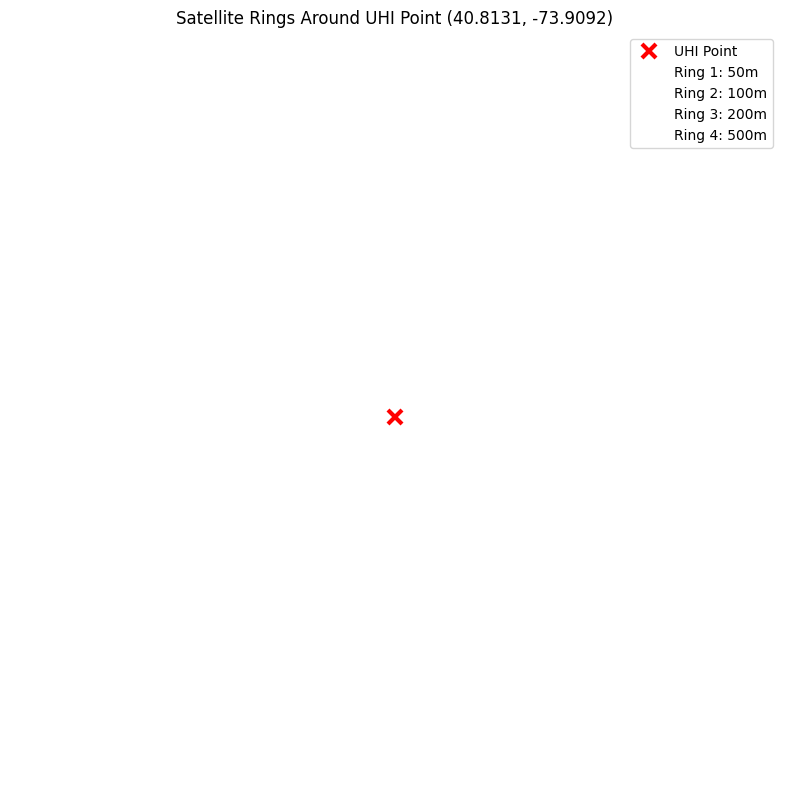

Combined features saved to: /content/drive/MyDrive/uhi/Code/Data/output/combined_with_satellite_rings_20250504_202847.csv
Total features: 46
Feature correlations saved to: /content/drive/MyDrive/uhi/Code/Data/output/feature_correlations_20250504_202847.csv

Feature counts by type:
  - Satellite Pixel: 28
  - Satellite Ring: 18

Top 20 features by type:
  - Satellite Ring: 5
  - Building: 0
  - Tree: 0
  - Satellite Pixel: 15


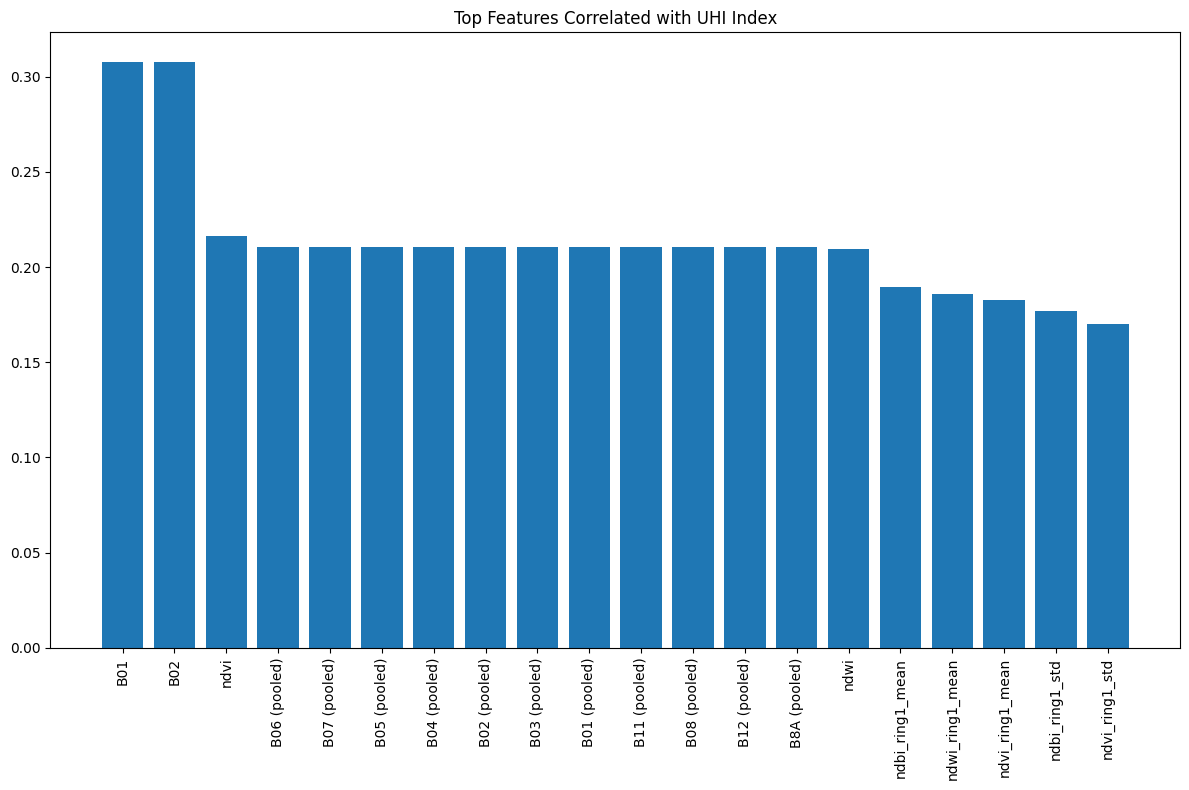

In [ ]:
SATELLITE_DATA = f"{DATA_PATH}/S2_median_fullBands_indeces.tiff"
OUTPUT_DIR = f"{DATA_PATH}/output"

os.makedirs(OUTPUT_DIR, exist_ok=True)

IMPORTANT_BANDS = ["B02", "B03", "B04", "B08", "B11", "B12", "ndvi", "ndbi", "ndwi"]
STATISTICS = ["mean", "std"]

with rasterio.open(SATELLITE_DATA) as src:
    sample = src.read(1, window=rasterio.windows.Window(0, 0, 10, 10))

MAX_POINTS = 5000
if len(ground_df) > MAX_POINTS:
    uhi_sample = ground_df.sample(MAX_POINTS, random_state=42)
else:
    uhi_sample = ground_df

satellite_ring_features = extract_satellite_rings_safe(
    tiff_path=SATELLITE_DATA,
    uhi_df=uhi_sample,
    ring_distances=RING_DISTANCES_METERS,
    bands_to_use=IMPORTANT_BANDS,
    stats=STATISTICS
)

timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
output_filename = f"satellite_ring_features_{timestamp}.csv"
output_path = f"{OUTPUT_DIR}/{output_filename}"
satellite_ring_features.to_csv(output_path, index=False)

if len(satellite_ring_features.columns) > 2:
    sample_lat = ground_df['Latitude'].values[0]
    sample_lon = ground_df['Longitude'].values[0]

    ring_plot = visualize_ring_example_rasterio(
        tiff_path=SATELLITE_DATA,
        lat=sample_lat,
        lon=sample_lon,
        ring_distances=RING_DISTANCES_METERS
    )

    ring_plot_path = f"{OUTPUT_DIR}/satellite_rings_example_{timestamp}.png"
    ring_plot.savefig(ring_plot_path, dpi=300, bbox_inches='tight')
    ring_plot.show()

    satellite_ring_features_nodupe = satellite_ring_features.drop(columns=['Latitude', 'Longitude'])

    if len(uhi_sample) == len(feature_data):
        combined_data = pd.concat([feature_data, satellite_ring_features_nodupe], axis=1)
    else:
        lat_lon_to_features = {}
        for i, row in satellite_ring_features.iterrows():
            lat_lon_to_features[(row['Latitude'], row['Longitude'])] = row

        combined_data = feature_data.copy()
        for feature_col in satellite_ring_features_nodupe.columns:
            combined_data[feature_col] = np.nan

        for i, row in ground_df.iterrows():
            key = (row['Latitude'], row['Longitude'])
            if key in lat_lon_to_features:
                for feature_col in satellite_ring_features_nodupe.columns:
                    combined_data.loc[i, feature_col] = lat_lon_to_features[key][feature_col]

    for col in satellite_ring_features_nodupe.columns:
        if combined_data[col].isna().any():
            col_mean = combined_data[col].mean()
            if np.isnan(col_mean):
                combined_data[col] = combined_data[col].fillna(0)
            else:
                combined_data[col] = combined_data[col].fillna(col_mean)

    output_filename = f"combined_with_satellite_rings_{timestamp}.csv"
    output_path = f"{OUTPUT_DIR}/{output_filename}"
    combined_data.to_csv(output_path, index=False)

    satellite_ring_cols = satellite_ring_features_nodupe.columns.tolist()
    all_feature_names = names + satellite_ring_cols

    uhi_data = pd.read_csv(UHI_DATA_FILE)
    corr_data = pd.concat([uhi_data['UHI Index'], combined_data], axis=1)
    correlations = corr_data.corr()['UHI Index'].drop('UHI Index')
    abs_corr = correlations.abs().sort_values(ascending=False)
    top_features = abs_corr.head(20)

    plt.figure(figsize=(12, 8))
    plt.bar(range(len(top_features)), top_features.values)
    plt.xticks(range(len(top_features)), top_features.index, rotation=90)
    plt.title('Top Features Correlated with UHI Index')
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/feature_importance_{timestamp}.png")

    feature_types = []
    for feature in correlations.index:
        if 'ring' in feature:
            feature_types.append('Satellite Ring')
        elif 'building' in feature:
            feature_types.append('Building')
        elif 'tree' in feature:
            feature_types.append('Tree')
        else:
            feature_types.append('Satellite Pixel')

    corr_df = pd.DataFrame({
        'Feature': correlations.index,
        'Correlation': correlations.values,
        'Abs_Correlation': abs_corr.values,
        'Feature_Type': feature_types
    })
    corr_df = corr_df.sort_values('Abs_Correlation', ascending=False)
    corr_df.to_csv(f"{OUTPUT_DIR}/feature_correlations_{timestamp}.csv", index=False)

    type_counts = {}
    for feature_type in feature_types:
        if feature_type not in type_counts:
            type_counts[feature_type] = 0
        type_counts[feature_type] += 1
else:
    print("No satellite ring features were generated beyond Latitude/Longitude.")
    print("Check if the satellite data covers the UHI points or try different parameters.")

## Combine with Original Features

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime
from scipy.spatial import cKDTree
import os

OUTPUT_DIR = '/content/drive/MyDrive/uhi/Code/Data/output'
UHI_FILE = f"{OUTPUT_DIR}/joined_features_tree_data_20250504_214346.csv"
SATELLITE_RINGS_FILE = f"{OUTPUT_DIR}/satellite_ring_features_20250504_202847.csv"

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

def spatial_join_with_kdtree(uhi_df, satellite_df, max_distance=0.0001):
    lat_cols = [col for col in uhi_df.columns if 'latitude' in col.lower()]
    lon_cols = [col for col in uhi_df.columns if 'longitude' in col.lower()]

    if len(lat_cols) == 0 or len(lon_cols) == 0:
        raise ValueError("Latitude or Longitude columns not found in UHI data")

    uhi_lat_col = next((col for col in ['Latitude_features', 'Latitude', 'latitude'] if col in lat_cols), lat_cols[0])
    uhi_lon_col = next((col for col in ['Longitude_features', 'Longitude', 'longitude'] if col in lon_cols), lon_cols[0])

    if 'Latitude' not in satellite_df.columns or 'Longitude' not in satellite_df.columns:
        raise ValueError("Latitude or Longitude columns not found in satellite data")

    uhi_coords = np.array([uhi_df[uhi_lat_col], uhi_df[uhi_lon_col]]).T
    satellite_coords = np.array([satellite_df['Latitude'], satellite_df['Longitude']]).T

    uhi_lat_range = (uhi_df[uhi_lat_col].min(), uhi_df[uhi_lat_col].max())
    uhi_lon_range = (uhi_df[uhi_lon_col].min(), uhi_df[uhi_lon_col].max())
    sat_lat_range = (satellite_df['Latitude'].min(), satellite_df['Latitude'].max())
    sat_lon_range = (satellite_df['Longitude'].min(), satellite_df['Longitude'].max())

    tree = cKDTree(satellite_coords)

    distances, indices = tree.query(uhi_coords, k=1, distance_upper_bound=max_distance)

    valid_matches = distances != np.inf
    match_count = np.sum(valid_matches)

    if match_count == 0:
        return None

    result_df = uhi_df.copy()

    indices_with_nan = indices.copy().astype(float)
    indices_with_nan[~valid_matches] = np.nan

    result_df['spatial_join_distance'] = distances
    result_df['satellite_data_matched'] = valid_matches

    for col in satellite_df.columns:
        if col in ['Latitude', 'Longitude']:
            continue

        new_col = f"{col}_ring"
        result_df[new_col] = np.nan

        for i in range(len(result_df)):
            if valid_matches[i]:
                idx = indices[i]
                result_df.loc[i, new_col] = satellite_df.iloc[idx][col]

    return result_df

uhi_df = pd.read_csv(UHI_FILE)
satellite_df = pd.read_csv(SATELLITE_RINGS_FILE)

joined_df = spatial_join_with_kdtree(uhi_df, satellite_df, max_distance=0.0002)

if joined_df is not None:
    satellite_ring_cols = [col for col in joined_df.columns if col.endswith('_ring')]
    null_counts = joined_df[satellite_ring_cols].isnull().sum()

    output_file = f"{OUTPUT_DIR}/uhi_with_satellite_rings_{timestamp}.csv"
    joined_df.to_csv(output_file, index=False)

    match_rate = joined_df['satellite_data_matched'].mean() * 100

    if match_rate < 90:
        joined_df_larger = spatial_join_with_kdtree(uhi_df, satellite_df, max_distance=0.0003)

        if joined_df_larger is not None:
            new_match_rate = joined_df_larger['satellite_data_matched'].mean() * 100

            if new_match_rate > match_rate + 5:
                output_file_larger = f"{OUTPUT_DIR}/uhi_with_satellite_rings_larger_threshold_{timestamp}.csv"
                joined_df_larger.to_csv(output_file_larger, index=False)

Loading UHI data from: /content/drive/MyDrive/uhi/Code/Data/output/joined_features_tree_data_20250504_214346.csv
Loaded UHI data with shape: (11229, 66)
Loading satellite ring data from: /content/drive/MyDrive/uhi/Code/Data/output/satellite_ring_features_20250504_202847.csv
Loaded satellite ring data with shape: (5000, 20)
Performing spatial join with KDTree...
Using UHI coordinates: Latitude_features, Longitude_features
Using satellite coordinates: Latitude, Longitude
UHI latitude range: (40.75879167, 40.85949667)
UHI longitude range: (-73.99445667, -73.87945833)
Satellite latitude range: (40.75880833, 40.85949667)
Satellite longitude range: (-73.994415, -73.87946)
Found 10357 matches out of 11229 UHI points (92.23%)

Null value counts in satellite ring columns:
B02_ring1_mean_ring     872
B02_ring1_std_ring      872
B03_ring1_mean_ring     872
B03_ring1_std_ring      872
B04_ring1_mean_ring     872
B04_ring1_std_ring      872
B08_ring1_mean_ring     872
B08_ring1_std_ring      872
B1

Loading merged dataset: /content/drive/MyDrive/uhi/Code/Data/output/complete_uhi_satellite_data_20250504_225131.csv
Loaded dataset with shape: (11229, 86)
✓ Found original_index column
Found coordinate columns: ['Longitude_features', 'Latitude_features', 'Longitude_tree', 'Latitude_tree', 'longitude', 'latitude', 'Latitude', 'Longitude']
Handling duplicate coordinate columns...
Dropping 'Latitude_features' in favor of 'Latitude'
Dropping 'Latitude_tree' in favor of 'Latitude'
Dropping 'latitude' in favor of 'Latitude'
Dropping 'Longitude_features' in favor of 'Longitude'
Dropping 'Longitude_tree' in favor of 'Longitude'
Dropping 'longitude' in favor of 'Longitude'
Coordinate columns after cleanup: ['Latitude', 'Longitude']
Found UHI Index column variants: ['UHI Index_features']
Using 'UHI Index_features' as the UHI Index column
Found 76 numeric columns for correlation analysis
UHI Index column 'UHI Index_features' found with dtype: float64
Plot saved to: /content/drive/MyDrive/uhi/Code

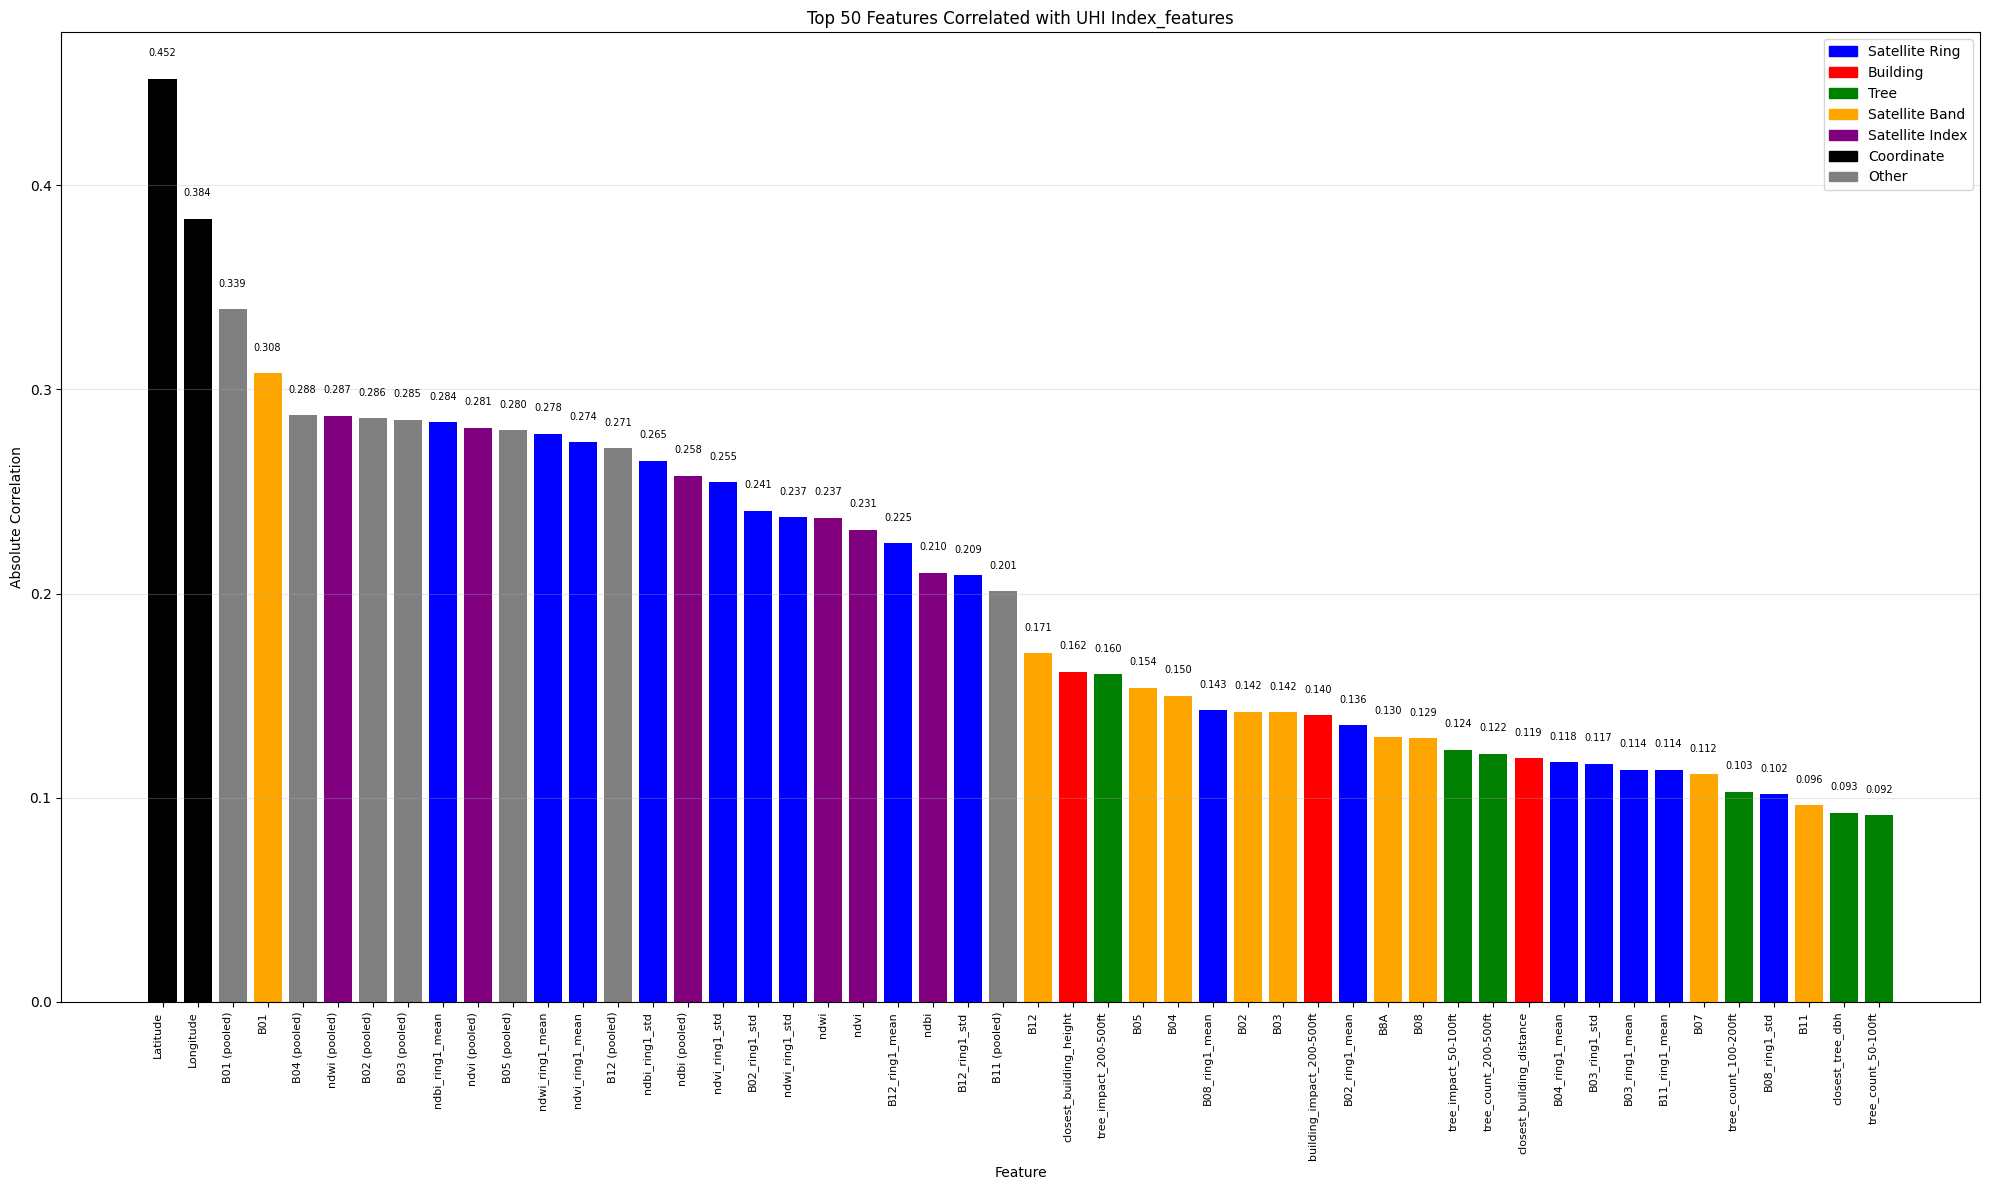


Feature type distribution in top 50:
  - Satellite Ring: 16
  - Satellite Band: 10
  - Other: 7
  - Tree: 6
  - Satellite Index: 6
  - Building: 3
  - Coordinate: 2
Top 50 feature correlations saved to: /content/drive/MyDrive/uhi/Code/Data/output/top50_feature_correlations_20250504_232651.csv

Top features by category:

Satellite Ring:
  - ndbi_ring1_mean: 0.2840
  - ndwi_ring1_mean: 0.2784
  - ndvi_ring1_mean: 0.2741
  - ndbi_ring1_std: 0.2651
  - ndvi_ring1_std: 0.2547

Building:
  - closest_building_height: 0.1618
  - building_impact_200-500ft: 0.1404
  - closest_building_distance: 0.1193

Tree:
  - tree_impact_200-500ft: 0.1605
  - tree_impact_50-100ft: 0.1236
  - tree_count_200-500ft: 0.1217
  - tree_count_100-200ft: 0.1031
  - closest_tree_dbh: 0.0926

Satellite Band:
  - B01: 0.3079
  - B12: 0.1709
  - B05: 0.1539
  - B04: 0.1500
  - B02: 0.1421

Satellite Index:
  - ndwi (pooled): 0.2870
  - ndvi (pooled): 0.2812
  - ndbi (pooled): 0.2577
  - ndwi: 0.2373
  - ndvi: 0.2314

Coo

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
import datetime

OUTPUT_DIR = '/content/drive/MyDrive/uhi/Code/Data/output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

def find_latest_file(directory, pattern):
    files = glob.glob(os.path.join(directory, pattern))
    if not files:
        return None
    return max(files, key=os.path.getmtime)

latest_merged_file = find_latest_file(OUTPUT_DIR, 'complete_uhi_satellite_data_*.csv')

if not latest_merged_file:
    latest_merged_file = find_latest_file(OUTPUT_DIR, '*uhi*satellite*.csv')

if latest_merged_file:
    merged_df = pd.read_csv(latest_merged_file)
else:
    raise FileNotFoundError("Merged dataset not found")

coord_columns = [col for col in merged_df.columns if 'latitude' in col.lower() or 'longitude' in col.lower()]

if len([col for col in coord_columns if 'latitude' in col.lower()]) > 1 or len([col for col in coord_columns if 'longitude' in col.lower()]) > 1:
    lat_priority = ['Latitude', 'Latitude_features', 'latitude']
    lon_priority = ['Longitude', 'Longitude_features', 'longitude']

    lat_to_keep = None
    for lat in lat_priority:
        if lat in merged_df.columns:
            lat_to_keep = lat
            break

    lon_to_keep = None
    for lon in lon_priority:
        if lon in merged_df.columns:
            lon_to_keep = lon
            break

    if lat_to_keep:
        for col in merged_df.columns:
            if 'latitude' in col.lower() and col != lat_to_keep:
                merged_df = merged_df.drop(columns=[col])

    if lon_to_keep:
        for col in merged_df.columns:
            if 'longitude' in col.lower() and col != lon_to_keep:
                merged_df = merged_df.drop(columns=[col])

    coord_columns = [col for col in merged_df.columns if 'latitude' in col.lower() or 'longitude' in col.lower()]

uhi_column_variants = [col for col in merged_df.columns if 'uhi' in col.lower() and 'index' in col.lower()]

if len(uhi_column_variants) > 0:
    uhi_priority = ['UHI Index', 'UHI Index_features', 'UHI_Index']
    uhi_col = None

    for col in uhi_priority:
        if col in uhi_column_variants:
            uhi_col = col
            break

    if not uhi_col and uhi_column_variants:
        uhi_col = uhi_column_variants[0]
else:
    uhi_col = None

numeric_cols = merged_df.select_dtypes(include=[np.number]).columns.tolist()

if uhi_col and uhi_col in merged_df.columns:
    if uhi_col not in numeric_cols:
        merged_df[uhi_col] = pd.to_numeric(merged_df[uhi_col])
        numeric_cols.append(uhi_col)
else:
    uhi_col = None

if uhi_col and uhi_col in numeric_cols:
    numeric_df = merged_df[numeric_cols]

    all_correlations = numeric_df.corr()[uhi_col].drop(uhi_col)

    abs_corr = all_correlations.abs().sort_values(ascending=False)
    top_features = abs_corr.head(50)

    def categorize_feature(feature_name):
        feature_name_lower = feature_name.lower()
        if '_ring' in feature_name_lower:
            return 'Satellite Ring'
        elif 'building' in feature_name_lower:
            return 'Building'
        elif 'tree' in feature_name_lower:
            return 'Tree'
        elif feature_name.startswith('B') and len(feature_name) <= 4:
            return 'Satellite Band'
        elif any(idx in feature_name_lower for idx in ['ndvi', 'ndbi', 'ndwi']):
            return 'Satellite Index'
        elif any(coord in feature_name_lower for coord in ['latitude', 'longitude']):
            return 'Coordinate'
        else:
            return 'Other'

    feature_categories = pd.Series(
        [categorize_feature(f) for f in top_features.index],
        index=top_features.index
    )

    category_colors = {
        'Satellite Ring': 'blue',
        'Building': 'red',
        'Tree': 'green',
        'Satellite Band': 'orange',
        'Satellite Index': 'purple',
        'Coordinate': 'black',
        'Other': 'gray'
    }

    colors = [category_colors[cat] for cat in feature_categories]

    plt.figure(figsize=(20, 12))
    bars = plt.bar(top_features.index, top_features.values, color=colors)

    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                 f'{height:.3f}', ha='center', va='bottom', rotation=0, fontsize=7)

    legend_handles = [plt.Rectangle((0,0),1,1, color=color) for color in category_colors.values()]
    legend_labels = list(category_colors.keys())

    plt.legend(legend_handles, legend_labels, loc='upper right')
    plt.title(f'Top 50 Features Correlated with {uhi_col}')
    plt.xlabel('Feature')
    plt.ylabel('Absolute Correlation')
    plt.xticks(rotation=90, ha='right', fontsize=8)
    plt.subplots_adjust(bottom=0.3)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()

    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    plot_filename = f"{OUTPUT_DIR}/top50_feature_importance_{timestamp}.png"
    plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
    plt.show()

    category_counts = feature_categories.value_counts()

    top50_corr_df = pd.DataFrame({
        'Feature': top_features.index,
        'Correlation': all_correlations.loc[top_features.index].values,
        'Abs_Correlation': top_features.values,
        'Category': [categorize_feature(f) for f in top_features.index]
    })

    output_path = f"{OUTPUT_DIR}/top50_feature_correlations_{timestamp}.csv"
    top50_corr_df.to_csv(output_path, index=False)

# Part 2. Basic Models

## Neural Network Data Preparation

In [ ]:
satellite_cols = names
building_cols = [col for col in uhi_data.columns if 'building' in col.lower()]
tree_cols = [col for col in uhi_data.columns if 'tree' in col.lower()]

all_feature_cols = satellite_cols + building_cols + tree_cols
all_feature_cols = [col for col in all_feature_cols if col in uhi_data.columns]

uhi_data_cleaned = uhi_data.copy()
for col in all_feature_cols:
    if col in uhi_data_cleaned.columns:
        null_count = uhi_data_cleaned[col].isnull().sum()
        if null_count > 0:
            if 'distance' in col:
                uhi_data_cleaned[col] = uhi_data_cleaned[col].fillna(float('inf'))
            else:
                uhi_data_cleaned[col] = uhi_data_cleaned[col].fillna(0)

model1_data = uhi_data_cleaned[satellite_cols + ['UHI Index']]
model1_data_std = model1_data.apply(lambda x: (x - x.mean()) / x.std(), axis=0)
model1_data_std = model1_data_std.apply(lambda x: pd.to_numeric(x, errors='coerce'), axis=0)

selected_satellite_cols = ['B01', 'B05', 'B08', 'B11', 'ndwi', 'ndvi', 'ndbi']
model2_data = uhi_data_cleaned[selected_satellite_cols + ['UHI Index']]
model2_data_std = model2_data.apply(lambda x: (x - x.mean()) / x.std(), axis=0)
model2_data_std = model2_data_std.apply(lambda x: pd.to_numeric(x, errors='coerce'), axis=0)

model3_data = uhi_data_cleaned[all_feature_cols + ['UHI Index']]
model3_data_std = model3_data.apply(lambda x: (x - x.mean()) / x.std(), axis=0)
model3_data_std = model3_data_std.apply(lambda x: pd.to_numeric(x, errors='coerce'), axis=0)

model1_data_std = model1_data_std.fillna(0)
model2_data_std = model2_data_std.fillna(0)
model3_data_std = model3_data_std.fillna(0)

Satellite features: 28
Building features: 13
Tree features: 15


KeyError: "['UHI Index'] not in index"

##  Model 1 - Basic Neural Network with All Satellite Features

Model 1 - Training data shape: X: (5848, 28), y: (5848,)
Epoch 1/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 1.0507 - val_loss: 0.9039
Epoch 2/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.9309 - val_loss: 0.8911
Epoch 3/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.8641 - val_loss: 0.8822
Epoch 4/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.8683 - val_loss: 0.8725
Epoch 5/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8397 - val_loss: 0.8672
Epoch 6/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8570 - val_loss: 0.8718
Epoch 7/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8743 - val_loss: 0.8697
Epoch 8/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8593 - val_loss: 0.8654
Epoch 9/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.8401 - val_loss: 0.8659
Epoch 10/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.8517 - val_loss: 0.8623
Epoch 11/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.8598 - val_loss: 0.

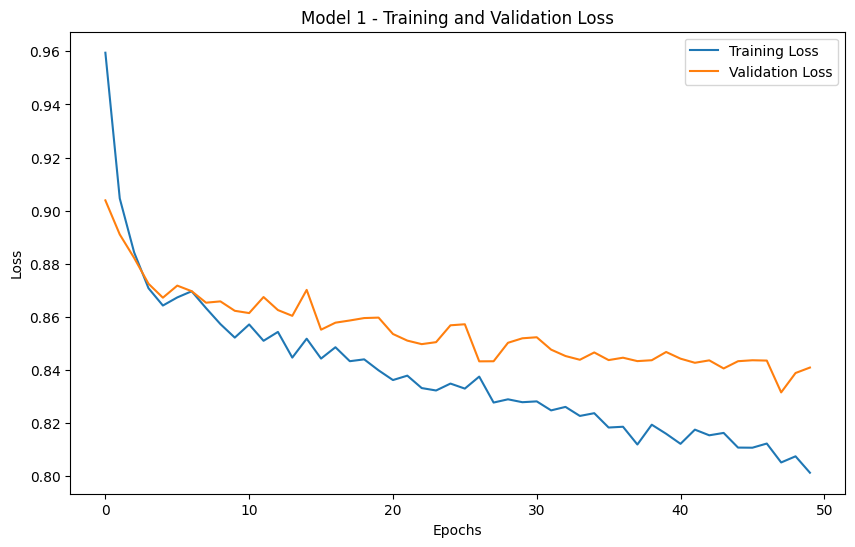

In [ ]:
X1 = model1_data_std.drop(columns=['UHI Index']).values
y1 = model1_data_std['UHI Index'].values

X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.3, random_state=123)

model1 = Sequential([
    Dense(32, activation='relu', input_shape=(X1_train.shape[1],)),
    Dropout(0.1),
    Dense(32, activation='relu'),
    Dropout(0.1),
    Dense(1, activation='linear'),
])
model1.compile(optimizer=Adam(learning_rate=0.001), loss="MSE")

history1 = model1.fit(X1_train, y1_train, epochs=50, validation_split=0.2, verbose=1)

y1_pred = model1.predict(X1_test)
r2_model1 = r2_score(y1_test, y1_pred)
mse_model1 = mean_squared_error(y1_test, y1_pred)

plt.figure(figsize=(10, 6))
plt.plot(history1.history['loss'], label='Training Loss')
plt.plot(history1.history['val_loss'], label='Validation Loss')
plt.title('Model 1 - Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.savefig(f"{DATA_PATH}/model1_history_{timestamp}.png")
plt.show()

## Model 2 - Deep Network with Selected Satellite Features

Model 2 - Training data shape: X: (5848, 7), y: (5848,)
Epoch 1/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 2.1295 - val_loss: 1.3309
Epoch 2/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1.2411 - val_loss: 1.0559
Epoch 3/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 1.0427 - val_loss: 0.9711
Epoch 4/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.9839 - val_loss: 0.9793
Epoch 5/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.9554 - val_loss: 0.9641
Epoch 6/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.9272 - val_loss: 0.9522
Epoch 7/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.9241 - val_loss: 0.9189
Epoch 8/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.9618 - val_loss: 0.9371
Epoch 9/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.9251 - val_loss: 0.9289
Epoch 10/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.9335 - val_loss: 0.9346
Epoch 11/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.9516 - val_loss: 0.9

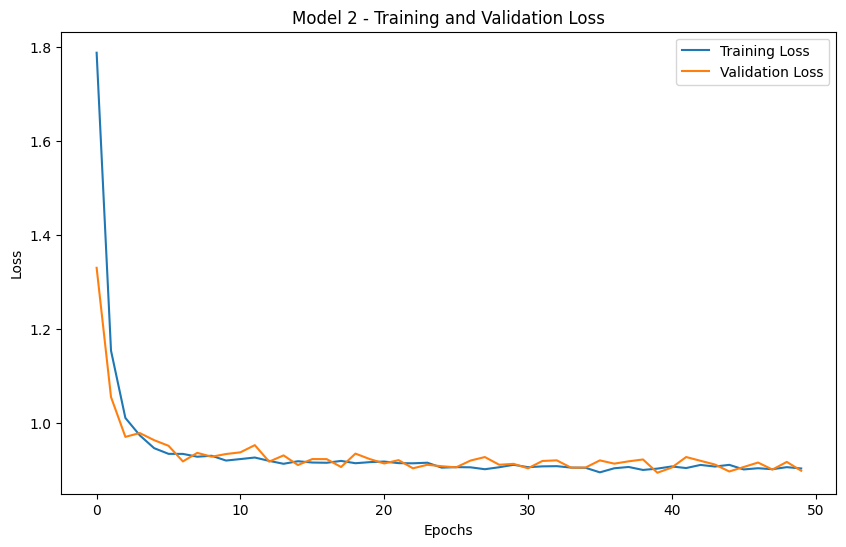

In [ ]:
X2 = model2_data_std.drop(columns=['UHI Index']).values
y2 = model2_data_std['UHI Index'].values

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.3, random_state=123)

model2 = Sequential([
    Dense(30, activation='linear', kernel_regularizer=regularizers.l2(0.01), input_shape=(X2_train.shape[1],)),
    Dense(30, activation='relu'),
    Dropout(0.2),
    Dense(30, activation='linear', kernel_regularizer=regularizers.l2(0.01)),
    Dense(30, activation='relu'),
    Dropout(0.2),
    Dense(30, activation='linear', kernel_regularizer=regularizers.l2(0.01)),
    Dense(30, activation='relu'),
    Dropout(0.2),
    Dense(30, activation='linear', kernel_regularizer=regularizers.l2(0.01)),
    Dense(30, activation='relu'),
    Dropout(0.2),
    Dense(30, activation='linear', kernel_regularizer=regularizers.l2(0.01)),
    Dense(30, activation='relu'),
    Dropout(0.2),
    Dense(30, activation='linear', kernel_regularizer=regularizers.l2(0.01)),
    Dense(30, activation='relu'),
    Dropout(0.2),
    Dense(30, activation='linear'),
    Dense(30, activation='relu'),
    Dense(1, activation='linear')
])

model2.compile(optimizer='adam', loss="MSE")

history2 = model2.fit(X2_train, y2_train, epochs=50, batch_size=10, validation_split=0.2, verbose=1)

y2_pred = model2.predict(X2_test)
r2_model2 = r2_score(y2_test, y2_pred)
mse_model2 = mean_squared_error(y2_test, y2_pred)

plt.figure(figsize=(10, 6))
plt.plot(history2.history['loss'], label='Training Loss')
plt.plot(history2.history['val_loss'], label='Validation Loss')
plt.title('Model 2 - Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.savefig(f"{DATA_PATH}/model2_history_{timestamp}.png")
plt.show()


Model 3 - Training data shape: X: (5848, 53), y: (5848,)
Epoch 1/100
147/147 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 9.8546 - val_loss: 2.8771
Epoch 2/100
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2.2680 - val_loss: 1.2753
Epoch 3/100
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.1276 - val_loss: 0.9436
Epoch 4/100
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.9088 - val_loss: 0.8337
Epoch 5/100
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.8046 - val_loss: 0.8015
Epoch 6/100
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.7964 - val_loss: 0.7845
Epoch 7/100
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.7669 - val_loss: 0.7512
Epoch 8/100
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.7344 - val_loss: 0.7406
Epoch 9/100
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.7066 - val_loss: 0.7420
Epoch 10/100
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.6835 - val_loss: 0.7273
Epoch 11/100
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.6989 - v

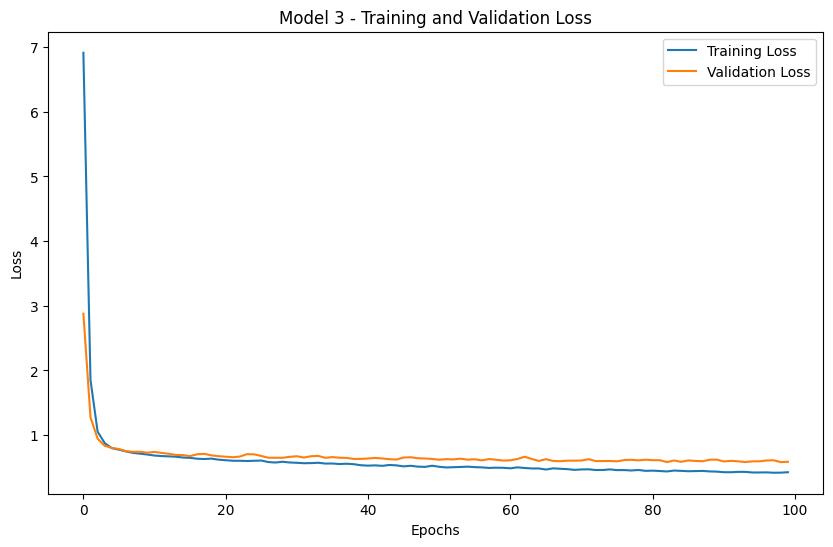

In [ ]:
X3 = model3_data_std.drop(columns=['UHI Index']).values
y3 = model3_data_std['UHI Index'].values

X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.3, random_state=123)
print(f"Model 3 - Training data shape: X: {X3_train.shape}, y: {y3_train.shape}")

model3 = Sequential([
    Dense(512, input_shape=(X3_train.shape[1],), activation='relu'),
    Dropout(0.2),
    Dense(128, activation='linear', kernel_regularizer=regularizers.l2(0.01)),
    Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.1)),
    Dense(32, activation='linear', kernel_regularizer=regularizers.l2(0.01)),
    Dense(16, activation='relu', kernel_regularizer=regularizers.l2(0.1)),
    Dense(1, activation='linear')
])

model3.compile(optimizer='adam', loss="MSE")

history3 = model3.fit(X3_train, y3_train, epochs=100, batch_size=32, validation_split=0.2, verbose=1)

y3_pred = model3.predict(X3_test)
r2_model3 = r2_score(y3_test, y3_pred)
mse_model3 = mean_squared_error(y3_test, y3_pred)
print(f"Model 3 (Satellite + Building + Tree Features) - R²: {r2_model3:.4f}, MSE: {mse_model3:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(history3.history['loss'], label='Training Loss')
plt.plot(history3.history['val_loss'], label='Validation Loss')
plt.title('Model 3 - Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.savefig(f"{DATA_PATH}/model3_history_{timestamp}.png")
plt.show()

# Part 2B. Basic Models with Upgraded Features

Loading specified merged dataset: /content/drive/MyDrive/uhi/Code/Data/output/uhi_with_satellite_rings_cleaned_20250505_002612.csv
Loaded dataset with shape: (11229, 85)
Using 'UHI Index_features' as the target variable
Satellite band features: 11
Satellite index features: 6
Satellite ring features: 18
Building features: 13
Tree features: 12

Feature counts after validation:
Basic satellite features: 17
All satellite features (including rings): 35
All features: 60

Checking for missing values in features...
Features with missing values:
B02_ring1_mean_ring     872
B02_ring1_std_ring      872
B03_ring1_mean_ring     872
B03_ring1_std_ring      872
B04_ring1_mean_ring     872
B04_ring1_std_ring      872
B08_ring1_mean_ring     872
B08_ring1_std_ring      872
B11_ring1_mean_ring     872
B11_ring1_std_ring      872
B12_ring1_mean_ring     872
B12_ring1_std_ring      872
ndvi_ring1_mean_ring    872
ndvi_ring1_std_ring     872
ndbi_ring1_mean_ring    872
ndbi_ring1_std_ring     872
ndwi_ring

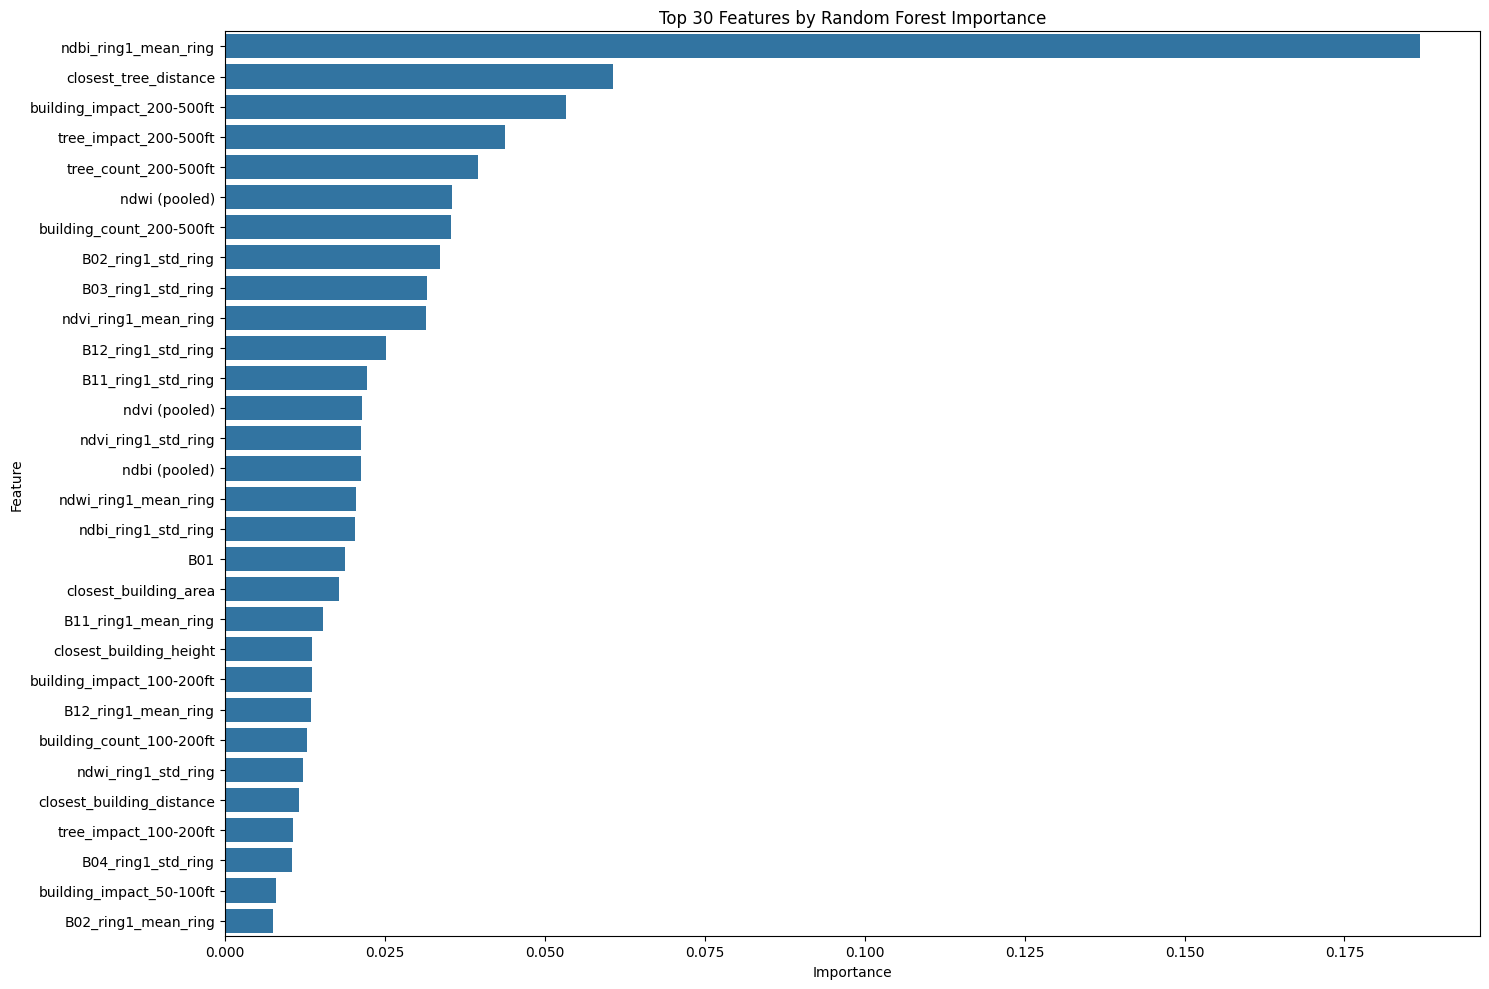


Model comparison results saved to: /content/drive/MyDrive/uhi/Code/Data/output/model_comparison_results_20250506_041934.csv


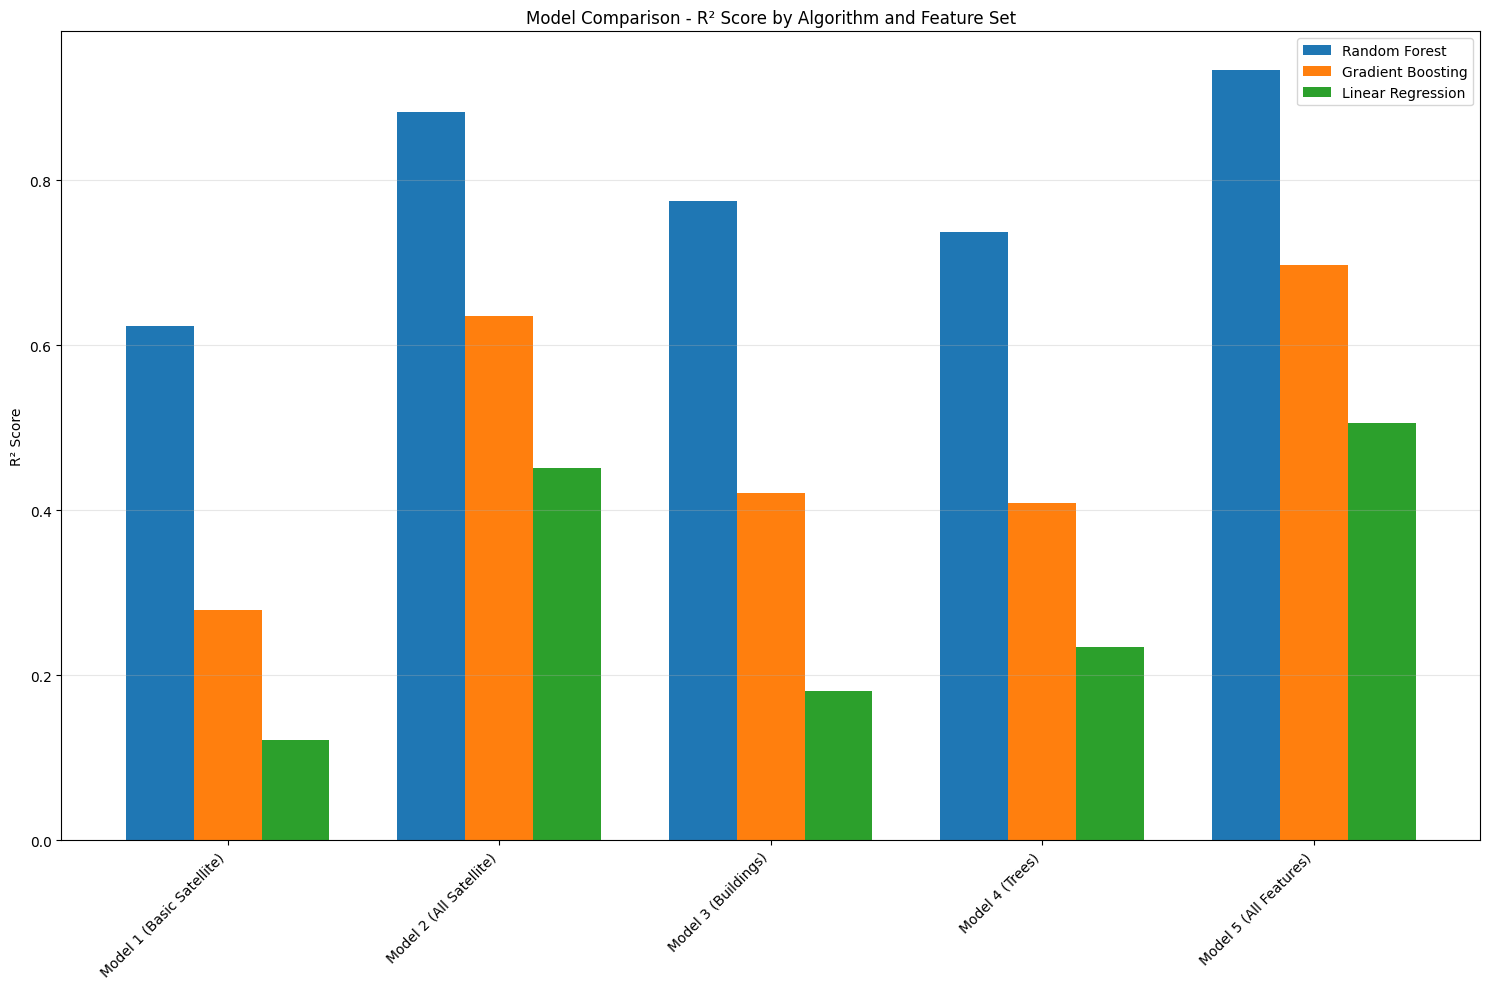


Model training and evaluation complete!


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
from datetime import datetime

OUTPUT_DIR = '/content/drive/MyDrive/uhi/Code/Data/output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

def find_latest_file(directory, pattern):
    files = glob.glob(os.path.join(directory, pattern))
    if not files:
        return None
    return max(files, key=os.path.getmtime)

latest_merged_file = '/content/drive/MyDrive/uhi/Code/Data/output/uhi_with_satellite_rings_cleaned_20250505_002612.csv'

print(f"Loading specified merged dataset: {latest_merged_file}")
uhi_data = pd.read_csv(latest_merged_file)
print(f"Loaded dataset with shape: {uhi_data.shape}")

uhi_columns = [col for col in uhi_data.columns if 'uhi' in col.lower() and 'index' in col.lower()]
if len(uhi_columns) > 0:
    uhi_col = uhi_columns[0]
    print(f"Using '{uhi_col}' as the target variable")
else:
    print("Error: No UHI Index column found in dataset")
    raise ValueError("Target variable not found")

satellite_band_cols = [col for col in uhi_data.columns if col.startswith('B') and len(col) <= 4 and not '_ring' in col]
satellite_index_cols = [col for col in uhi_data.columns if col.lower() in ['ndvi', 'ndbi', 'ndwi'] or
                        (any(idx in col.lower() for idx in ['ndvi', 'ndbi', 'ndwi']) and not '_ring' in col)]
satellite_ring_cols = [col for col in uhi_data.columns if '_ring' in col]
building_cols = [col for col in uhi_data.columns if 'building' in col.lower()]
tree_cols = [col for col in uhi_data.columns if 'tree' in col.lower()]

exclude_cols = ['geometry', 'join_timestamp', 'datetime'] + \
              [col for col in uhi_data.columns if 'latitude' in col.lower() or 'longitude' in col.lower()]

exclude_cols = ['geometry', 'join_timestamp', 'datetime'] + \
              [col for col in uhi_data.columns if 'latitude' in col.lower() or 'longitude' in col.lower()]

uhi_cols = [col for col in uhi_data.columns if 'uhi' in col.lower() and 'index' in col.lower()]
if len(uhi_cols) > 1:
    exclude_cols.extend([col for col in uhi_cols if col != uhi_col])
    print(f"Excluding duplicate UHI Index columns to prevent data leakage: {[col for col in uhi_cols if col != uhi_col]}")

for exclude_pattern in exclude_cols:
    satellite_band_cols = [col for col in satellite_band_cols if exclude_pattern not in col.lower()]
    satellite_index_cols = [col for col in satellite_index_cols if exclude_pattern not in col.lower()]
    satellite_ring_cols = [col for col in satellite_ring_cols if exclude_pattern not in col.lower()]
    building_cols = [col for col in building_cols if exclude_pattern not in col.lower()]
    tree_cols = [col for col in tree_cols if exclude_pattern not in col.lower()]

print(f"Satellite band features: {len(satellite_band_cols)}")
print(f"Satellite index features: {len(satellite_index_cols)}")
print(f"Satellite ring features: {len(satellite_ring_cols)}")
print(f"Building features: {len(building_cols)}")
print(f"Tree features: {len(tree_cols)}")

basic_satellite_cols = satellite_band_cols + satellite_index_cols
all_satellite_cols = basic_satellite_cols + satellite_ring_cols
all_feature_cols = all_satellite_cols + building_cols + tree_cols

basic_satellite_cols = [col for col in basic_satellite_cols if col in uhi_data.columns]
all_satellite_cols = [col for col in all_satellite_cols if col in uhi_data.columns]
all_feature_cols = [col for col in all_feature_cols if col in uhi_data.columns]

print(f"\nFeature counts after validation:")
print(f"Basic satellite features: {len(basic_satellite_cols)}")
print(f"All satellite features (including rings): {len(all_satellite_cols)}")
print(f"All features: {len(all_feature_cols)}")

print("\nChecking for missing values in features...")
missing_counts = uhi_data[all_feature_cols + [uhi_col]].isnull().sum()
features_with_missing = missing_counts[missing_counts > 0]
if not features_with_missing.empty:
    print("Features with missing values:")
    print(features_with_missing)
else:
    print("No missing values found in features")

uhi_data_cleaned = uhi_data.copy()
for col in all_feature_cols:
    if col in uhi_data_cleaned.columns:
        null_count = uhi_data_cleaned[col].isnull().sum()
        if null_count > 0:
            if 'distance' in col.lower():
                max_val = uhi_data_cleaned[col].replace([np.inf, -np.inf], np.nan).max()
                fill_value = max_val * 2 if not pd.isna(max_val) else 10000.0
                uhi_data_cleaned[col] = uhi_data_cleaned[col].replace([np.inf, -np.inf], fill_value)
                uhi_data_cleaned[col] = uhi_data_cleaned[col].fillna(fill_value)
                print(f"Filled {null_count} nulls in {col} with large value: {fill_value:.1f}")
            elif any(term in col.lower() for term in ['count', 'area', 'impact']):
                uhi_data_cleaned[col] = uhi_data_cleaned[col].fillna(0)
                print(f"Filled {null_count} nulls in {col} with 0")
            else:
                col_mean = uhi_data_cleaned[col].replace([np.inf, -np.inf], np.nan).mean()
                uhi_data_cleaned[col] = uhi_data_cleaned[col].replace([np.inf, -np.inf], col_mean)
                uhi_data_cleaned[col] = uhi_data_cleaned[col].fillna(col_mean)
                print(f"Filled {null_count} nulls in {col} with mean: {col_mean:.4f}")

        inf_count = np.sum(np.isinf(uhi_data_cleaned[col].values))
        if inf_count > 0:
            max_val = uhi_data_cleaned[col].replace([np.inf, -np.inf], np.nan).max()
            fill_value = max_val * 2 if not pd.isna(max_val) else 10000.0
            uhi_data_cleaned[col] = uhi_data_cleaned[col].replace([np.inf, -np.inf], fill_value)
            print(f"Replaced {inf_count} infinity values in {col} with {fill_value:.1f}")

print("\nStandardizing features...")
for col in all_feature_cols + [uhi_col]:
    if col in uhi_data_cleaned.columns:
        uhi_data_cleaned[col] = pd.to_numeric(uhi_data_cleaned[col], errors='coerce')
        uhi_data_cleaned[col] = uhi_data_cleaned[col].fillna(uhi_data_cleaned[col].mean())
        uhi_data_cleaned[col] = uhi_data_cleaned[col].replace([np.inf, -np.inf], uhi_data_cleaned[col].mean())

uhi_data_std = uhi_data_cleaned.copy()
for col in all_feature_cols:
    col_std = uhi_data_cleaned[col].std()
    if col_std == 0:
        print(f"Warning: Column {col} has zero standard deviation. Keeping original values.")
        continue

    col_mean = uhi_data_cleaned[col].mean()
    uhi_data_std[col] = (uhi_data_cleaned[col] - col_mean) / col_std

models = {
    "Model 1 (Basic Satellite)": {
        "features": basic_satellite_cols,
        "description": "Basic satellite bands and indices only"
    },
    "Model 2 (All Satellite)": {
        "features": all_satellite_cols,
        "description": "All satellite features including ring statistics"
    },
    "Model 3 (Buildings)": {
        "features": basic_satellite_cols + building_cols,
        "description": "Basic satellite features + building features"
    },
    "Model 4 (Trees)": {
        "features": basic_satellite_cols + tree_cols,
        "description": "Basic satellite features + tree features"
    },
    "Model 5 (All Features)": {
        "features": all_feature_cols,
        "description": "All available features"
    }
}

X = uhi_data_std[all_feature_cols]
y = uhi_data_cleaned[uhi_col]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

results = []
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

for model_name, model_info in models.items():
    features = model_info["features"]
    description = model_info["description"]

    print(f"\n{model_name}: {description}")
    print(f"Number of features: {len(features)}")

    X_train_model = X_train[features]
    X_test_model = X_test[features]

    lr = LinearRegression()
    lr.fit(X_train_model, y_train)
    y_pred_lr = lr.predict(X_test_model)
    mse_lr = mean_squared_error(y_test, y_pred_lr)
    r2_lr = r2_score(y_test, y_pred_lr)

    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X_train_model, y_train)
    y_pred_rf = rf.predict(X_test_model)
    mse_rf = mean_squared_error(y_test, y_pred_rf)
    r2_rf = r2_score(y_test, y_pred_rf)

    gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
    gb.fit(X_train_model, y_train)
    y_pred_gb = gb.predict(X_test_model)
    mse_gb = mean_squared_error(y_test, y_pred_gb)
    r2_gb = r2_score(y_test, y_pred_gb)

    for algo_name, mse, r2 in [
        ("Linear Regression", mse_lr, r2_lr),
        ("Random Forest", mse_rf, r2_rf),
        ("Gradient Boosting", mse_gb, r2_gb)
    ]:
        results.append({
            "Model": model_name,
            "Algorithm": algo_name,
            "Features": len(features),
            "MSE": mse,
            "R²": r2,
            "RMSE": np.sqrt(mse)
        })
        print(f"  {algo_name}: MSE = {mse:.6f}, R² = {r2:.6f}, RMSE = {np.sqrt(mse):.6f}")

    if model_name == "Model 5 (All Features)":
        feature_importance_rf = pd.DataFrame({
            'Feature': features,
            'Importance': rf.feature_importances_
        }).sort_values('Importance', ascending=False)

        rf_importance_path = f"{OUTPUT_DIR}/rf_feature_importance_{timestamp}.csv"
        feature_importance_rf.to_csv(rf_importance_path, index=False)
        print(f"\nRandom Forest feature importance saved to: {rf_importance_path}")

        plt.figure(figsize=(15, 10))
        top_features = feature_importance_rf.head(30)
        sns.barplot(x='Importance', y='Feature', data=top_features)
        plt.title('Top 30 Features by Random Forest Importance')
        plt.tight_layout()
        rf_plot_path = f"{OUTPUT_DIR}/rf_feature_importance_{timestamp}.png"
        plt.savefig(rf_plot_path, dpi=300, bbox_inches='tight')
        plt.show()

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(['Model', 'MSE'])

results_path = f"{OUTPUT_DIR}/model_comparison_results_{timestamp}.csv"
results_df.to_csv(results_path, index=False)
print(f"\nModel comparison results saved to: {results_path}")

plt.figure(figsize=(15, 10))

models_list = results_df['Model'].unique()
algos = results_df['Algorithm'].unique()
x = np.arange(len(models_list))
width = 0.25

for i, algo in enumerate(algos):
    algo_results = results_df[results_df['Algorithm'] == algo]
    r2_values = [
        algo_results[algo_results['Model'] == model]['R²'].values[0]
        for model in models_list
    ]
    plt.bar(x + (i - 1) * width, r2_values, width, label=algo)

plt.ylabel('R² Score')
plt.title('Model Comparison - R² Score by Algorithm and Feature Set')
plt.xticks(x, models_list, rotation=45, ha='right')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

comparison_plot_path = f"{OUTPUT_DIR}/model_comparison_{timestamp}.png"
plt.savefig(comparison_plot_path, dpi=300, bbox_inches='tight')
plt.show()

print("\nModel training and evaluation complete!")

Loading specified merged dataset: /content/drive/MyDrive/uhi/Code/Data/output/uhi_with_satellite_rings_cleaned_20250505_002612.csv
Loaded dataset with shape: (11229, 85)
Using 'UHI Index_features' as the target variable
Satellite band features: 11
Satellite index features: 3
Satellite pooled features: 14
Satellite ring features: 18
Building features: 13
Tree features: 12

Feature counts after validation:
Basic satellite features: 14
Basic satellite + pooled features: 28
Basic satellite + ring features: 32
All satellite features (basic + pooled + ring): 46
All features: 71

Checking for missing values in features...
Features with missing values:
B02_ring1_mean_ring     872
B02_ring1_std_ring      872
B03_ring1_mean_ring     872
B03_ring1_std_ring      872
B04_ring1_mean_ring     872
B04_ring1_std_ring      872
B08_ring1_mean_ring     872
B08_ring1_std_ring      872
B11_ring1_mean_ring     872
B11_ring1_std_ring      872
B12_ring1_mean_ring     872
B12_ring1_std_ring      872
ndvi_ring1_

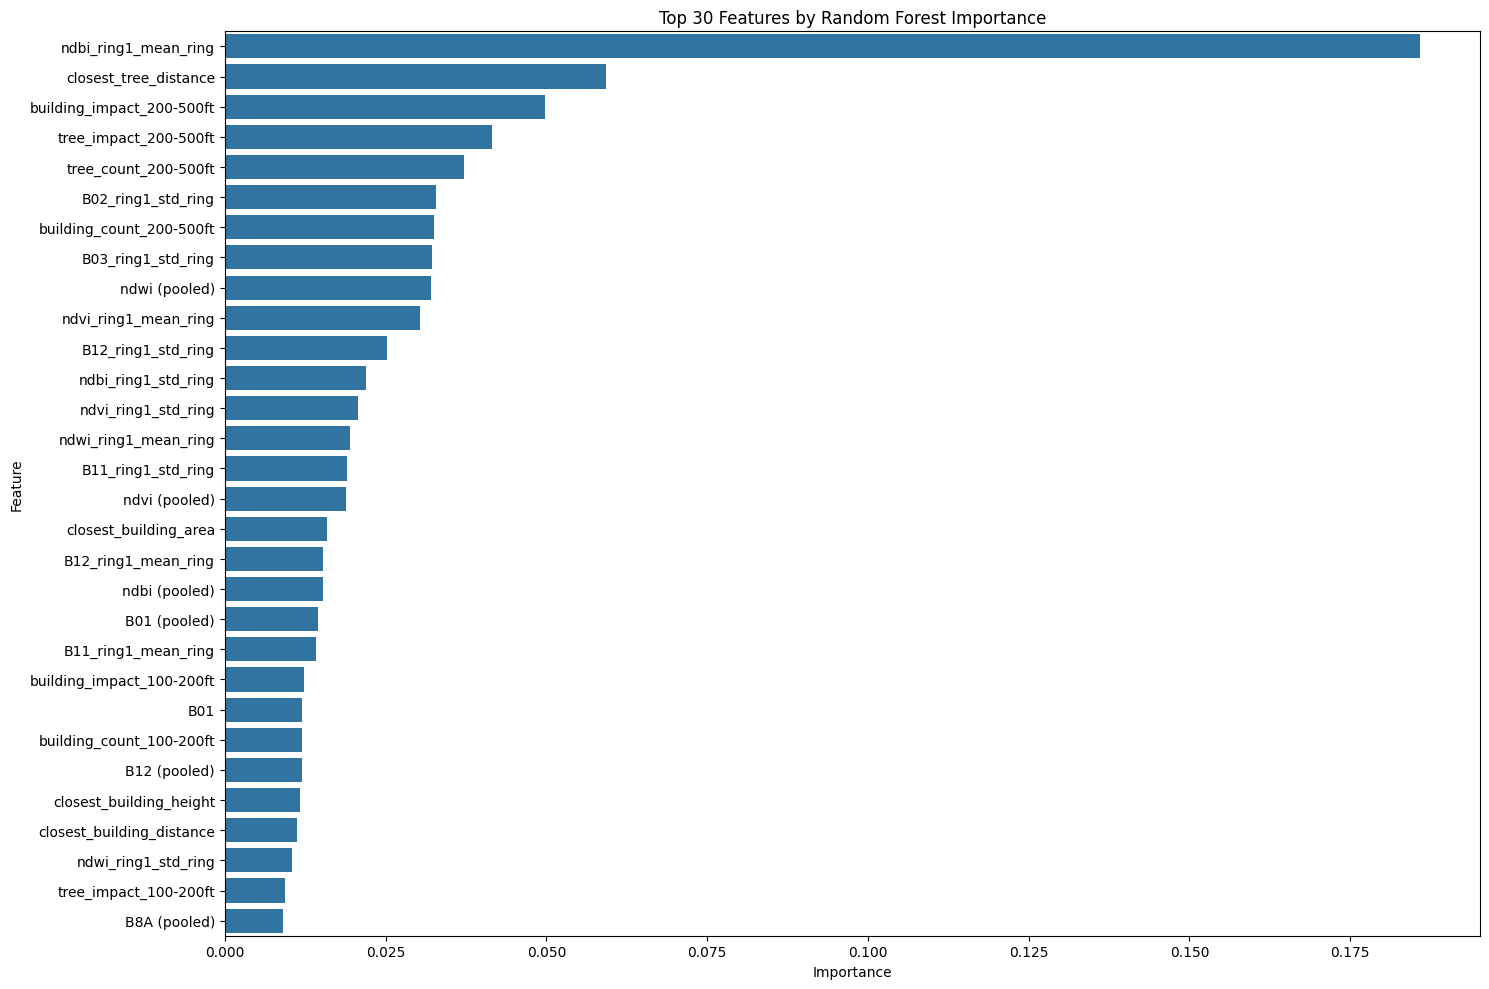


Model comparison results saved to: /content/drive/MyDrive/uhi/Code/Data/output/model_comparison_results_20250506_042454.csv


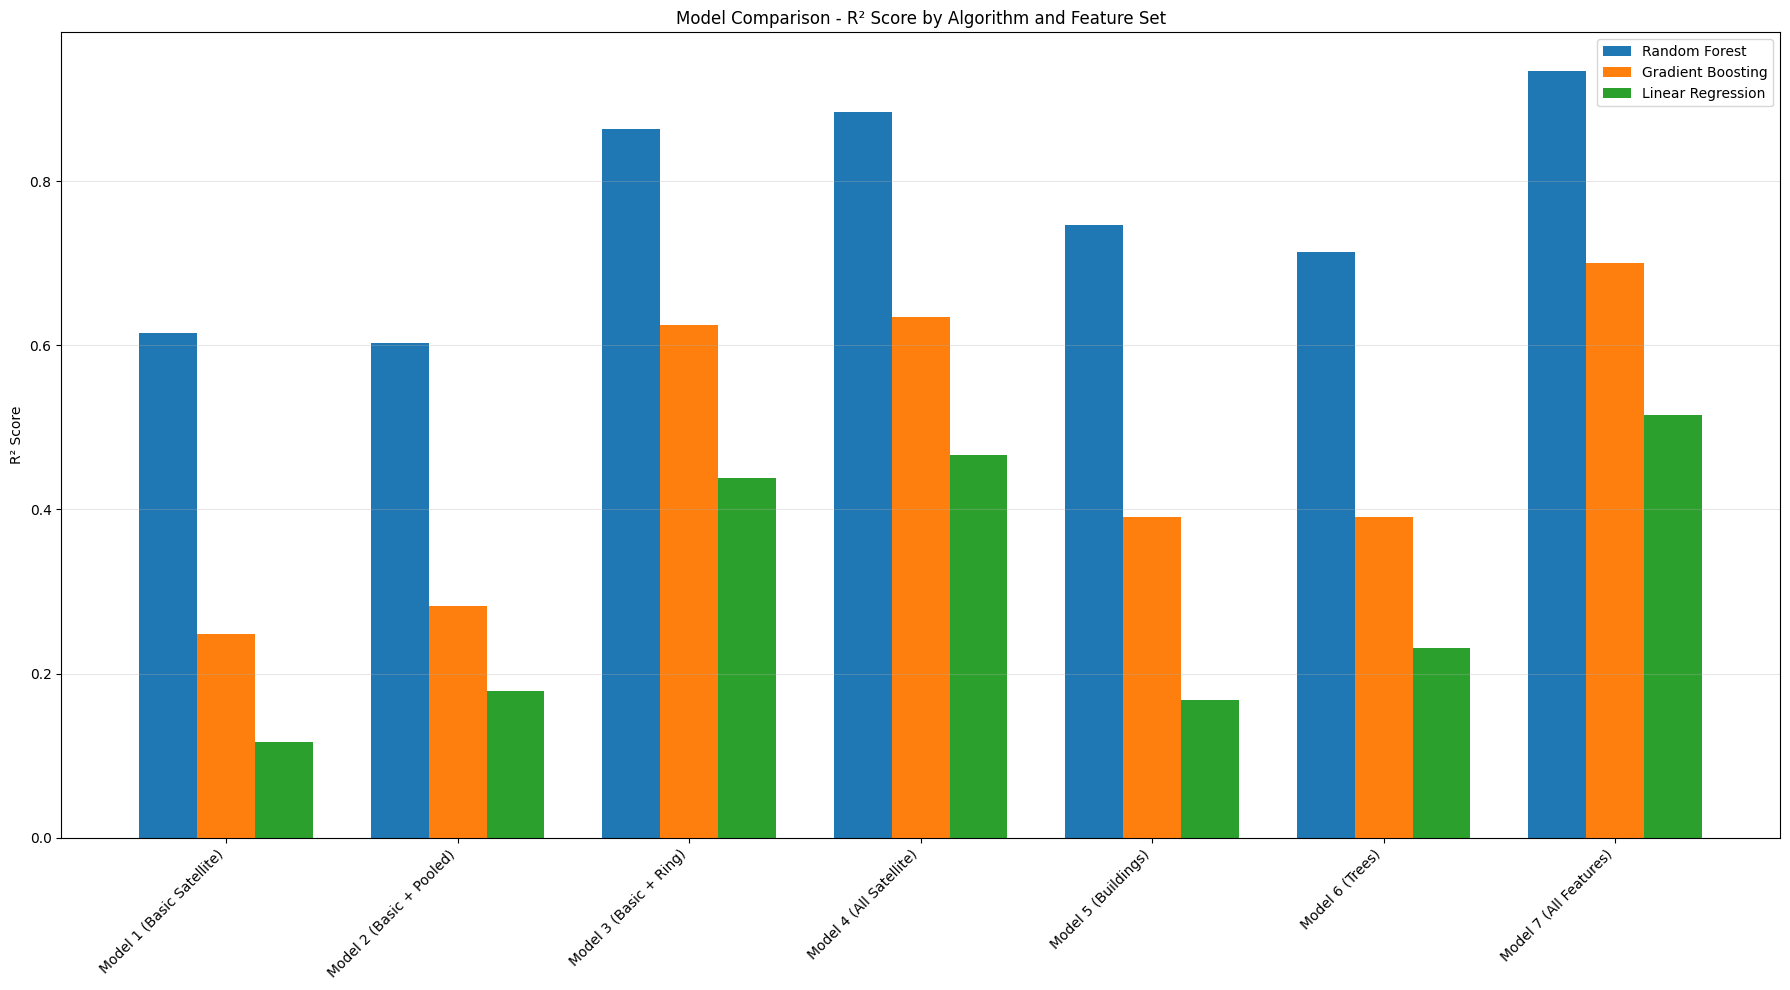


Model training and evaluation complete!


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
from datetime import datetime

OUTPUT_DIR = '/content/drive/MyDrive/uhi/Code/Data/output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

def find_latest_file(directory, pattern):
    files = glob.glob(os.path.join(directory, pattern))
    if not files:
        return None
    return max(files, key=os.path.getmtime)

latest_merged_file = '/content/drive/MyDrive/uhi/Code/Data/output/uhi_with_satellite_rings_cleaned_20250505_002612.csv'

print(f"Loading specified merged dataset: {latest_merged_file}")
uhi_data = pd.read_csv(latest_merged_file)
print(f"Loaded dataset with shape: {uhi_data.shape}")

uhi_columns = [col for col in uhi_data.columns if 'uhi' in col.lower() and 'index' in col.lower()]
if len(uhi_columns) > 0:
    uhi_col = uhi_columns[0]
    print(f"Using '{uhi_col}' as the target variable")
else:
    print("Error: No UHI Index column found in dataset")
    raise ValueError("Target variable not found")

satellite_band_cols = [col for col in uhi_data.columns if col.startswith('B') and len(col) <= 4 and not '_ring' in col and not 'pooled' in col.lower()]
satellite_index_cols = [col for col in uhi_data.columns if col.lower() in ['ndvi', 'ndbi', 'ndwi'] or
                        (any(idx in col.lower() for idx in ['ndvi', 'ndbi', 'ndwi']) and not '_ring' in col and not 'pooled' in col.lower())]

satellite_pooled_cols = [col for col in uhi_data.columns if 'pooled' in col.lower() and not '_ring' in col]
satellite_ring_cols = [col for col in uhi_data.columns if '_ring' in col]

building_cols = [col for col in uhi_data.columns if 'building' in col.lower()]
tree_cols = [col for col in uhi_data.columns if 'tree' in col.lower()]

exclude_cols = ['geometry', 'join_timestamp', 'datetime'] + \
              [col for col in uhi_data.columns if 'latitude' in col.lower() or 'longitude' in col.lower()]

uhi_cols = [col for col in uhi_data.columns if 'uhi' in col.lower() and 'index' in col.lower()]
if len(uhi_cols) > 1:
    exclude_cols.extend([col for col in uhi_cols if col != uhi_col])
    print(f"Excluding duplicate UHI Index columns to prevent data leakage: {[col for col in uhi_cols if col != uhi_col]}")

for exclude_pattern in exclude_cols:
    satellite_band_cols = [col for col in satellite_band_cols if exclude_pattern not in col.lower()]
    satellite_index_cols = [col for col in satellite_index_cols if exclude_pattern not in col.lower()]
    satellite_pooled_cols = [col for col in satellite_pooled_cols if exclude_pattern not in col.lower()]
    satellite_ring_cols = [col for col in satellite_ring_cols if exclude_pattern not in col.lower()]
    building_cols = [col for col in building_cols if exclude_pattern not in col.lower()]
    tree_cols = [col for col in tree_cols if exclude_pattern not in col.lower()]

print(f"Satellite band features: {len(satellite_band_cols)}")
print(f"Satellite index features: {len(satellite_index_cols)}")
print(f"Satellite pooled features: {len(satellite_pooled_cols)}")
print(f"Satellite ring features: {len(satellite_ring_cols)}")
print(f"Building features: {len(building_cols)}")
print(f"Tree features: {len(tree_cols)}")

basic_satellite_cols = satellite_band_cols + satellite_index_cols
basic_satellite_pooled_cols = basic_satellite_cols + satellite_pooled_cols
basic_satellite_ring_cols = basic_satellite_cols + satellite_ring_cols
all_satellite_cols = basic_satellite_cols + satellite_pooled_cols + satellite_ring_cols
all_feature_cols = all_satellite_cols + building_cols + tree_cols

basic_satellite_cols = [col for col in basic_satellite_cols if col in uhi_data.columns]
basic_satellite_pooled_cols = [col for col in basic_satellite_pooled_cols if col in uhi_data.columns]
basic_satellite_ring_cols = [col for col in basic_satellite_ring_cols if col in uhi_data.columns]
all_satellite_cols = [col for col in all_satellite_cols if col in uhi_data.columns]
all_feature_cols = [col for col in all_feature_cols if col in uhi_data.columns]

print(f"\nFeature counts after validation:")
print(f"Basic satellite features: {len(basic_satellite_cols)}")
print(f"Basic satellite + pooled features: {len(basic_satellite_pooled_cols)}")
print(f"Basic satellite + ring features: {len(basic_satellite_ring_cols)}")
print(f"All satellite features (basic + pooled + ring): {len(all_satellite_cols)}")
print(f"All features: {len(all_feature_cols)}")

print("\nChecking for missing values in features...")
missing_counts = uhi_data[all_feature_cols + [uhi_col]].isnull().sum()
features_with_missing = missing_counts[missing_counts > 0]
if not features_with_missing.empty:
    print("Features with missing values:")
    print(features_with_missing)
else:
    print("No missing values found in features")

uhi_data_cleaned = uhi_data.copy()
for col in all_feature_cols:
    if col in uhi_data_cleaned.columns:
        null_count = uhi_data_cleaned[col].isnull().sum()
        if null_count > 0:
            if 'distance' in col.lower():
                max_val = uhi_data_cleaned[col].replace([np.inf, -np.inf], np.nan).max()
                fill_value = max_val * 2 if not pd.isna(max_val) else 10000.0
                uhi_data_cleaned[col] = uhi_data_cleaned[col].replace([np.inf, -np.inf], fill_value)
                uhi_data_cleaned[col] = uhi_data_cleaned[col].fillna(fill_value)
                print(f"Filled {null_count} nulls in {col} with large value: {fill_value:.1f}")
            elif any(term in col.lower() for term in ['count', 'area', 'impact']):
                uhi_data_cleaned[col] = uhi_data_cleaned[col].fillna(0)
                print(f"Filled {null_count} nulls in {col} with 0")
            else:
                col_mean = uhi_data_cleaned[col].replace([np.inf, -np.inf], np.nan).mean()
                uhi_data_cleaned[col] = uhi_data_cleaned[col].replace([np.inf, -np.inf], col_mean)
                uhi_data_cleaned[col] = uhi_data_cleaned[col].fillna(col_mean)
                print(f"Filled {null_count} nulls in {col} with mean: {col_mean:.4f}")

        inf_count = np.sum(np.isinf(uhi_data_cleaned[col].values))
        if inf_count > 0:
            max_val = uhi_data_cleaned[col].replace([np.inf, -np.inf], np.nan).max()
            fill_value = max_val * 2 if not pd.isna(max_val) else 10000.0
            uhi_data_cleaned[col] = uhi_data_cleaned[col].replace([np.inf, -np.inf], fill_value)
            print(f"Replaced {inf_count} infinity values in {col} with {fill_value:.1f}")

print("\nStandardizing features...")
for col in all_feature_cols + [uhi_col]:
    if col in uhi_data_cleaned.columns:
        uhi_data_cleaned[col] = pd.to_numeric(uhi_data_cleaned[col], errors='coerce')
        uhi_data_cleaned[col] = uhi_data_cleaned[col].fillna(uhi_data_cleaned[col].mean())
        uhi_data_cleaned[col] = uhi_data_cleaned[col].replace([np.inf, -np.inf], uhi_data_cleaned[col].mean())

uhi_data_std = uhi_data_cleaned.copy()
for col in all_feature_cols:
    col_std = uhi_data_cleaned[col].std()
    if col_std == 0:
        print(f"Warning: Column {col} has zero standard deviation. Keeping original values.")
        continue

    col_mean = uhi_data_cleaned[col].mean()
    uhi_data_std[col] = (uhi_data_cleaned[col] - col_mean) / col_std

models = {
    "Model 1 (Basic Satellite)": {
        "features": basic_satellite_cols,
        "description": "Basic satellite bands and indices only"
    },
    "Model 2 (Basic + Pooled)": {
        "features": basic_satellite_pooled_cols,
        "description": "Basic satellite features + pooled features"
    },
    "Model 3 (Basic + Ring)": {
        "features": basic_satellite_ring_cols,
        "description": "Basic satellite features + ring features"
    },
    "Model 4 (All Satellite)": {
        "features": all_satellite_cols,
        "description": "All satellite features (basic + pooled + ring)"
    },
    "Model 5 (Buildings)": {
        "features": basic_satellite_cols + building_cols,
        "description": "Basic satellite features + building features"
    },
    "Model 6 (Trees)": {
        "features": basic_satellite_cols + tree_cols,
        "description": "Basic satellite features + tree features"
    },
    "Model 7 (All Features)": {
        "features": all_feature_cols,
        "description": "All available features"
    }
}

X = uhi_data_std[all_feature_cols]
y = uhi_data_cleaned[uhi_col]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

results = []
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

for model_name, model_info in models.items():
    features = model_info["features"]
    description = model_info["description"]

    print(f"\n{model_name}: {description}")
    print(f"Number of features: {len(features)}")

    X_train_model = X_train[features]
    X_test_model = X_test[features]

    lr = LinearRegression()
    lr.fit(X_train_model, y_train)
    y_pred_lr = lr.predict(X_test_model)
    mse_lr = mean_squared_error(y_test, y_pred_lr)
    r2_lr = r2_score(y_test, y_pred_lr)

    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X_train_model, y_train)
    y_pred_rf = rf.predict(X_test_model)
    mse_rf = mean_squared_error(y_test, y_pred_rf)
    r2_rf = r2_score(y_test, y_pred_rf)

    gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
    gb.fit(X_train_model, y_train)
    y_pred_gb = gb.predict(X_test_model)
    mse_gb = mean_squared_error(y_test, y_pred_gb)
    r2_gb = r2_score(y_test, y_pred_gb)

    for algo_name, mse, r2 in [
        ("Linear Regression", mse_lr, r2_lr),
        ("Random Forest", mse_rf, r2_rf),
        ("Gradient Boosting", mse_gb, r2_gb)
    ]:
        results.append({
            "Model": model_name,
            "Algorithm": algo_name,
            "Features": len(features),
            "MSE": mse,
            "R²": r2,
            "RMSE": np.sqrt(mse)
        })
        print(f"  {algo_name}: MSE = {mse:.6f}, R² = {r2:.6f}, RMSE = {np.sqrt(mse):.6f}")

    if model_name == "Model 7 (All Features)":
        feature_importance_rf = pd.DataFrame({
            'Feature': features,
            'Importance': rf.feature_importances_
        }).sort_values('Importance', ascending=False)

        rf_importance_path = f"{OUTPUT_DIR}/rf_feature_importance_{timestamp}.csv"
        feature_importance_rf.to_csv(rf_importance_path, index=False)
        print(f"\nRandom Forest feature importance saved to: {rf_importance_path}")

        plt.figure(figsize=(15, 10))
        top_features = feature_importance_rf.head(30)
        sns.barplot(x='Importance', y='Feature', data=top_features)
        plt.title('Top 30 Features by Random Forest Importance')
        plt.tight_layout()
        rf_plot_path = f"{OUTPUT_DIR}/rf_feature_importance_{timestamp}.png"
        plt.savefig(rf_plot_path, dpi=300, bbox_inches='tight')
        plt.show()

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(['Model', 'MSE'])

results_path = f"{OUTPUT_DIR}/model_comparison_results_{timestamp}.csv"
results_df.to_csv(results_path, index=False)
print(f"\nModel comparison results saved to: {results_path}")

plt.figure(figsize=(18, 10))

models_list = results_df['Model'].unique()
algos = results_df['Algorithm'].unique()
x = np.arange(len(models_list))
width = 0.25

for i, algo in enumerate(algos):
    algo_results = results_df[results_df['Algorithm'] == algo]
    r2_values = [
        algo_results[algo_results['Model'] == model]['R²'].values[0]
        for model in models_list
    ]
    plt.bar(x + (i - 1) * width, r2_values, width, label=algo)

plt.ylabel('R² Score')
plt.title('Model Comparison - R² Score by Algorithm and Feature Set')
plt.xticks(x, models_list, rotation=45, ha='right')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

comparison_plot_path = f"{OUTPUT_DIR}/model_comparison_{timestamp}.png"
plt.savefig(comparison_plot_path, dpi=300, bbox_inches='tight')
plt.show()

print("\nModel training and evaluation complete!")

In [ ]:
import pandas as pd
from datetime import datetime

# Define the input and output files
input_file = '/content/drive/MyDrive/uhi/Code/Data/output/uhi_with_satellite_rings_cleaned_20250505_002612.csv'
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_file = f'/content/drive/MyDrive/uhi/Code/Data/output/uhi_with_satellite_rings_cleaned_{timestamp}.csv'

# Load the dataset
print(f"Loading dataset from: {input_file}")
df = pd.read_csv(input_file)
print(f"Loaded dataset with shape: {df.shape}")

# Check for UHI Index columns
uhi_cols = [col for col in df.columns if 'uhi' in col.lower() and 'index' in col.lower()]
print(f"Found UHI Index columns: {uhi_cols}")

# Remove the UHI Index_tree column
cols_to_remove = ['UHI Index_tree']
for col in cols_to_remove:
    if col in df.columns:
        print(f"Removing column: {col}")
        df = df.drop(columns=[col])
    else:
        print(f"Column not found: {col}")

# Save the cleaned dataset
print(f"Saving cleaned dataset to: {output_file}")
df.to_csv(output_file, index=False)
print(f"Successfully saved dataset with shape: {df.shape}")

# Print remaining UHI Index columns
remaining_uhi_cols = [col for col in df.columns if 'uhi' in col.lower() and 'index' in col.lower()]
print(f"Remaining UHI Index columns: {remaining_uhi_cols}")

# Return the path of the cleaned file
print(f"\nCleaned file saved to: {output_file}")
print("Use this path in your model training code:")
print(f"latest_merged_file = '{output_file}'")

Loading dataset from: /content/drive/MyDrive/uhi/Code/Data/output/uhi_with_satellite_rings_cleaned_20250505_002612.csv
Loaded dataset with shape: (11229, 85)
Found UHI Index columns: ['UHI Index_features']
Column not found: UHI Index_tree
Saving cleaned dataset to: /content/drive/MyDrive/uhi/Code/Data/output/uhi_with_satellite_rings_cleaned_20250505_002728.csv
Successfully saved dataset with shape: (11229, 85)
Remaining UHI Index columns: ['UHI Index_features']

Cleaned file saved to: /content/drive/MyDrive/uhi/Code/Data/output/uhi_with_satellite_rings_cleaned_20250505_002728.csv
Use this path in your model training code:
latest_merged_file = '/content/drive/MyDrive/uhi/Code/Data/output/uhi_with_satellite_rings_cleaned_20250505_002728.csv'


Loading specified merged dataset: /content/drive/MyDrive/uhi/Code/Data/output/uhi_with_satellite_rings_cleaned_20250505_002612.csv
Loaded dataset with shape: (11229, 85)
Using 'UHI Index_features' as the target variable
Satellite band features: 11
Satellite index features: 6
Satellite ring features: 18
Building features: 13
Tree features: 12

Feature counts after validation:
Basic satellite features: 17
All satellite features (including rings): 35
All features: 60

Checking for missing values in features...
Features with missing values:
B02_ring1_mean_ring     872
B02_ring1_std_ring      872
B03_ring1_mean_ring     872
B03_ring1_std_ring      872
B04_ring1_mean_ring     872
B04_ring1_std_ring      872
B08_ring1_mean_ring     872
B08_ring1_std_ring      872
B11_ring1_mean_ring     872
B11_ring1_std_ring      872
B12_ring1_mean_ring     872
B12_ring1_std_ring      872
ndvi_ring1_mean_ring    872
ndvi_ring1_std_ring     872
ndbi_ring1_mean_ring    872
ndbi_ring1_std_ring     872
ndwi_ring

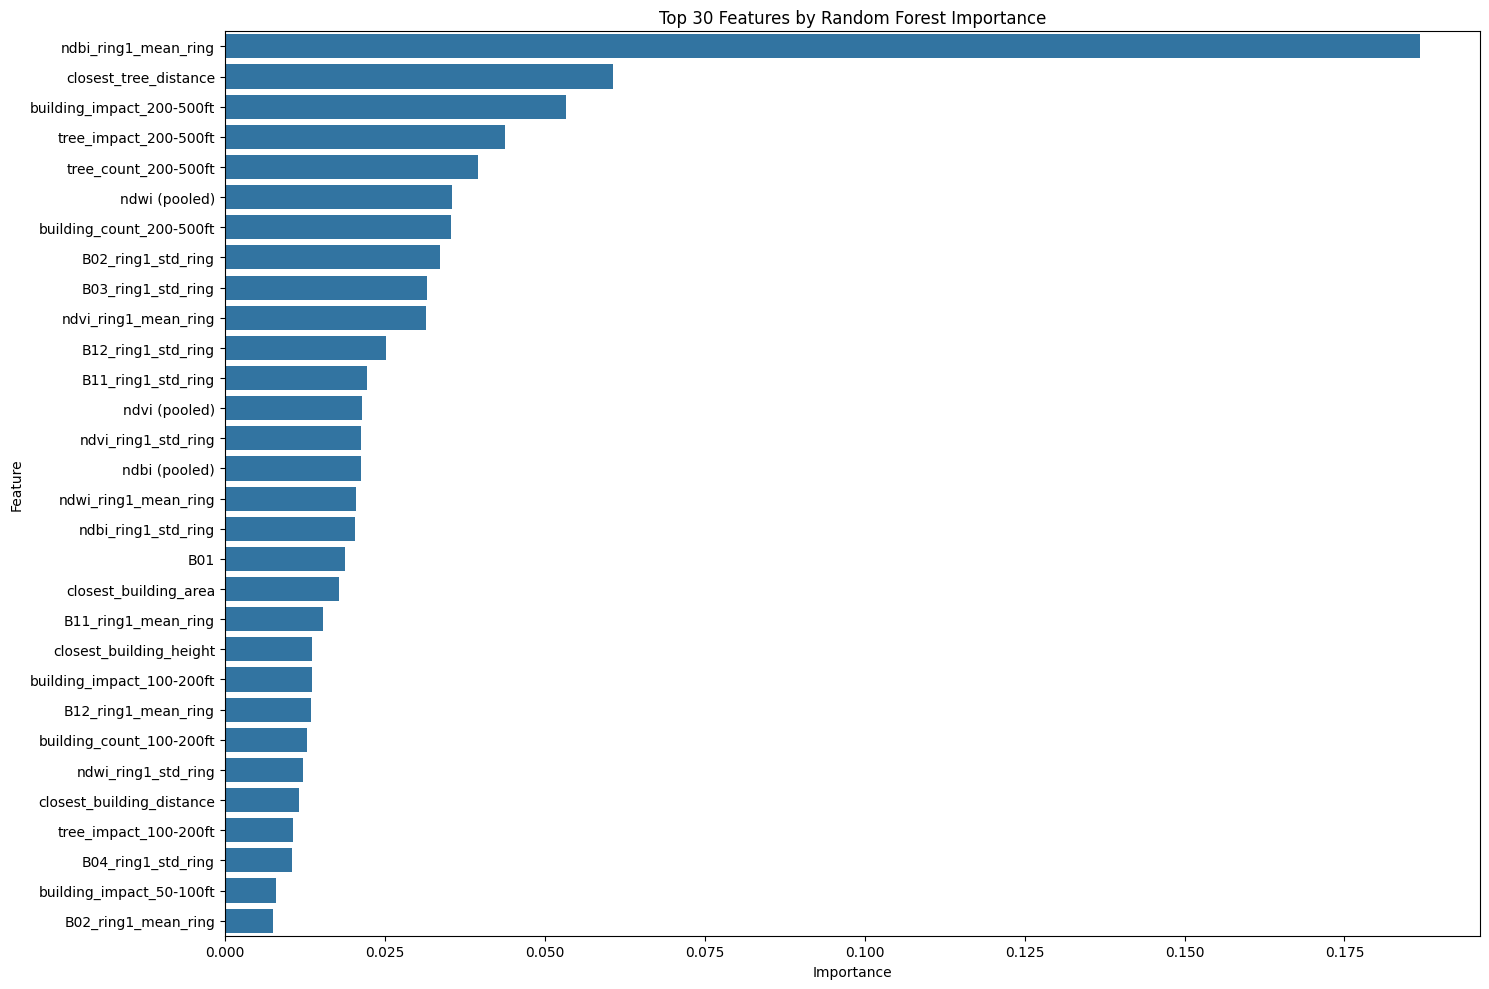


Model comparison results saved to: /content/drive/MyDrive/uhi/Code/Data/output/model_comparison_results_20250505_002819.csv


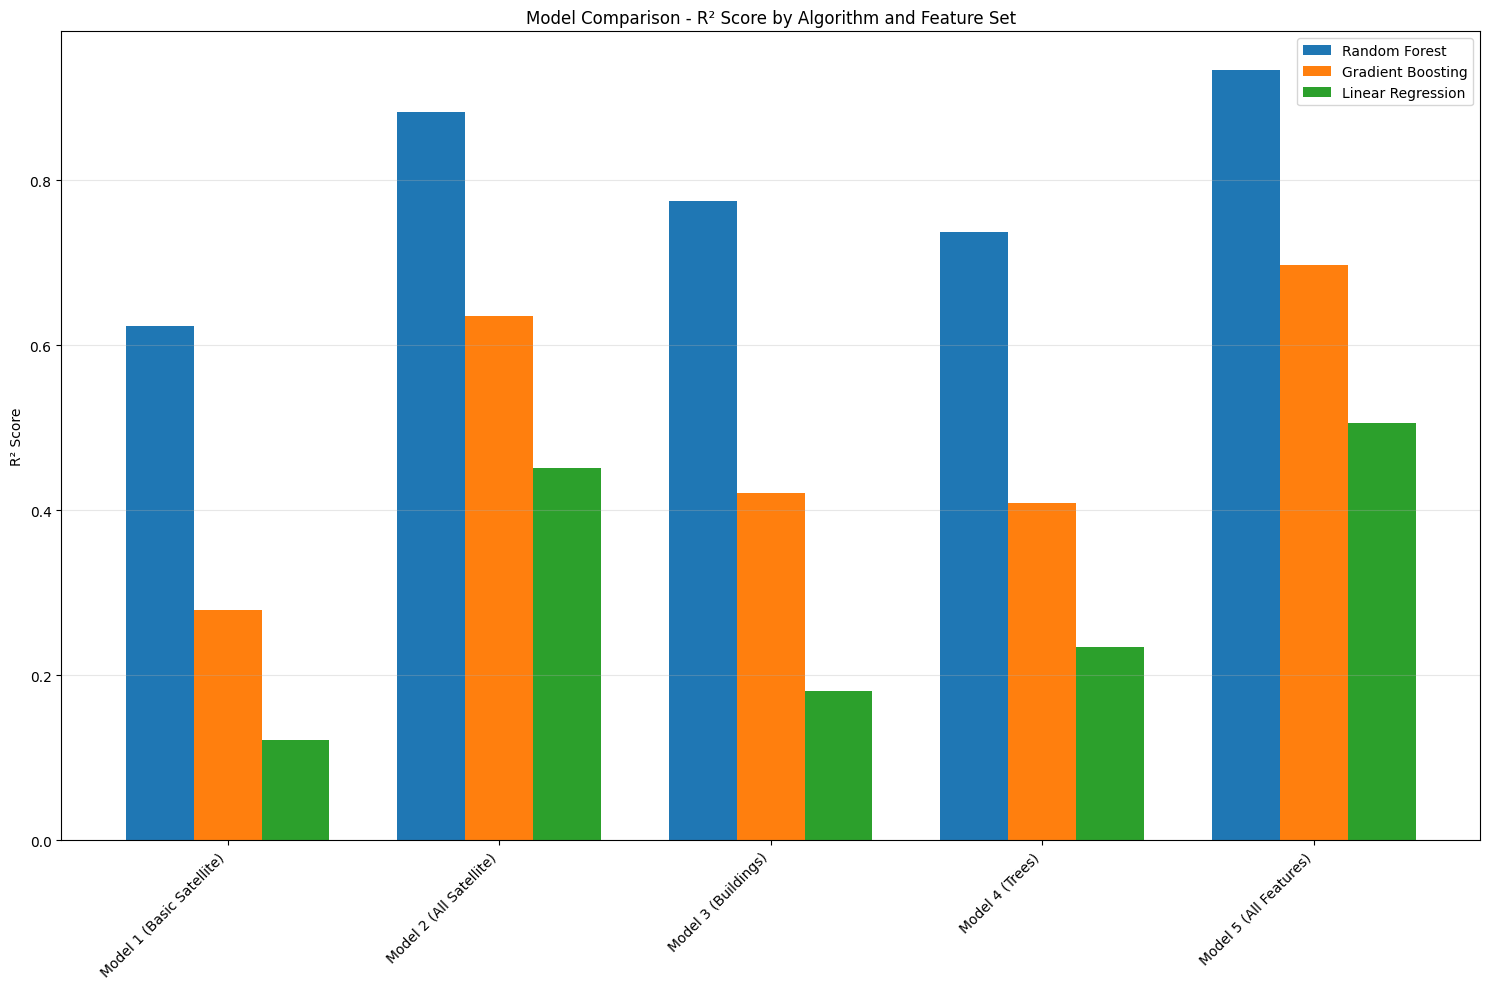


Model training and evaluation complete!


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
from datetime import datetime

OUTPUT_DIR = '/content/drive/MyDrive/uhi/Code/Data/output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

def find_latest_file(directory, pattern):
    files = glob.glob(os.path.join(directory, pattern))
    if not files:
        return None
    return max(files, key=os.path.getmtime)

latest_merged_file = '/content/drive/MyDrive/uhi/Code/Data/output/uhi_with_satellite_rings_cleaned_20250505_002612.csv'

print(f"Loading specified merged dataset: {latest_merged_file}")
uhi_data = pd.read_csv(latest_merged_file)
print(f"Loaded dataset with shape: {uhi_data.shape}")

uhi_columns = [col for col in uhi_data.columns if 'uhi' in col.lower() and 'index' in col.lower()]
if len(uhi_columns) > 0:
    uhi_col = uhi_columns[0]
    print(f"Using '{uhi_col}' as the target variable")
else:
    print("Error: No UHI Index column found in dataset")
    raise ValueError("Target variable not found")

satellite_band_cols = [col for col in uhi_data.columns if col.startswith('B') and len(col) <= 4 and not '_ring' in col]
satellite_index_cols = [col for col in uhi_data.columns if col.lower() in ['ndvi', 'ndbi', 'ndwi'] or
                        (any(idx in col.lower() for idx in ['ndvi', 'ndbi', 'ndwi']) and not '_ring' in col)]
satellite_ring_cols = [col for col in uhi_data.columns if '_ring' in col]
building_cols = [col for col in uhi_data.columns if 'building' in col.lower()]
tree_cols = [col for col in uhi_data.columns if 'tree' in col.lower()]

exclude_cols = ['geometry', 'join_timestamp', 'datetime'] + \
              [col for col in uhi_data.columns if 'latitude' in col.lower() or 'longitude' in col.lower()]

exclude_cols = ['geometry', 'join_timestamp', 'datetime'] + \
              [col for col in uhi_data.columns if 'latitude' in col.lower() or 'longitude' in col.lower()]

uhi_cols = [col for col in uhi_data.columns if 'uhi' in col.lower() and 'index' in col.lower()]
if len(uhi_cols) > 1:
    exclude_cols.extend([col for col in uhi_cols if col != uhi_col])
    print(f"Excluding duplicate UHI Index columns to prevent data leakage: {[col for col in uhi_cols if col != uhi_col]}")

for exclude_pattern in exclude_cols:
    satellite_band_cols = [col for col in satellite_band_cols if exclude_pattern not in col.lower()]
    satellite_index_cols = [col for col in satellite_index_cols if exclude_pattern not in col.lower()]
    satellite_ring_cols = [col for col in satellite_ring_cols if exclude_pattern not in col.lower()]
    building_cols = [col for col in building_cols if exclude_pattern not in col.lower()]
    tree_cols = [col for col in tree_cols if exclude_pattern not in col.lower()]

print(f"Satellite band features: {len(satellite_band_cols)}")
print(f"Satellite index features: {len(satellite_index_cols)}")
print(f"Satellite ring features: {len(satellite_ring_cols)}")
print(f"Building features: {len(building_cols)}")
print(f"Tree features: {len(tree_cols)}")

basic_satellite_cols = satellite_band_cols + satellite_index_cols
all_satellite_cols = basic_satellite_cols + satellite_ring_cols
all_feature_cols = all_satellite_cols + building_cols + tree_cols

basic_satellite_cols = [col for col in basic_satellite_cols if col in uhi_data.columns]
all_satellite_cols = [col for col in all_satellite_cols if col in uhi_data.columns]
all_feature_cols = [col for col in all_feature_cols if col in uhi_data.columns]

print(f"\nFeature counts after validation:")
print(f"Basic satellite features: {len(basic_satellite_cols)}")
print(f"All satellite features (including rings): {len(all_satellite_cols)}")
print(f"All features: {len(all_feature_cols)}")

print("\nChecking for missing values in features...")
missing_counts = uhi_data[all_feature_cols + [uhi_col]].isnull().sum()
features_with_missing = missing_counts[missing_counts > 0]
if not features_with_missing.empty:
    print("Features with missing values:")
    print(features_with_missing)
else:
    print("No missing values found in features")

uhi_data_cleaned = uhi_data.copy()
for col in all_feature_cols:
    if col in uhi_data_cleaned.columns:
        null_count = uhi_data_cleaned[col].isnull().sum()
        if null_count > 0:
            if 'distance' in col.lower():
                max_val = uhi_data_cleaned[col].replace([np.inf, -np.inf], np.nan).max()
                fill_value = max_val * 2 if not pd.isna(max_val) else 10000.0
                uhi_data_cleaned[col] = uhi_data_cleaned[col].replace([np.inf, -np.inf], fill_value)
                uhi_data_cleaned[col] = uhi_data_cleaned[col].fillna(fill_value)
                print(f"Filled {null_count} nulls in {col} with large value: {fill_value:.1f}")
            elif any(term in col.lower() for term in ['count', 'area', 'impact']):
                uhi_data_cleaned[col] = uhi_data_cleaned[col].fillna(0)
                print(f"Filled {null_count} nulls in {col} with 0")
            else:
                col_mean = uhi_data_cleaned[col].replace([np.inf, -np.inf], np.nan).mean()
                uhi_data_cleaned[col] = uhi_data_cleaned[col].replace([np.inf, -np.inf], col_mean)
                uhi_data_cleaned[col] = uhi_data_cleaned[col].fillna(col_mean)
                print(f"Filled {null_count} nulls in {col} with mean: {col_mean:.4f}")

        inf_count = np.sum(np.isinf(uhi_data_cleaned[col].values))
        if inf_count > 0:
            max_val = uhi_data_cleaned[col].replace([np.inf, -np.inf], np.nan).max()
            fill_value = max_val * 2 if not pd.isna(max_val) else 10000.0
            uhi_data_cleaned[col] = uhi_data_cleaned[col].replace([np.inf, -np.inf], fill_value)
            print(f"Replaced {inf_count} infinity values in {col} with {fill_value:.1f}")

print("\nStandardizing features...")
for col in all_feature_cols + [uhi_col]:
    if col in uhi_data_cleaned.columns:
        uhi_data_cleaned[col] = pd.to_numeric(uhi_data_cleaned[col], errors='coerce')
        uhi_data_cleaned[col] = uhi_data_cleaned[col].fillna(uhi_data_cleaned[col].mean())
        uhi_data_cleaned[col] = uhi_data_cleaned[col].replace([np.inf, -np.inf], uhi_data_cleaned[col].mean())

uhi_data_std = uhi_data_cleaned.copy()
for col in all_feature_cols:
    col_std = uhi_data_cleaned[col].std()
    if col_std == 0:
        print(f"Warning: Column {col} has zero standard deviation. Keeping original values.")
        continue

    col_mean = uhi_data_cleaned[col].mean()
    uhi_data_std[col] = (uhi_data_cleaned[col] - col_mean) / col_std

models = {
    "Model 1 (Basic Satellite)": {
        "features": basic_satellite_cols,
        "description": "Basic satellite bands and indices only"
    },
    "Model 2 (All Satellite)": {
        "features": all_satellite_cols,
        "description": "All satellite features including ring statistics"
    },
    "Model 3 (Buildings)": {
        "features": basic_satellite_cols + building_cols,
        "description": "Basic satellite features + building features"
    },
    "Model 4 (Trees)": {
        "features": basic_satellite_cols + tree_cols,
        "description": "Basic satellite features + tree features"
    },
    "Model 5 (All Features)": {
        "features": all_feature_cols,
        "description": "All available features"
    }
}

X = uhi_data_std[all_feature_cols]
y = uhi_data_cleaned[uhi_col]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

results = []
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

for model_name, model_info in models.items():
    features = model_info["features"]
    description = model_info["description"]

    print(f"\n{model_name}: {description}")
    print(f"Number of features: {len(features)}")

    X_train_model = X_train[features]
    X_test_model = X_test[features]

    lr = LinearRegression()
    lr.fit(X_train_model, y_train)
    y_pred_lr = lr.predict(X_test_model)
    mse_lr = mean_squared_error(y_test, y_pred_lr)
    r2_lr = r2_score(y_test, y_pred_lr)

    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X_train_model, y_train)
    y_pred_rf = rf.predict(X_test_model)
    mse_rf = mean_squared_error(y_test, y_pred_rf)
    r2_rf = r2_score(y_test, y_pred_rf)

    gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
    gb.fit(X_train_model, y_train)
    y_pred_gb = gb.predict(X_test_model)
    mse_gb = mean_squared_error(y_test, y_pred_gb)
    r2_gb = r2_score(y_test, y_pred_gb)

    for algo_name, mse, r2 in [
        ("Linear Regression", mse_lr, r2_lr),
        ("Random Forest", mse_rf, r2_rf),
        ("Gradient Boosting", mse_gb, r2_gb)
    ]:
        results.append({
            "Model": model_name,
            "Algorithm": algo_name,
            "Features": len(features),
            "MSE": mse,
            "R²": r2,
            "RMSE": np.sqrt(mse)
        })
        print(f"  {algo_name}: MSE = {mse:.6f}, R² = {r2:.6f}, RMSE = {np.sqrt(mse):.6f}")

    if model_name == "Model 5 (All Features)":
        feature_importance_rf = pd.DataFrame({
            'Feature': features,
            'Importance': rf.feature_importances_
        }).sort_values('Importance', ascending=False)
        rf_importance_path = f"{OUTPUT_DIR}/rf_feature_importance_{timestamp}.csv"
        feature_importance_rf.to_csv(rf_importance_path, index=False)
        print(f"\nRandom Forest feature importance saved to: {rf_importance_path}")
        plt.figure(figsize=(15, 10))
        top_features = feature_importance_rf.head(30)
        sns.barplot(x='Importance', y='Feature', data=top_features)
        plt.title('Top 30 Features by Random Forest Importance')
        plt.tight_layout()
        rf_plot_path = f"{OUTPUT_DIR}/rf_feature_importance_{timestamp}.png"
        plt.savefig(rf_plot_path, dpi=300, bbox_inches='tight')
        plt.show()

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(['Model', 'MSE'])

results_path = f"{OUTPUT_DIR}/model_comparison_results_{timestamp}.csv"
results_df.to_csv(results_path, index=False)
print(f"\nModel comparison results saved to: {results_path}")

plt.figure(figsize=(15, 10))

models_list = results_df['Model'].unique()
algos = results_df['Algorithm'].unique()
x = np.arange(len(models_list))
width = 0.25

for i, algo in enumerate(algos):
    algo_results = results_df[results_df['Algorithm'] == algo]
    r2_values = [
        algo_results[algo_results['Model'] == model]['R²'].values[0]
        for model in models_list
    ]
    plt.bar(x + (i - 1) * width, r2_values, width, label=algo)

plt.ylabel('R² Score')
plt.title('Model Comparison - R² Score by Algorithm and Feature Set')
plt.xticks(x, models_list, rotation=45, ha='right')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

comparison_plot_path = f"{OUTPUT_DIR}/model_comparison_{timestamp}.png"
plt.savefig(comparison_plot_path, dpi=300, bbox_inches='tight')
plt.show()

print("\nModel training and evaluation complete!")

In [ ]:
for model_name, model_info in models.items():
    features = model_info["features"]
    print(f"\n{model_name} features ({len(features)}):")
    print(f"  {', '.join(features)}")


Model 1 (Basic Satellite) features (17):
  B01, B02, B03, B04, B05, B06, B07, B08, B8A, B11, B12, ndwi, ndvi, ndbi, ndwi (pooled), ndvi (pooled), ndbi (pooled)

Model 2 (All Satellite) features (35):
  B01, B02, B03, B04, B05, B06, B07, B08, B8A, B11, B12, ndwi, ndvi, ndbi, ndwi (pooled), ndvi (pooled), ndbi (pooled), B02_ring1_mean_ring, B02_ring1_std_ring, B03_ring1_mean_ring, B03_ring1_std_ring, B04_ring1_mean_ring, B04_ring1_std_ring, B08_ring1_mean_ring, B08_ring1_std_ring, B11_ring1_mean_ring, B11_ring1_std_ring, B12_ring1_mean_ring, B12_ring1_std_ring, ndvi_ring1_mean_ring, ndvi_ring1_std_ring, ndbi_ring1_mean_ring, ndbi_ring1_std_ring, ndwi_ring1_mean_ring, ndwi_ring1_std_ring

Model 3 (Buildings) features (30):
  B01, B02, B03, B04, B05, B06, B07, B08, B8A, B11, B12, ndwi, ndvi, ndbi, ndwi (pooled), ndvi (pooled), ndbi (pooled), building_count_0-25ft, building_impact_0-25ft, building_count_25-50ft, building_impact_25-50ft, building_count_50-100ft, building_impact_50-100ft, bu

In [ ]:
from sklearn.model_selection import GroupKFold

tile_size = 0.01
groups = (
    (uhi_data["latitude"]  // tile_size).astype(int) * 1e5
  + (uhi_data["longitude"] // tile_size).astype(int)
)

gkf = GroupKFold(n_splits=5)
scores = []
for train_idx, test_idx in gkf.split(uhi_data_std, y, groups=groups):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X_tr, y_tr)
    scores.append(rf.score(X_te, y_te))
print("Spatial CV R²:", np.round(scores,3), "→", np.mean(scores))


Spatial CV R²: [0.433 0.271 0.114 0.29  0.497] → 0.3208784948207226


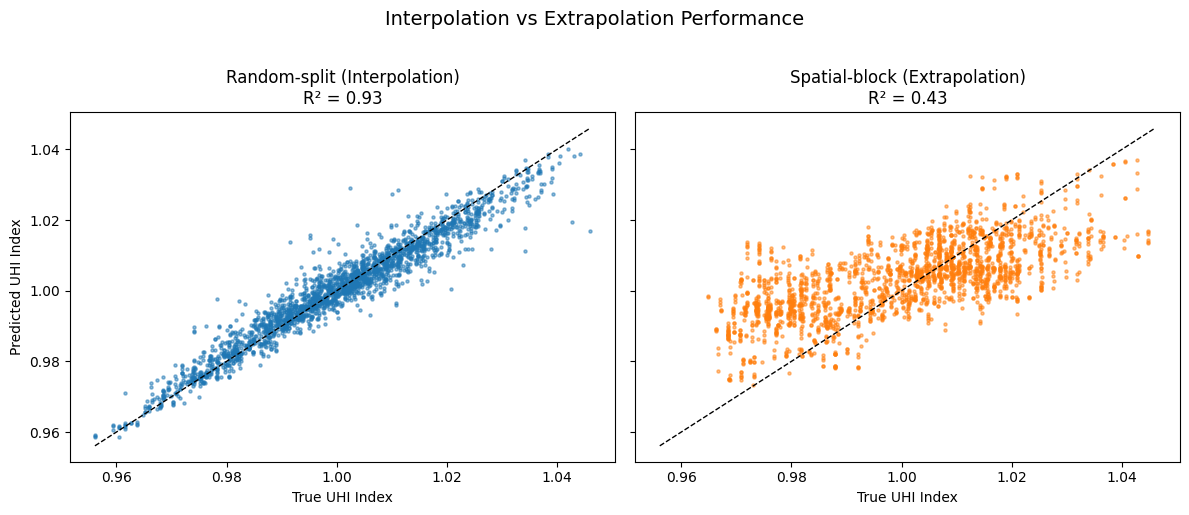

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.metrics import r2_score

X = uhi_data_cleaned[all_feature_cols]
y = uhi_data_cleaned[uhi_col]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf_rand = RandomForestRegressor(n_estimators=100, random_state=42)
rf_rand.fit(X_train, y_train)
y_pred_rand = rf_rand.predict(X_test)
r2_rand = r2_score(y_test, y_pred_rand)

tile_size = 0.01
groups = (
    (uhi_data["latitude"]  // tile_size).astype(int)*100000
  + (uhi_data["longitude"] // tile_size).astype(int)
)
gkf = GroupKFold(n_splits=5)
train_idx, test_idx = next(gkf.split(X, y, groups=groups))
X_tr_sp, X_te_sp = X.iloc[train_idx], X.iloc[test_idx]
y_tr_sp, y_te_sp = y.iloc[train_idx], y.iloc[test_idx]

rf_sp = RandomForestRegressor(n_estimators=100, random_state=42)
rf_sp.fit(X_tr_sp, y_tr_sp)
y_pred_sp = rf_sp.predict(X_te_sp)
r2_sp = r2_score(y_te_sp, y_pred_sp)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

ax0.scatter(y_test, y_pred_rand, s=5, alpha=0.5)
ax0.plot([y.min(), y.max()], [y.min(), y.max()], "k--", lw=1)
ax0.set_title(f"Random‐split (Interpolation)\nR² = {r2_rand:.2f}")
ax0.set_xlabel("True UHI Index")
ax0.set_ylabel("Predicted UHI Index")

ax1.scatter(y_te_sp, y_pred_sp, s=5, alpha=0.5, color="C1")
ax1.plot([y.min(), y.max()], [y.min(), y.max()], "k--", lw=1)
ax1.set_title(f"Spatial‐block (Extrapolation)\nR² = {r2_sp:.2f}")
ax1.set_xlabel("True UHI Index")

plt.suptitle("Interpolation vs Extrapolation Performance", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

### Just to show train vs val data locations

In [ ]:
pip install contextily

Loading training data from: /content/drive/MyDrive/uhi/Code/Data/output/uhi_with_satellite_rings_20250504_231001.csv
Loaded training data with shape: (11229, 86)
Loading validation data from: /content/drive/MyDrive/uhi/Code/Data/submission_template_UHI2025-v2.csv
Loaded validation data with shape: (1040, 3)
Training data coordinates: Latitude_features, Longitude_features
Validation data coordinates: Latitude, Longitude
Using 'UHI Index_features' for UHI Index values
Map visualization saved to: /content/drive/MyDrive/uhi/Code/Data/output/uhi_map_visualization_20250505_024527.png


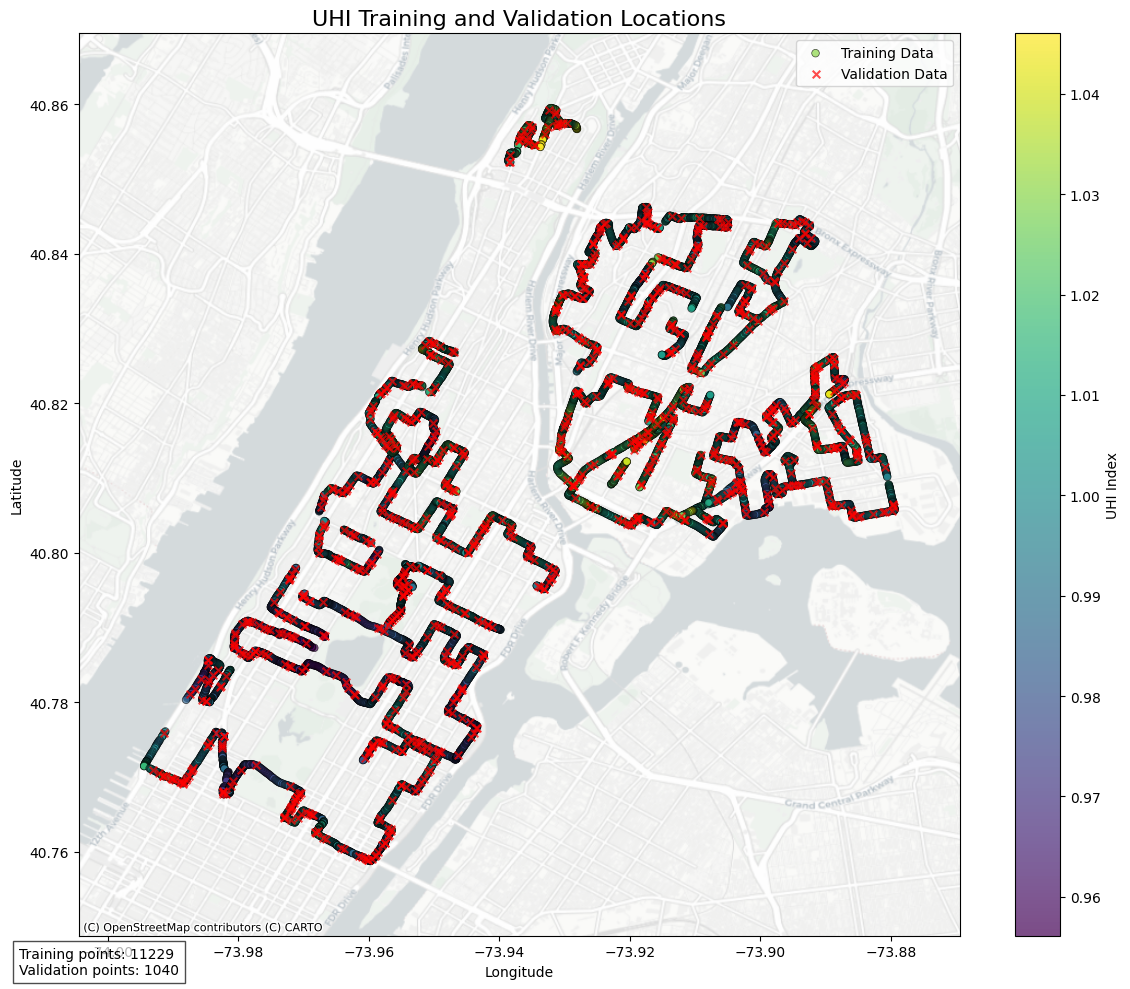

Zoomed map visualization saved to: /content/drive/MyDrive/uhi/Code/Data/output/uhi_map_visualization_zoomed_20250505_024527.png


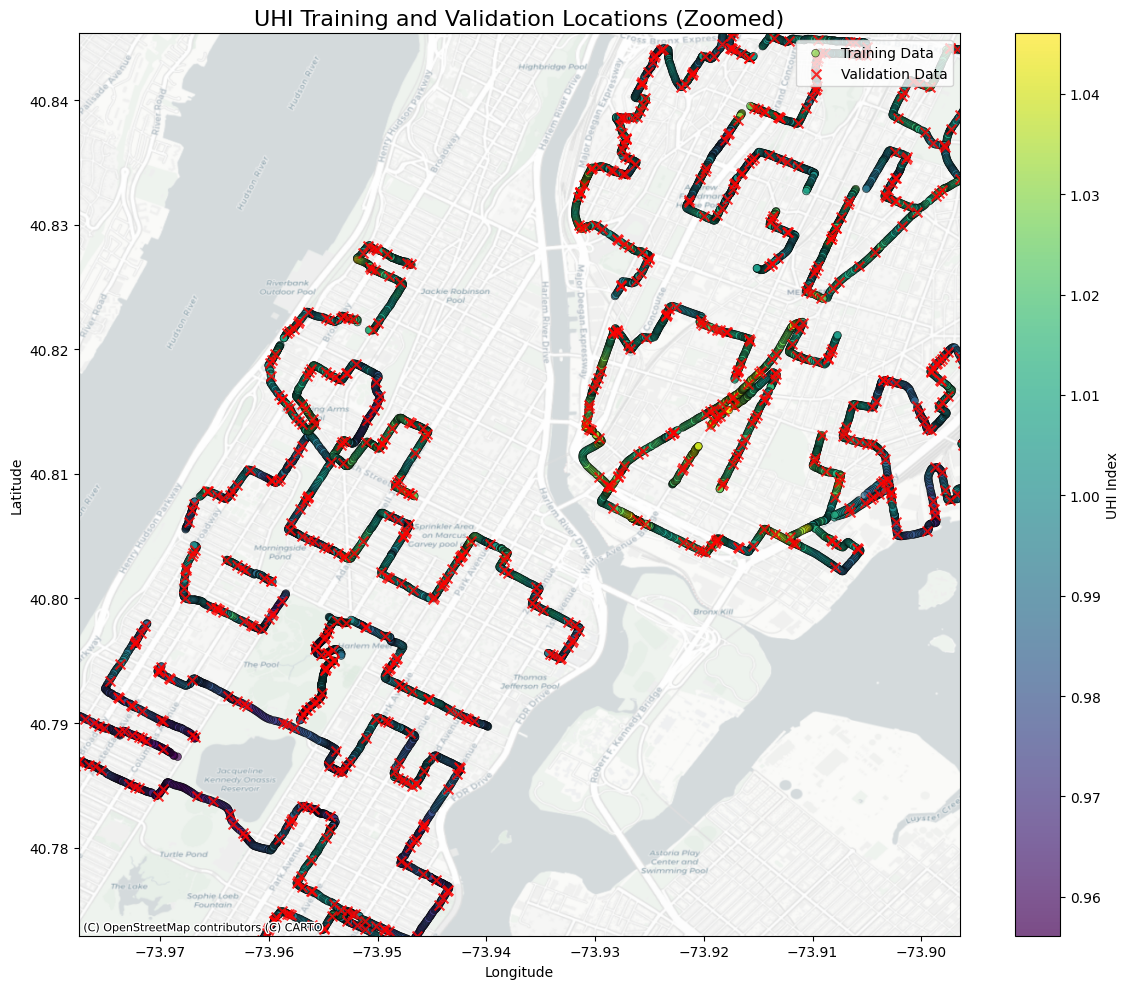


Map visualizations complete!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import contextily as ctx
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import os
from datetime import datetime

training_data_path = '/content/drive/MyDrive/uhi/Code/Data/output/uhi_with_satellite_rings_20250504_231001.csv'
validation_data_path = '/content/drive/MyDrive/uhi/Code/Data/submission_template_UHI2025-v2.csv'
output_dir = '/content/drive/MyDrive/uhi/Code/Data/output'
os.makedirs(output_dir, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

print(f"Loading training data from: {training_data_path}")
training_df = pd.read_csv(training_data_path)
print(f"Loaded training data with shape: {training_df.shape}")

print(f"Loading validation data from: {validation_data_path}")
validation_df = pd.read_csv(validation_data_path)
print(f"Loaded validation data with shape: {validation_df.shape}")

def find_lat_lon_columns(df):
    lat_cols = [col for col in df.columns if 'latitude' in col.lower()]
    lon_cols = [col for col in df.columns if 'longitude' in col.lower()]

    lat_col = 'Latitude' if 'Latitude' in lat_cols else lat_cols[0] if lat_cols else None
    lon_col = 'Longitude' if 'Longitude' in lon_cols else lon_cols[0] if lon_cols else None

    return lat_col, lon_col

train_lat_col, train_lon_col = find_lat_lon_columns(training_df)
val_lat_col, val_lon_col = find_lat_lon_columns(validation_df)

print(f"Training data coordinates: {train_lat_col}, {train_lon_col}")
print(f"Validation data coordinates: {val_lat_col}, {val_lon_col}")

uhi_cols = [col for col in training_df.columns if 'uhi' in col.lower() and 'index' in col.lower()]
if uhi_cols:
    uhi_col = uhi_cols[0]
    print(f"Using '{uhi_col}' for UHI Index values")
else:
    print("Warning: No UHI Index column found, using placeholder values")
    uhi_col = None

plt.figure(figsize=(12, 10))

minx = min(training_df[train_lon_col].min(), validation_df[val_lon_col].min()) - 0.01
maxx = max(training_df[train_lon_col].max(), validation_df[val_lon_col].max()) + 0.01
miny = min(training_df[train_lat_col].min(), validation_df[val_lat_col].min()) - 0.01
maxy = max(training_df[train_lat_col].max(), validation_df[val_lat_col].max()) + 0.01

if uhi_col:
    uhi_values = training_df[uhi_col]
    norm = Normalize(vmin=uhi_values.min(), vmax=uhi_values.max())
    cmap = plt.cm.viridis
    sm = ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
else:
    uhi_values = None

ax = plt.subplot(111)

if uhi_values is not None:
    scatter_train = ax.scatter(
        training_df[train_lon_col],
        training_df[train_lat_col],
        c=uhi_values,
        cmap=cmap,
        s=30,
        alpha=0.7,
        edgecolor='k',
        linewidth=0.5,
        label='Training Data'
    )
    plt.colorbar(scatter_train, ax=ax, label='UHI Index')
else:
    scatter_train = ax.scatter(
        training_df[train_lon_col],
        training_df[train_lat_col],
        s=30,
        alpha=0.7,
        edgecolor='k',
        linewidth=0.5,
        color='blue',
        label='Training Data'
    )

scatter_val = ax.scatter(
    validation_df[val_lon_col],
    validation_df[val_lat_col],
    s=30,
    alpha=0.7,
    marker='x',
    color='red',
    label='Validation Data'
)

ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

ctx.add_basemap(
    ax,
    crs='EPSG:4326',
    source=ctx.providers.CartoDB.Positron
)

plt.title('UHI Training and Validation Locations', fontsize=16)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(loc='upper right')

plt.figtext(
    0.02, 0.02,
    f"Training points: {len(training_df)}\nValidation points: {len(validation_df)}",
    fontsize=10,
    bbox=dict(facecolor='white', alpha=0.7)
)

output_path = f"{output_dir}/uhi_map_visualization_{timestamp}.png"
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"Map visualization saved to: {output_path}")

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 10))
ax = plt.subplot(111)

if uhi_values is not None:
    scatter_train = ax.scatter(
        training_df[train_lon_col],
        training_df[train_lat_col],
        c=uhi_values,
        cmap=cmap,
        s=30,
        alpha=0.7,
        edgecolor='k',
        linewidth=0.5,
        label='Training Data'
    )
    plt.colorbar(scatter_train, ax=ax, label='UHI Index')
else:
    scatter_train = ax.scatter(
        training_df[train_lon_col],
        training_df[train_lat_col],
        s=30,
        alpha=0.7,
        edgecolor='k',
        linewidth=0.5,
        color='blue',
        label='Training Data'
    )

scatter_val = ax.scatter(
    validation_df[val_lon_col],
    validation_df[val_lat_col],
    s=50,
    alpha=0.8,
    marker='x',
    color='red',
    label='Validation Data'
)

center_lon = (minx + maxx) / 2
center_lat = (miny + maxy) / 2
width = (maxx - minx) * 0.6
height = (maxy - miny) * 0.6

ax.set_xlim(center_lon - width/2, center_lon + width/2)
ax.set_ylim(center_lat - height/2, center_lat + height/2)

try:
    ctx.add_basemap(
        ax,
        crs='EPSG:4326',
        source=ctx.providers.CartoDB.Positron
    )
except Exception as e:
    print(f"Couldn't add basemap: {e}")
    ax.grid(True, linestyle='--', alpha=0.7)

plt.title('UHI Training and Validation Locations (Zoomed)', fontsize=16)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(loc='upper right')

zoomed_output_path = f"{output_dir}/uhi_map_visualization_zoomed_{timestamp}.png"
plt.savefig(zoomed_output_path, dpi=300, bbox_inches='tight')
print(f"Zoomed map visualization saved to: {zoomed_output_path}")

plt.tight_layout()
plt.show()

print("\nMap visualizations complete!")

# Part 3. Baysian Models

## Bayesian Model Imports

In [ ]:
X_train = X3_train
X_test = X3_test
y_train = y3_train
y_test = y3_test

## Deeper Standard Model

In [ ]:
from tensorflow.keras.layers import Input

In [ ]:
os.makedirs(f"{DATA_PATH}/Model_Stats", exist_ok=True)

model_standard = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.1),
    Dense(64, activation='relu'),
    Dropout(0.1),
    Dense(64, activation='relu'),
    Dropout(0.1),
    Dense(1, activation='linear'),
])
model_standard.compile(optimizer=Adam(learning_rate=0.001), loss="MSE")

log_file = f"{DATA_PATH}/Model_Stats/standard_training_{timestamp}.log"
log = CSVLogger(log_file, append=True)
history_standard = model_standard.fit(
    X_train, y_train,
    epochs=100,
    validation_split=0.1,
    callbacks=[log],
    verbose=1
)

mse_standard, r2_standard = test_model(model_standard, X_test, y_test)

log_df = pd.read_csv(log_file)
plt.figure(figsize=(10, 6))
plt.plot(log_df["loss"], label="Training Loss")
plt.plot(log_df["val_loss"], label="Validation Loss")
plt.legend(loc="upper right")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Standard Model Training History")
plt.savefig(f"{DATA_PATH}/Model_Stats/standard_training_history_{timestamp}.png")
plt.show()

Epoch 1/100
253/253 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 57894236160.0000 - val_loss: 48327880704.0000
Epoch 2/100
253/253 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 28801413120.0000 - val_loss: 1105116544.0000
Epoch 3/100
253/253 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 7462433792.0000 - val_loss: 270014304.0000
Epoch 4/100
253/253 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2596640512.0000 - val_loss: 4366921728.0000
Epoch 5/100
253/253 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5112948224.0000 - val_loss: 122995896.0000
Epoch 6/100
253/253 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1038372608.0000 - val_loss: 44275092.0000
Epoch 7/100
253/253 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1362476672.0000 - val_loss: 55084028.0000
Epoch 8/100
253/253 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 623444480.0000 - val_loss: 18525390.0000
Epoch 9/100
253/253 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 205131376.0000 - val_loss: 9568223.0000
Epoch 10/100
253/253 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 442

AttributeError: 'Series' object has no attribute 'flatten'

## Simple Bayesian Neural Network

In [ ]:
def prior(kernel_size, bias_size=0, dtype=None):
    n = kernel_size + bias_size
    return lambda t: tfd.Independent(
        tfd.Normal(loc=tf.zeros(n, dtype=dtype), scale=tf.ones(n, dtype=dtype)),
        reinterpreted_batch_ndims=1
    )

def posterior(kernel_size, bias_size=0, dtype=None):
    n = kernel_size + bias_size
    return lambda t: tfd.Independent(
        tfd.Normal(
            loc=tf.Variable(tf.random.normal([n], dtype=dtype)),
            scale=tf.nn.softplus(tf.Variable(tf.random.normal([n], dtype=dtype)))
        ),
        reinterpreted_batch_ndims=1
    )

inputs = Input(shape=(X_train.shape[1],))
x = tfpl.DenseVariational(
    units=16,
    make_prior_fn=prior,
    make_posterior_fn=posterior,
    kl_weight=1/X_train.shape[0],
    activation='sigmoid'
)(inputs)
outputs = Dense(1, activation='linear')(x)

model_bnn = Model(inputs=inputs, outputs=outputs)
model_bnn.compile(optimizer=Adam(0.001), loss="mse")

AttributeError: 'tuple' object has no attribute 'rank'

## Bayesian Regression Model with Uncertainty

In [ ]:
def prior_fn(kernel_size, bias_size=0, dtype=None):
    def prior_fn(shape):
        return tfd.Normal(loc=tf.zeros(shape, dtype=dtype), scale=1.0)
    return prior_fn

def posterior_fn(kernel_size, bias_size=0, dtype=None):
    def posterior_fn(shape):
        return tfd.Normal(
            loc=tf.Variable(lambda: tf.random.normal(shape, stddev=0.1, dtype=dtype)),
            scale=tf.math.softplus(tf.Variable(lambda: tf.random.normal(shape, stddev=0.1, dtype=dtype)))
        )
    return posterior_fn

def neg_log_likelihood(y_true, y_pred_dist):
    return -tf.reduce_mean(y_pred_dist.log_prob(y_true))

inputs = Input(shape=(X_train.shape[1],))

x = tfpl.DenseVariational(
    units=16,
    make_prior_fn=prior_fn,
    make_posterior_fn=posterior_fn,
    kl_weight=1 / X_train.shape[0],
    activation='tanh'
)(inputs)

outputs = tfpl.DenseVariational(
    units=1,
    make_prior_fn=prior_fn,
    make_posterior_fn=posterior_fn,
    kl_weight=1 / X_train.shape[0]
)(x)

distribution_output = tfpl.DistributionLambda(
    lambda t: tfd.Normal(loc=t, scale=1.0)
)(outputs)

model_bayes_reg = Model(inputs=inputs, outputs=distribution_output)

model_bayes_reg.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss=neg_log_likelihood
)

log_file = f"{DATA_PATH}/Model_Stats/bayes_reg_training_{timestamp}.log"
log = CSVLogger(log_file, append=True)
history_bayes_reg = model_bayes_reg.fit(
    X_train, y_train,
    epochs=20,
    validation_split=0.1,
    callbacks=[log],
    verbose=1
)

print("Bayesian Regression Model Evaluation:")
mse_bayes_reg, r2_bayes_reg = test_model(model_bayes_reg, X_test, y_test)

log_df = pd.read_csv(log_file)
plt.figure(figsize=(10, 6))
plt.plot(log_df["loss"], label="Training Loss")
plt.plot(log_df["val_loss"], label="Validation Loss")
plt.legend(loc="upper right")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Bayesian Regression Model Training History")
plt.savefig(f"{DATA_PATH}/Model_Stats/bayes_reg_training_history_{timestamp}.png")
plt.show()

AttributeError: 'tuple' object has no attribute 'rank'

## Uncertainty Visualization

In [ ]:

def predict_with_uncertainty(model, X, num_samples=100):
    predictions = []

    for _ in range(num_samples):
        pred_dist = model(X)
        sample = pred_dist.sample().numpy()
        predictions.append(sample)

    predictions = np.stack(predictions, axis=0)
    means = np.mean(predictions, axis=0)
    stds = np.std(predictions, axis=0)

    return means, stds

print("Generating predictions with uncertainty...")
means, stds = predict_with_uncertainty(model_bayes_reg, X_test, num_samples=100)

plt.figure(figsize=(12, 6))
subset_size = min(50, len(X_test))
indices = np.random.choice(len(X_test), subset_size, replace=False)
sorted_indices = indices[np.argsort(y_test[indices].flatten())]

y_subset = y_test[sorted_indices].flatten()
means_subset = means[sorted_indices].flatten()
stds_subset = stds[sorted_indices].flatten()

plt.errorbar(
    np.arange(subset_size),
    means_subset,
    yerr=2*stds_subset,
    fmt='o',
    ecolor='lightgray',
    capsize=3,
    label='Predicted with 95% CI'
)
plt.plot(np.arange(subset_size), y_subset, 'ro', label='True Values')
plt.xlabel('Sample Index (sorted by true value)')
plt.ylabel('UHI Index (standardized)')
plt.title('Bayesian Model Predictions with Uncertainty')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(f"{DATA_PATH}/Model_Stats/uncertainty_visualization_{timestamp}.png")
plt.show()


Generating predictions with uncertainty...


NameError: name 'model_bayes_reg' is not defined

# Data Loading

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization, Add, Lambda
from tensorflow.keras.models import Model, Sequential, load_model, save_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import tensorflow_probability as tfp
from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, Matern
from sklearn.neighbors import NearestNeighbors
from datetime import datetime
import os
import json
import joblib
import traceback
from google.colab import drive

drive.mount('/content/drive')

tfd = tfp.distributions
tfpl = tfp.layers

np.random.seed(42)
tf.random.set_seed(42)

BASE_DIR = '/content/drive/MyDrive/uhi/Code/Data'
OUTPUT_DIR = f'{BASE_DIR}/output'
MODELS_DIR = f'{BASE_DIR}/models'

for directory in [OUTPUT_DIR, MODELS_DIR]:
    os.makedirs(directory, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_DIR = f"{MODELS_DIR}/run_{timestamp}"
os.makedirs(RUN_DIR, exist_ok=True)

latest_merged_file = '/content/drive/MyDrive/uhi/Code/Data/output/uhi_with_satellite_rings_cleaned_20250505_002612.csv'
print(f"Loading dataset: {latest_merged_file}")
uhi_data = pd.read_csv(latest_merged_file)
print(f"Loaded dataset with shape: {uhi_data.shape}")

uhi_columns = [col for col in uhi_data.columns if 'uhi' in col.lower() and 'index' in col.lower()]
uhi_col = uhi_columns[0]


satellite_band_cols = [col for col in uhi_data.columns if col.startswith('B') and len(col) <= 4 and not '_ring' in col]
satellite_index_cols = [col for col in uhi_data.columns if col.lower() in ['ndvi', 'ndbi', 'ndwi'] or
                        (any(idx in col.lower() for idx in ['ndvi', 'ndbi', 'ndwi']) and not '_ring' in col)]
satellite_ring_cols = [col for col in uhi_data.columns if '_ring' in col]
building_cols = [col for col in uhi_data.columns if 'building' in col.lower()]
tree_cols = [col for col in uhi_data.columns if 'tree' in col.lower()]

exclude_cols = ['geometry', 'join_timestamp', 'datetime'] + \
              [col for col in uhi_data.columns if 'latitude' in col.lower() or 'longitude' in col.lower()]
exclude_cols.extend([col for col in uhi_data.columns if 'datetime' in col.lower()])
uhi_cols = [col for col in uhi_data.columns if 'uhi' in col.lower() and 'index' in col.lower()]
if len(uhi_cols) > 1:
    exclude_cols.extend([col for col in uhi_cols if col != uhi_col])

all_feature_cols = satellite_band_cols + satellite_index_cols + satellite_ring_cols + building_cols + tree_cols
all_feature_cols = [col for col in all_feature_cols if col in uhi_data.columns and col not in exclude_cols]

uhi_data_cleaned = uhi_data.copy()
for col in all_feature_cols + [uhi_col]:
    if col in uhi_data_cleaned.columns:
        uhi_data_cleaned[col] = pd.to_numeric(uhi_data_cleaned[col], errors='coerce')

        null_count = uhi_data_cleaned[col].isnull().sum()
        if null_count > 0:
            if 'distance' in col.lower():
                max_val = uhi_data_cleaned[col].replace([np.inf, -np.inf], np.nan).max()
                fill_value = max_val * 2 if not pd.isna(max_val) else 10000.0
                uhi_data_cleaned[col] = uhi_data_cleaned[col].replace([np.inf, -np.inf], fill_value)
                uhi_data_cleaned[col] = uhi_data_cleaned[col].fillna(fill_value)
            elif any(term in col.lower() for term in ['count', 'area', 'impact']):
                uhi_data_cleaned[col] = uhi_data_cleaned[col].fillna(0)
            else:
                col_mean = uhi_data_cleaned[col].replace([np.inf, -np.inf], np.nan).mean()
                uhi_data_cleaned[col] = uhi_data_cleaned[col].replace([np.inf, -np.inf], col_mean)
                uhi_data_cleaned[col] = uhi_data_cleaned[col].fillna(col_mean)

        inf_count = np.sum(np.isinf(uhi_data_cleaned[col].values))
        if inf_count > 0:
            max_val = uhi_data_cleaned[col].replace([np.inf, -np.inf], np.nan).max()
            fill_value = max_val * 2 if not pd.isna(max_val) else 10000.0
            uhi_data_cleaned[col] = uhi_data_cleaned[col].replace([np.inf, -np.inf], fill_value)

X_std = uhi_data_cleaned[all_feature_cols].copy()
for col in all_feature_cols:
    col_std = uhi_data_cleaned[col].std()
    if col_std > 0:
        col_mean = uhi_data_cleaned[col].mean()
        X_std[col] = (uhi_data_cleaned[col] - col_mean) / col_std

coords = np.column_stack((uhi_data['latitude'], uhi_data['longitude']))

X = X_std
y = uhi_data_cleaned[uhi_col]

print(f"\nFeature count: {len(all_feature_cols)}")
print(f"Data ready for modeling with {X.shape[0]} samples and {X.shape[1]} features")

print("\nTop 10 Important Features from Previous Analysis:")
important_features = [
    'ndbi_ring1_mean_ring', 'closest_tree_distance', 'building_impact_200-500ft',
    'tree_impact_200-500ft', 'tree_count_200-500ft', 'ndwi (pooled)',
    'building_count_200-500ft', 'B02_ring1_std_ring', 'B03_ring1_std_ring',
    'ndvi_ring1_mean_ring'
]
for i, feature in enumerate(important_features):
    if feature in X.columns:
        print(f"{i+1}. {feature}")
    else:
        print(f"{i+1}. {feature} - NOT FOUND IN DATASET")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading dataset: /content/drive/MyDrive/uhi/Code/Data/output/uhi_with_satellite_rings_cleaned_20250505_002612.csv
Loaded dataset with shape: (11229, 85)
Using 'UHI Index_features' as the target variable

Feature count: 60
Data ready for modeling with 11229 samples and 60 features

Top 10 Important Features from Previous Analysis:
1. ndbi_ring1_mean_ring
2. closest_tree_distance
3. building_impact_200-500ft
4. tree_impact_200-500ft
5. tree_count_200-500ft
6. ndwi (pooled)
7. building_count_200-500ft
8. B02_ring1_std_ring
9. B03_ring1_std_ring
10. ndvi_ring1_mean_ring


## Check for NaNs

In [ ]:
nan_cols = X_std.columns[X_std.isna().any()].tolist()
for col in nan_cols:
    median_val = X_std[col].median()
    X_std[col] = X_std[col].fillna(median_val)

if X_std.isna().any().any():
    X_std = X_std.dropna()
    y = y.loc[X_std.index]

print(f"After handling NaNs: {X_std.shape[0]} samples, {X_std.shape[1]} features")

Checking for any remaining NaN values...


# Some advanced stuff

In [ ]:
def build_standard_nn(input_shape):
    model = Sequential([
        Dense(64, kernel_initializer='he_normal', input_shape=(input_shape,)),
        BatchNormalization(),
        Dense(64, activation='relu'),
        Dropout(0.2),

        Dense(32, kernel_initializer='he_normal'),
        BatchNormalization(),
        Dense(32, activation='relu'),
        Dropout(0.1),

        Dense(16, kernel_initializer='he_normal'),
        BatchNormalization(),
        Dense(16, activation='relu'),
        Dropout(0.1),

        Dense(1, activation='linear')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )

    return model

def build_bayesian_nn(input_shape):
    def prior_fn(kernel_size, bias_size=0, dtype=None):
        n = kernel_size + bias_size
        return tfd.Independent(
            tfd.Normal(loc=tf.zeros(n, dtype=dtype), scale=tf.ones(n, dtype=dtype)),
            reinterpreted_batch_ndims=1
        )

    def posterior_fn(kernel_size, bias_size=0, dtype=None):
        n = kernel_size + bias_size
        return tfd.Independent(
            tfd.Normal(
                loc=tf.Variable(tf.random.normal([n], stddev=0.1, dtype=dtype)),
                scale=tf.nn.softplus(tf.Variable(tf.random.normal([n], stddev=0.1, dtype=dtype)))
            ),
            reinterpreted_batch_ndims=1
        )

    def neg_log_likelihood(y, dist):
        return -dist.log_prob(y)

    inputs = Input(shape=(input_shape,))

    x = tfpl.DenseVariational(
        units=64,
        make_prior_fn=prior_fn,
        make_posterior_fn=posterior_fn,
        kl_weight=1/1000,
        activation='relu'
    )(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)

    x = tfpl.DenseVariational(
        units=32,
        make_prior_fn=prior_fn,
        make_posterior_fn=posterior_fn,
        kl_weight=1/1000,
        activation='relu'
    )(x)
    x = BatchNormalization()(x)
    x = Dropout(0.1)(x)

    params = tfpl.DenseVariational(
        units=2,
        make_prior_fn=prior_fn,
        make_posterior_fn=posterior_fn,
        kl_weight=1/1000
    )(x)

    distribution = tfpl.DistributionLambda(
        lambda t: tfd.Normal(
            loc=t[..., :1],
            scale=tf.exp(0.5 * t[..., 1:])
        )
    )(params)

    model = Model(inputs=inputs, outputs=distribution)

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss=neg_log_likelihood
    )

    return model

def build_mc_dropout_nn(input_shape, dropout_rate=0.2):
    model = Sequential([
        Dense(64, kernel_initializer='he_normal', input_shape=(input_shape,)),
        BatchNormalization(),
        Dense(64, activation='relu'),
        Dropout(dropout_rate, trainable=False),

        Dense(32, kernel_initializer='he_normal'),
        BatchNormalization(),
        Dense(32, activation='relu'),
        Dropout(dropout_rate, trainable=False),

        Dense(16, kernel_initializer='he_normal'),
        BatchNormalization(),
        Dense(16, activation='relu'),
        Dropout(dropout_rate, trainable=False),

        Dense(1, activation='linear')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )

    return model

def predict_with_mc_dropout(model, X_test, n_samples=100):
    predictions = []
    X_test_tensor = tf.convert_to_tensor(X_test, dtype=tf.float32)

    for _ in range(n_samples):
        preds = model(X_test_tensor, training=True)
        predictions.append(preds.numpy())

    predictions = np.stack(predictions, axis=0)
    mean_prediction = np.mean(predictions, axis=0)
    std_prediction = np.std(predictions, axis=0)

    return mean_prediction, std_prediction

def build_quantile_rf(n_estimators=200, random_state=42):
    rf = RandomForestRegressor(
        n_estimators=n_estimators,
        random_state=random_state,
        bootstrap=True,
        oob_score=True,
        n_jobs=-1
    )

    return rf

def predict_with_quantile_rf(rf_model, X_test, quantiles=[0.025, 0.5, 0.975]):
    predictions = []

    for tree in rf_model.estimators_:
        pred = tree.predict(X_test)
        predictions.append(pred)

    predictions = np.stack(predictions, axis=0)

    quantile_preds = {}
    for q in quantiles:
        q_pred = np.quantile(predictions, q, axis=0)
        quantile_preds[q] = q_pred

    mean_prediction = np.mean(predictions, axis=0)

    return mean_prediction, quantile_preds

Model definitions and training function ready.


In [ ]:
def train_single_model(model_name, split_type='random', fold_idx=0):
    """Train a single model with error handling"""
    print(f"\n{'=' * 50}")
    print(f"Training {model_name} on {split_type} split (fold {fold_idx})...")
    print(f"{'=' * 50}")

    if split_type == 'random':
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    else:
        tile_size = 0.01
        groups = ((coords[:, 0] // tile_size).astype(int)*100000 +
                (coords[:, 1] // tile_size).astype(int))

        gkf = GroupKFold(n_splits=5)
        splits = list(gkf.split(X, y, groups=groups))
        train_idx, test_idx = splits[fold_idx-1]

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    if isinstance(X_train, pd.DataFrame) and (X_train.isna().any().any() or X_test.isna().any().any()):
        for col in X_train.columns:
            if pd.api.types.is_numeric_dtype(X_train[col]):
                col_mean = X_train[col].mean()
                X_train[col] = X_train[col].fillna(col_mean)
                X_test[col] = X_test[col].fillna(col_mean)

        if X_train.isna().any().any() or X_test.isna().any().any():
            X_train = X_train.dropna()
            X_test = X_test.dropna()
            y_train = y_train.loc[X_train.index]
            y_test = y_test.loc[X_test.index]

    X_train_np = X_train.values
    X_test_np = X_test.values

    if model_name == "Neural Network":
        model = build_standard_nn(X.shape[1])
    elif model_name == "Bayesian NN":
        model = build_bayesian_nn(X.shape[1])
    elif model_name == "VAE":
        model, _, _ = build_vae(X.shape[1])
    elif model_name == "GraphSAGE":
        model = build_graphsage(X.shape[1])
    elif model_name == "Linear Regression":
        model = LinearRegression()
    elif model_name == "Random Forest":
        model = RandomForestRegressor(n_estimators=200, random_state=42)
    elif model_name == "Gaussian Process":
        kernel = Matern(length_scale=1.0, nu=1.5) + WhiteKernel(noise_level=1.0)
        model = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5, random_state=42)
    elif model_name == "Pretrained BNN":
        pretrained_model_path = "/content/drive/MyDrive/uhi/Code/Data/models/run_20250506_054655/Neural_Network/random_0.weights.h5"
        if not os.path.exists(pretrained_model_path):
            raise FileNotFoundError(f"Pretrained model not found")
        model = build_pretrained_bnn(X.shape[1], pretrained_model_path)

    else:
        raise ValueError(f"Unknown model name: {model_name}")

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=0.00001),
        ModelCheckpoint(
            filepath=f"{RUN_DIR}/{model_name.replace(' ', '_')}_{split_type}_{fold_idx}_checkpoint.keras",
            monitor='val_loss',
            save_best_only=True,
            verbose=1
        )
    ]
    if model_name in ['Linear Regression', 'Random Forest', 'Gaussian Process'] and model_name != "Quantile RF":
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        if model_name == 'Random Forest':
            feature_importance = pd.DataFrame({
                'Feature': X.columns,
                'Importance': model.feature_importances_
            }).sort_values('Importance', ascending=False)
            importance_folder = f"{OUTPUT_DIR}/feature_importance"
            os.makedirs(importance_folder, exist_ok=True)
            importance_path = f"{importance_folder}/{model_name.replace(' ', '_')}_{split_type}_{fold_idx}_{timestamp}.csv"
            feature_importance.to_csv(importance_path, index=False)
            print(f"Feature importance saved to: {importance_path}")
            plt.figure(figsize=(15, 10))
            top_features = feature_importance.head(30)
            plt.barh(top_features['Feature'], top_features['Importance'])
            plt.xlabel('Importance')
            plt.ylabel('Feature')
            plt.title(f'Top 30 Features by {model_name} Importance')
            plt.tight_layout()
            plt_path = f"{importance_folder}/{model_name.replace(' ', '_')}_{split_type}_{fold_idx}_{timestamp}.png"
            plt.savefig(plt_path, dpi=300, bbox_inches='tight')
            plt.close()

    elif model_name == 'Neural Network':
        history = model.fit(
            X_train_np, y_train,
            epochs=200,
            batch_size=32,
            validation_split=0.2,
            callbacks=callbacks,
            verbose=1
        )
        y_pred = model.predict(X_test_np)

    elif model_name == 'Bayesian NN':
        history = model.fit(
            X_train_np, y_train,
            epochs=200,
            batch_size=32,
            validation_split=0.2,
            callbacks=callbacks,
            verbose=1
        )
        pred_dist = model.predict(X_test_np)
        y_pred = pred_dist.mean().numpy()

    elif model_name == "MC Dropout":
        history = model.fit(
            X_train_np, y_train,
            epochs=200,
            batch_size=32,
            validation_split=0.2,
            callbacks=callbacks,
            verbose=1
        )
        y_pred, y_std = predict_with_mc_dropout(model, X_test_np)

    elif model_name == "Deep Ensemble":
        X_train_split, X_valid, y_train_split, y_valid = train_test_split(
            X_train_np, y_train, test_size=0.2, random_state=42
        )
        histories = train_deep_ensemble(
            model, X_train_split, y_train_split, X_valid, y_valid,
            epochs=200, batch_size=32, callbacks=callbacks
        )
        y_pred, y_std = predict_with_ensemble(model, X_test_np)
    elif model_name == "Quantile RF":
        model.fit(X_train, y_train)
        y_pred, quantiles = predict_with_quantile_rf(model, X_test)
        y_std = (quantiles[0.975] - quantiles[0.025]) / 2
    elif model_name == "MC Dropout Improved":
        history = model.fit(
            X_train_np, y_train,
            epochs=100,
            batch_size=32,
            validation_split=0.1,
            callbacks=callbacks,
            verbose=1
        )
        y_pred, total_variance = predict_with_mc_dropout_improved(model, X_test_np)
        y_std = np.sqrt(total_variance)

    elif model_name == "Pretrained BNN":
        history = model.fit(
            X_train_np, y_train,
            epochs=20,
            batch_size=32,
            validation_split=0.1,
            callbacks=callbacks,
            verbose=1
        )
        y_pred = model.predict(X_test_np)
        samples = []
        for _ in range(100):
            samples.append(model.predict(X_test_np))
        samples = np.stack(samples, axis=0)
        y_std = np.std(samples, axis=0)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mse)

    if model_name in ["MC Dropout", "Deep Ensemble", "Quantile RF", "Bayesian NN", "Gaussian Process"]:
        if model_name == "Quantile RF":
            lower_bound = quantiles[0.025]
            upper_bound = quantiles[0.975]
        elif model_name == "Bayesian NN":
            pred_dist = model.predict(X_test_np)
            lower_bound = pred_dist.mean().numpy() - 2 * pred_dist.stddev().numpy()
            upper_bound = pred_dist.mean().numpy() + 2 * pred_dist.stddev().numpy()
        elif model_name == "Gaussian Process":
            y_pred, y_std = model.predict(X_test, return_std=True)
            lower_bound = y_pred - 2 * y_std
            upper_bound = y_pred + 2 * y_std
        else:
            lower_bound = y_pred - 2 * y_std
            upper_bound = y_pred + 2 * y_std

        plt.figure(figsize=(10, 6))
        plt.scatter(y_test, y_pred, alpha=0.5)

        idx = np.random.choice(range(len(y_test)), size=min(100, len(y_test)), replace=False)
        plt.errorbar(y_test[idx], y_pred[idx], yerr=2*y_std[idx], fmt='o', alpha=0.4, color='red', label='95% CI')

        plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')
        plt.xlabel('Actual UHI Index')
        plt.ylabel('Predicted UHI Index')
        plt.title(f"{model_name} - {split_type.capitalize()} Split (Fold {fold_idx})\nWith Uncertainty Estimates")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.savefig(f"{OUTPUT_DIR}/{model_name.replace(' ', '_')}_{split_type}_{fold_idx}_with_uncertainty_{timestamp}.png",
                dpi=300, bbox_inches='tight')
        plt.close()


    # Save model
    model_folder = f"{RUN_DIR}/{model_name.replace(' ', '_')}"
    os.makedirs(model_folder, exist_ok=True)

    if model_name == "Deep Ensemble":
        ensemble_folder = f"{model_folder}/{split_type}_{fold_idx}"
        os.makedirs(ensemble_folder, exist_ok=True)

        for i, sub_model in enumerate(model):
            sub_model_path = f"{ensemble_folder}/model_{i}"
            try:
                sub_model.save(sub_model_path, save_format='tf')
            except Exception as e:
                print(f"Error saving ensemble model {i}: {str(e)}")
                weights_path = f"{sub_model_path}.weights.h5"
                sub_model.save_weights(weights_path)

        model_path = ensemble_folder

    elif isinstance(model, (LinearRegression, RandomForestRegressor, GaussianProcessRegressor)):
        model_path = f"{model_folder}/{split_type}_{fold_idx}.joblib"
        joblib.dump(model, model_path)
    else:
        model_path = f"{model_folder}/{split_type}_{fold_idx}"
        try:
            model.save(model_path, save_format='tf')
        except Exception as e:
            print(f"Error saving model: {str(e)}")
            weights_path = f"{model_path}.weights.h5"
            model.save_weights(weights_path)
            model_path = weights_path

    metrics = {'mse': float(mse), 'r2': float(r2), 'rmse': float(rmse)}
    metadata_path = f"{model_folder}/{split_type}_{fold_idx}_metadata.json"

    with open(metadata_path, 'w') as f:
        json.dump({
            'model_name': model_name,
            'split_type': split_type,
            'fold_idx': fold_idx,
            'timestamp': timestamp,
            'metrics': metrics
        }, f, indent=2)

    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, y_pred, alpha=0.5)
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')
    plt.xlabel('Actual UHI Index')
    plt.ylabel('Predicted UHI Index')
    plt.title(f"{model_name} - {split_type.capitalize()} Split (Fold {fold_idx})\nR²: {r2:.4f}, RMSE: {rmse:.4f}")
    plt.grid(True, alpha=0.3)
    plt.savefig(f"{OUTPUT_DIR}/{model_name.replace(' ', '_')}_{split_type}_{fold_idx}_{timestamp}.png",
            dpi=300, bbox_inches='tight')
    plt.close()

    print(f"\nTraining successful!")
    print(f"  R²: {r2:.4f}")
    print(f"  MSE: {mse:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  Model saved to: {model_path}")

    return model, metrics, model_path


# Basline

In [ ]:
#@title 0. Random Forest
model_name = "Random Forest"
split_type = "random"
fold_idx = 0

model, metrics, model_path = train_single_model(
    model_name=model_name,
    split_type=split_type,
    fold_idx=fold_idx
)

print(f"\n{model_name} training completed successfully!")
print(f"R²: {metrics['r2']:.4f}")
print(f"RMSE: {metrics['rmse']:.4f}")


Training Random Forest on random split (fold 0)...
Feature importance saved to: /content/drive/MyDrive/uhi/Code/Data/output/feature_importance/Random_Forest_random_0_20250506_051206.csv

Training successful!
  R²: 0.9345
  MSE: 0.0000
  RMSE: 0.0041
  Model saved to: /content/drive/MyDrive/uhi/Code/Data/models/run_20250506_051206/Random_Forest/random_0.joblib

Random Forest training completed successfully!
R²: 0.9345
RMSE: 0.0041


In [ ]:
#@title 1. Linear Regression (simple baseline)
model_name = "Linear Regression"
split_type = "random"
fold_idx = 0

model, metrics, model_path = train_single_model(
    model_name=model_name,
    split_type=split_type,
    fold_idx=fold_idx
)

print(f"\n{model_name} training completed successfully!")
print(f"R²: {metrics['r2']:.4f}")
print(f"RMSE: {metrics['rmse']:.4f}")


Training Linear Regression on random split (fold 0)...

Training successful!
  R²: 0.5054
  MSE: 0.0001
  RMSE: 0.0114
  Model saved to: /content/drive/MyDrive/uhi/Code/Data/models/run_20250506_054655/Linear_Regression/random_0.joblib

Linear Regression training completed successfully!
R²: 0.5054
RMSE: 0.0114


In [ ]:
#@title neural network
model_name = "Neural Network"
split_type = "random"
fold_idx = 0

model, metrics, model_path = train_single_model(
    model_name=model_name,
    split_type=split_type,
    fold_idx=fold_idx
)

print(f"\n{model_name} training completed successfully!")
print(f"R²: {metrics['r2']:.4f}")
print(f"RMSE: {metrics['rmse']:.4f}")


Training Neural Network on random split (fold 0)...
Epoch 1/200
224/225 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5858 - mae: 0.5097
Epoch 1: val_loss improved from inf to 0.09420, saving model to /content/drive/MyDrive/uhi/Code/Data/models/run_20250506_054655/Neural_Network_random_0_checkpoint.keras
225/225 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 0.5830 - mae: 0.5084 - val_loss: 0.0942 - val_mae: 0.2734 - learning_rate: 0.0010
Epoch 2/200
222/225 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0757 - mae: 0.2116
Epoch 2: val_loss improved from 0.09420 to 0.02715, saving model to /content/drive/MyDrive/uhi/Code/Data/models/run_20250506_054655/Neural_Network_random_0_checkpoint.keras
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0755 - mae: 0.2113 - val_loss: 0.0271 - val_mae: 0.1346 - learning_rate: 0.0010
Epoch 3/200
223/225 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0461 - mae: 0.1667
Epoch 3: val_loss improved from 0.02715 to 0.01383, saving model to /content/drive/MyDrive/uhi/

# Basic Probabilistic Models


Training Gaussian Process on random split (fold 0)...

Error training Gaussian Process: '[482, 1565, 247, 1654, 985, 1681, 2223, 1436, 1466, 1391, 817, 1658, 1558, 324, 618, 1336, 2244, 1917, 1801, 332, 2171, 307, 2231, 1361, 1244, 1706, 845, 1929, 2063, 134, 1937, 100, 2057, 1036, 841, 445, 1985, 1349, 785, 1591, 1181, 514, 548, 1993, 56, 1557, 354, 840, 1544, 1344, 629, 254, 834, 719, 798, 1503, 211, 787, 527, 1798, 1812, 2094, 1411, 925, 1761, 298, 1847, 1526, 1900, 1644, 196, 368, 2080, 1444] not in index'
Traceback (most recent call last):
  File "<ipython-input-39-6eee48be1877>", line 315, in train_single_model
    plt.errorbar(y_test[idx], y_pred[idx], yerr=2*y_std[idx], fmt='o', alpha=0.4, color='red', label='95% CI')
                 ~~~~~~^^^^^
  File "/usr/local/lib/python3.11/dist-packages/pandas/core/series.py", line 1153, in __getitem__
    return self._get_with(key)
           ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/pandas/core/series.py", li

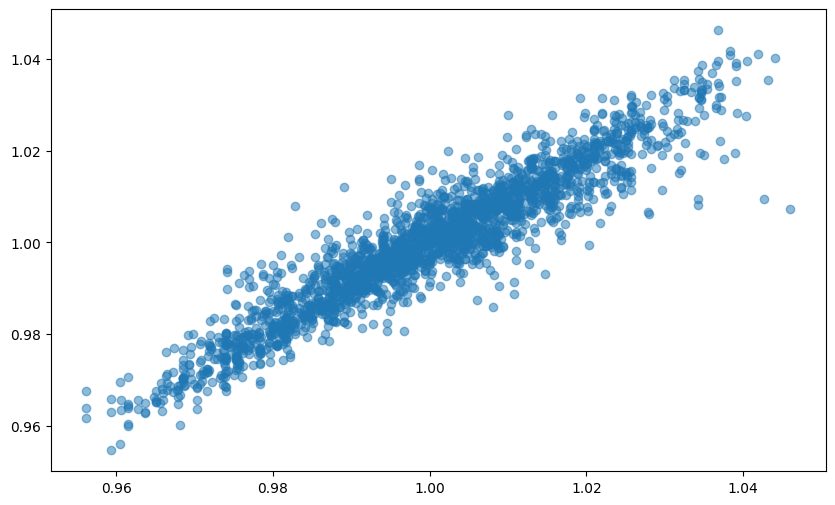

In [ ]:
model_name = "Gaussian Process"
split_type = "random"
fold_idx = 0

model, metrics, model_path = train_single_model(
    model_name=model_name,
    split_type=split_type,
    fold_idx=fold_idx
)

if metrics:
    print(f"\n{model_name} training completed successfully!")
    print(f"R²: {metrics['r2']:.4f}")
    print(f"RMSE: {metrics['rmse']:.4f}")
else:
    print(f"\n{model_name} training failed. Check error logs.")

Using pre-loaded X with shape: (11229, 60) and y with shape: (11229,)

Training Gaussian Process on random split (fold 0)...
X_train shape: (8983, 60), y_train shape: (8983,)
X_test shape: (2246, 60), y_test shape: (2246,)
Shapes after NaN handling: X_train: (8983, 60), y_train: (8983,), X_test: (2246, 60), y_test: (2246,)
Initialized Gaussian Process model.
Starting model training...
Model training completed.
Making predictions...
Predictions made.

Metrics calculated:
  R²: 0.8783
  MSE: 0.0000
  RMSE: 0.0057
Generating uncertainty plot...


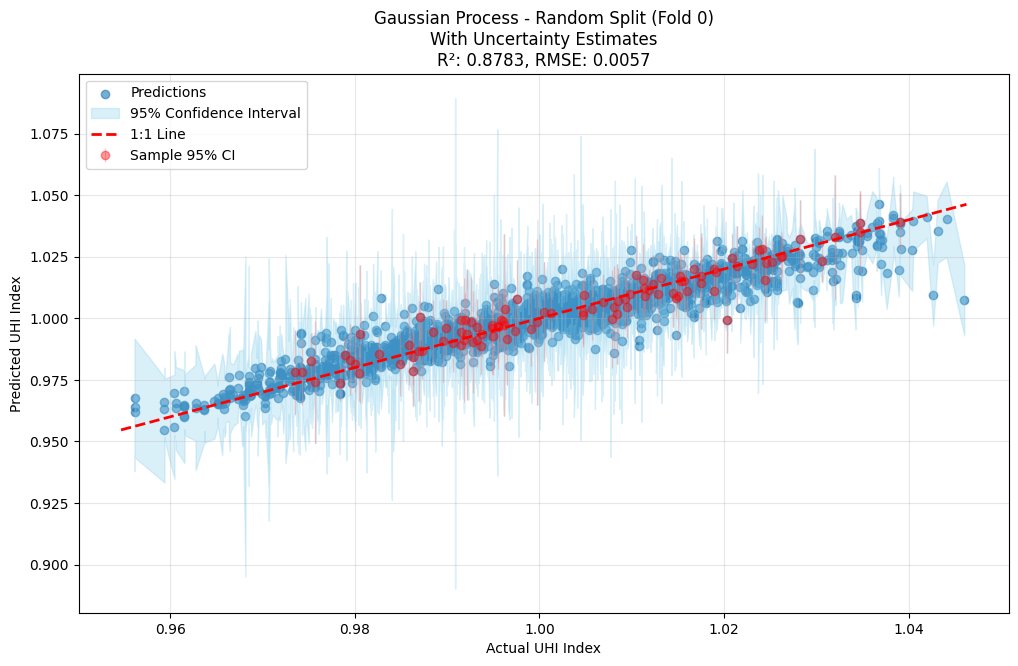

Uncertainty plot saved to: /content/drive/MyDrive/uhi/Code/Data/output/Gaussian_Process_random_0_with_uncertainty_20250506_161803.png
Model saved to: /content/drive/MyDrive/uhi/Code/Data/models/run_20250506_161803/Gaussian_Process/random_0.joblib

Error training Gaussian Process: Object of type Matern is not JSON serializable
Traceback (most recent call last):
  File "<ipython-input-7-e68c3dce0019>", line 194, in <cell line: 0>
    json.dump(metadata, f, indent=2)
  File "/usr/lib/python3.11/json/__init__.py", line 179, in dump
    for chunk in iterable:
  File "/usr/lib/python3.11/json/encoder.py", line 432, in _iterencode
    yield from _iterencode_dict(o, _current_indent_level)
  File "/usr/lib/python3.11/json/encoder.py", line 406, in _iterencode_dict
    yield from chunks
  File "/usr/lib/python3.11/json/encoder.py", line 406, in _iterencode_dict
    yield from chunks
  File "/usr/lib/python3.11/json/encoder.py", line 439, in _iterencode
    o = _default(o)
        ^^^^^^^^^^^
  F

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel
from sklearn.metrics import mean_squared_error, r2_score
import joblib
import os
import json
import traceback
from datetime import datetime

model_name = "Gaussian Process"
split_type = "random"
fold_idx = 0

else:
    print(f"Using pre-loaded X with shape: {X.shape} and y with shape: {y.shape}")

try:
    print(f"\n{'=' * 50}")
    print(f"Training {model_name} on {split_type} split (fold {fold_idx})...")
    print(f"{'=' * 50}")

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42 + fold_idx)

    print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
    print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

    if isinstance(X_train, pd.DataFrame) and (X_train.isna().any().any() or X_test.isna().any().any()):
        print("Detected NaN values in the data split, handling them...")
        for col in X_train.columns:
            if pd.api.types.is_numeric_dtype(X_train[col]):
                col_mean_train = X_train[col].mean()
                X_train[col] = X_train[col].fillna(col_mean_train)
                X_test[col] = X_test[col].fillna(col_mean_train)

        if X_train.isna().any().any() or X_test.isna().any().any():
            print("Warning: Some NaN values could not be handled by mean imputation. Using dropna as a last resort.")
            X_train_before_dropna = X_train.shape[0]
            y_train_before_dropna = y_train.shape[0]
            X_test_before_dropna = X_test.shape[0]
            y_test_before_dropna = y_test.shape[0]

            X_train = X_train.dropna()
            y_train = y_train.loc[X_train.index]
            X_test = X_test.dropna()
            y_test = y_test.loc[X_test.index]
            print(f"Rows dropped from X_train: {X_train_before_dropna - X_train.shape[0]}")
            print(f"Rows dropped from X_test: {X_test_before_dropna - X_test.shape[0]}")

    if y_train.isna().any():
        y_train = y_train.dropna()
        X_train = X_train.loc[y_train.index]
    if y_test.isna().any():
        y_test = y_test.dropna()
        X_test = X_test.loc[y_test.index]

    kernel = Matern(length_scale=1.0, nu=1.5) + WhiteKernel(noise_level=1.0)
    model = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5, random_state=42, alpha=1e-10) # Added alpha for stability
    print(f"Initialized {model_name} model.")

    print("Starting model training...")
    model.fit(X_train, y_train)
    print("Model training completed.")
    y_pred, y_std = model.predict(X_test, return_std=True)
    print("Predictions made.")

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mse)
    metrics = {'mse': float(mse), 'r2': float(r2), 'rmse': float(rmse)}
    print("\nMetrics calculated:")
    print(f"  R²: {r2:.4f}")
    print(f"  MSE: {mse:.4f}")
    print(f"  RMSE: {rmse:.4f}")

    print("Generating uncertainty plot...")
    plt.figure(figsize=(12, 7))
    plt.scatter(y_test, y_pred, alpha=0.6, label='Predictions')

    sort_idx = np.argsort(y_test.values.flatten())
    y_test_sorted = y_test.values.flatten()[sort_idx]
    y_pred_sorted = y_pred.flatten()[sort_idx]
    y_std_sorted = y_std.flatten()[sort_idx]

    lower_bound = y_pred_sorted - 2 * y_std_sorted
    upper_bound = y_pred_sorted + 2 * y_std_sorted
    plt.fill_between(y_test_sorted, lower_bound, upper_bound, color='skyblue', alpha=0.3, label='95% Confidence Interval')

    sample_size_for_error_bars = min(100, len(y_test))
    if sample_size_for_error_bars > 0:
        idx = np.random.choice(range(len(y_test)), size=sample_size_for_error_bars, replace=False)
        y_test_np = y_test.values if isinstance(y_test, pd.Series) else y_test
        plt.errorbar(y_test_np[idx], y_pred[idx], yerr=2*y_std[idx], fmt='o', alpha=0.4, color='red', ecolor='lightcoral', elinewidth=1, capsize=0, label='Sample 95% CI')


    plt.plot([min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())],
             [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())], 'r--', lw=2, label='1:1 Line')
    plt.xlabel('Actual UHI Index')
    plt.ylabel('Predicted UHI Index')
    plt.title(f"{model_name} - {split_type.capitalize()} Split (Fold {fold_idx})\nWith Uncertainty Estimates\nR²: {r2:.4f}, RMSE: {rmse:.4f}")
    plt.grid(True, alpha=0.3)
    plt.legend()
    uncertainty_plot_path = f"{OUTPUT_DIR}/{model_name.replace(' ', '_')}_{split_type}_{fold_idx}_with_uncertainty_{timestamp}.png"
    plt.savefig(uncertainty_plot_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"Uncertainty plot saved to: {uncertainty_plot_path}")

    model_folder = f"{RUN_DIR}/{model_name.replace(' ', '_')}"
    os.makedirs(model_folder, exist_ok=True)
    model_path = f"{model_folder}/{split_type}_{fold_idx}.joblib"
    joblib.dump(model, model_path)
    print(f"Model saved to: {model_path}")

    metadata_path = f"{model_folder}/{split_type}_{fold_idx}_metadata.json"
    metadata = {
        'model_name': model_name,
        'split_type': split_type,
        'fold_idx': fold_idx,
        'timestamp': timestamp,
        'metrics': metrics,
        'model_path': model_path,
        'plot_path': uncertainty_plot_path,
        'X_train_shape': list(X_train.shape),
        'X_test_shape': list(X_test.shape),
        'kernel_params': model.kernel_.get_params()
    }
    with open(metadata_path, 'w') as f:
        json.dump(metadata, f, indent=2)
    print(f"Metadata saved to: {metadata_path}")

    print("Generating standard actual vs. predicted plot...")
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, y_pred, alpha=0.5)
    plt.plot([min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())],
             [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())], 'r--')
    plt.xlabel('Actual UHI Index')
    plt.ylabel('Predicted UHI Index')
    plt.title(f"{model_name} - {split_type.capitalize()} Split (Fold {fold_idx})\nR²: {r2:.4f}, RMSE: {rmse:.4f}")
    plt.grid(True, alpha=0.3)
    standard_plot_path = f"{OUTPUT_DIR}/{model_name.replace(' ', '_')}_{split_type}_{fold_idx}_actual_vs_pred_{timestamp}.png"
    plt.savefig(standard_plot_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"Standard plot saved to: {standard_plot_path}")

    print(f"\n{model_name} training completed successfully!")
    print(f"R²: {metrics['r2']:.4f}")
    print(f"RMSE: {metrics['rmse']:.4f}")
    print(f"Model saved to: {model_path}")
    final_model = model
    final_metrics = metrics
    final_model_path = model_path

except Exception as e:
    error_msg = f"Error training {model_name}: {str(e)}"
    traceback_str = traceback.format_exc()
    print(f"\n{error_msg}")
    print(traceback_str)

    error_folder = f"{RUN_DIR}/errors"
    os.makedirs(error_folder, exist_ok=True)
    error_file_path = f"{error_folder}/{model_name.replace(' ', '_')}_{split_type}_{fold_idx}_error_{timestamp}.txt"
    with open(error_file_path, 'w') as f:
        f.write(f"Error training {model_name} on {split_type} split (fold {fold_idx}) at {timestamp}:\n")
        f.write(str(e) + "\n\n")
        f.write(traceback_str)
    print(f"Error details saved to: {error_file_path}")
    final_model, final_metrics, final_model_path = None, None, None

Using pre-loaded X with shape: (11229, 60) and y with shape: (11229,)

Training Gaussian Process-RBF on random split (fold 0)...
X_train shape: (8983, 60), y_train shape: (8983,)
X_test shape: (2246, 60), y_test shape: (2246,)
Shapes after NaN handling: X_train: (8983, 60), y_train: (8983,), X_test: (2246, 60), y_test: (2246,)
Initialized Gaussian Process model with RBF kernel.
Starting model training...
Model training completed.
Making predictions...
Predictions made.

Metrics calculated:
  R²: 0.7222
  MSE: 0.0001
  RMSE: 0.0085
Generating uncertainty plot...


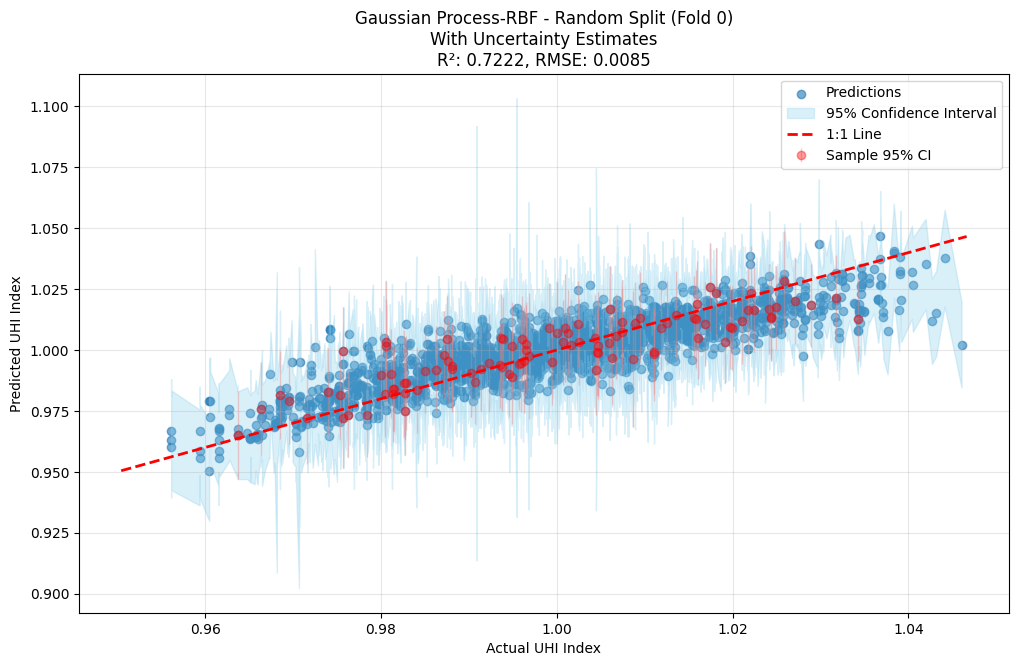

Uncertainty plot saved to: /content/drive/MyDrive/uhi/Code/Data/output/Gaussian_Process-RBF_random_0_with_uncertainty_20250506_161803.png
Model saved to: /content/drive/MyDrive/uhi/Code/Data/models/run_20250506_161803/Gaussian_Process-RBF/random_0.joblib

Error training Gaussian Process-RBF: Object of type RBF is not JSON serializable
Traceback (most recent call last):
  File "<ipython-input-8-3ad88eb56907>", line 199, in <cell line: 0>
    json.dump(metadata, f, indent=2)
  File "/usr/lib/python3.11/json/__init__.py", line 179, in dump
    for chunk in iterable:
  File "/usr/lib/python3.11/json/encoder.py", line 432, in _iterencode
    yield from _iterencode_dict(o, _current_indent_level)
  File "/usr/lib/python3.11/json/encoder.py", line 406, in _iterencode_dict
    yield from chunks
  File "/usr/lib/python3.11/json/encoder.py", line 406, in _iterencode_dict
    yield from chunks
  File "/usr/lib/python3.11/json/encoder.py", line 439, in _iterencode
    o = _default(o)
        ^^^^^^

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, WhiteKernel
from sklearn.metrics import mean_squared_error, r2_score
import joblib
import os
import json
import traceback
from datetime import datetime

model_name = "Gaussian Process-RBF"
split_type = "random"
fold_idx = 0

try:
    print(f"\n{'=' * 50}")
    print(f"Training {model_name} on {split_type} split (fold {fold_idx})...")
    print(f"{'=' * 50}")

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42 + fold_idx)

    print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
    print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

    if isinstance(X_train, pd.DataFrame) and (X_train.isna().any().any() or X_test.isna().any().any()):
        print("Detected NaN values in the data split, handling them...")
        for col in X_train.columns:
            if pd.api.types.is_numeric_dtype(X_train[col]):
                col_mean_train = X_train[col].mean()
                X_train[col] = X_train[col].fillna(col_mean_train)
                X_test[col] = X_test[col].fillna(col_mean_train)

        if X_train.isna().any().any() or X_test.isna().any().any():
            print("Warning: Some NaN values could not be handled by mean imputation. Using dropna as a last resort.")
            X_train_before_dropna = X_train.shape[0]
            y_train_before_dropna = y_train.shape[0]
            X_test_before_dropna = X_test.shape[0]
            y_test_before_dropna = y_test.shape[0]

            X_train = X_train.dropna()
            y_train = y_train.loc[X_train.index]
            X_test = X_test.dropna()
            y_test = y_test.loc[X_test.index]
            print(f"Rows dropped from X_train: {X_train_before_dropna - X_train.shape[0]}")
            print(f"Rows dropped from X_test: {X_test_before_dropna - X_test.shape[0]}")

    if y_train.isna().any():
        print("NaNs found in y_train. Attempting to drop corresponding rows.")
        y_train = y_train.dropna()
        X_train = X_train.loc[y_train.index]
    if y_test.isna().any():
        print("NaNs found in y_test. Attempting to drop corresponding rows.")
        y_test = y_test.dropna()
        X_test = X_test.loc[y_test.index]

    print(f"Shapes after NaN handling: X_train: {X_train.shape}, y_train: {y_train.shape}, X_test: {X_test.shape}, y_test: {y_test.shape}")

    kernel2 = RBF(length_scale=1.0, length_scale_bounds=(1e-5, 1e5)) + WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-5, 1e5))
    model = GaussianProcessRegressor(kernel=kernel2, n_restarts_optimizer=5, random_state=42, alpha=1e-10) # Added alpha for stability
    print(f"Initialized Gaussian Process model with RBF kernel.")

    print("Starting model training...")
    model.fit(X_train, y_train)
    print("Model training completed.")

    print("Making predictions...")
    y_pred, y_std = model.predict(X_test, return_std=True)
    print("Predictions made.")

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mse)
    metrics = {'mse': float(mse), 'r2': float(r2), 'rmse': float(rmse)}
    print("\nMetrics calculated:")
    print(f"  R²: {r2:.4f}")
    print(f"  MSE: {mse:.4f}")
    print(f"  RMSE: {rmse:.4f}")

    print("Generating uncertainty plot...")
    plt.figure(figsize=(12, 7))
    plt.scatter(y_test, y_pred, alpha=0.6, label='Predictions')

    sort_idx = np.argsort(y_test.values.flatten())
    y_test_sorted = y_test.values.flatten()[sort_idx]
    y_pred_sorted = y_pred.flatten()[sort_idx]
    y_std_sorted = y_std.flatten()[sort_idx]

    lower_bound = y_pred_sorted - 2 * y_std_sorted
    upper_bound = y_pred_sorted + 2 * y_std_sorted
    plt.fill_between(y_test_sorted, lower_bound, upper_bound, color='skyblue', alpha=0.3, label='95% Confidence Interval')

    sample_size_for_error_bars = min(100, len(y_test))
    if sample_size_for_error_bars > 0:
        idx = np.random.choice(range(len(y_test)), size=sample_size_for_error_bars, replace=False)
        y_test_np = y_test.values if isinstance(y_test, pd.Series) else y_test
        plt.errorbar(y_test_np[idx], y_pred[idx], yerr=2*y_std[idx], fmt='o', alpha=0.4, color='red', ecolor='lightcoral', elinewidth=1, capsize=0, label='Sample 95% CI')


    plt.plot([min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())],
             [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())], 'r--', lw=2, label='1:1 Line')
    plt.xlabel('Actual UHI Index')
    plt.ylabel('Predicted UHI Index')
    plt.title(f"{model_name} - {split_type.capitalize()} Split (Fold {fold_idx})\nWith Uncertainty Estimates\nR²: {r2:.4f}, RMSE: {rmse:.4f}")
    plt.grid(True, alpha=0.3)
    plt.legend()
    uncertainty_plot_path = f"{OUTPUT_DIR}/{model_name.replace(' ', '_')}_{split_type}_{fold_idx}_with_uncertainty_{timestamp}.png"
    plt.savefig(uncertainty_plot_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"Uncertainty plot saved to: {uncertainty_plot_path}")

    model_folder = f"{RUN_DIR}/{model_name.replace(' ', '_')}"
    os.makedirs(model_folder, exist_ok=True)
    model_path = f"{model_folder}/{split_type}_{fold_idx}.joblib"
    joblib.dump(model, model_path)
    print(f"Model saved to: {model_path}")

    metadata_path = f"{model_folder}/{split_type}_{fold_idx}_metadata.json"
    metadata = {
        'model_name': model_name,
        'split_type': split_type,
        'fold_idx': fold_idx,
        'timestamp': timestamp,
        'metrics': metrics,
        'model_path': model_path,
        'plot_path': uncertainty_plot_path,
        'X_train_shape': list(X_train.shape),
        'X_test_shape': list(X_test.shape),
        'kernel_params': model.kernel_.get_params()
    }
    with open(metadata_path, 'w') as f:
        json.dump(metadata, f, indent=2)
    print(f"Metadata saved to: {metadata_path}")

    print("Generating standard actual vs. predicted plot...")
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, y_pred, alpha=0.5)
    plt.plot([min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())],
             [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())], 'r--')
    plt.xlabel('Actual UHI Index')
    plt.ylabel('Predicted UHI Index')
    plt.title(f"{model_name} - {split_type.capitalize()} Split (Fold {fold_idx})\nR²: {r2:.4f}, RMSE: {rmse:.4f}")
    plt.grid(True, alpha=0.3)
    standard_plot_path = f"{OUTPUT_DIR}/{model_name.replace(' ', '_')}_{split_type}_{fold_idx}_actual_vs_pred_{timestamp}.png"
    plt.savefig(standard_plot_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"Standard plot saved to: {standard_plot_path}")

    print(f"\n{model_name} training completed successfully!")
    print(f"R²: {metrics['r2']:.4f}")
    print(f"RMSE: {metrics['rmse']:.4f}")
    print(f"Model saved to: {model_path}")
    final_model = model
    final_metrics = metrics
    final_model_path = model_path

except Exception as e:
    error_msg = f"Error training {model_name}: {str(e)}"
    traceback_str = traceback.format_exc()
    print(f"\n{error_msg}")
    print(traceback_str)

    error_folder = f"{RUN_DIR}/errors"
    os.makedirs(error_folder, exist_ok=True)
    error_file_path = f"{error_folder}/{model_name.replace(' ', '_')}_{split_type}_{fold_idx}_error_{timestamp}.txt"
    with open(error_file_path, 'w') as f:
        f.write(f"Error training {model_name} on {split_type} split (fold {fold_idx}) at {timestamp}:\n")
        f.write(str(e) + "\n\n")
        f.write(traceback_str)
    print(f"Error details saved to: {error_file_path}")
    final_model, final_metrics, final_model_path = None, None, None


Using pre-loaded X with shape: (11229, 60) and y with shape: (11229,)
Output directory: /content/drive/MyDrive/uhi/Code/Data/output
Run directory: /content/drive/MyDrive/uhi/Code/Data/models/run_20250506_161803
Timestamp: 20250506_161803

Training GP-Matern2.5 on random split (fold 0)...
X_train shape: (8983, 60), y_train shape: (8983,)
X_test shape: (2246, 60), y_test shape: (2246,)
Shapes after NaN handling: X_train: (8983, 60), y_train: (8983,), X_test: (2246, 60), y_test: (2246,)
Initialized Gaussian Process model with Matérn(nu=2.5) kernel.
Starting model training...
Model training completed.
Making predictions...
Predictions made.

Metrics calculated:
  R²: 0.8188
  MSE: 0.0000
  RMSE: 0.0069
Generating uncertainty plot...


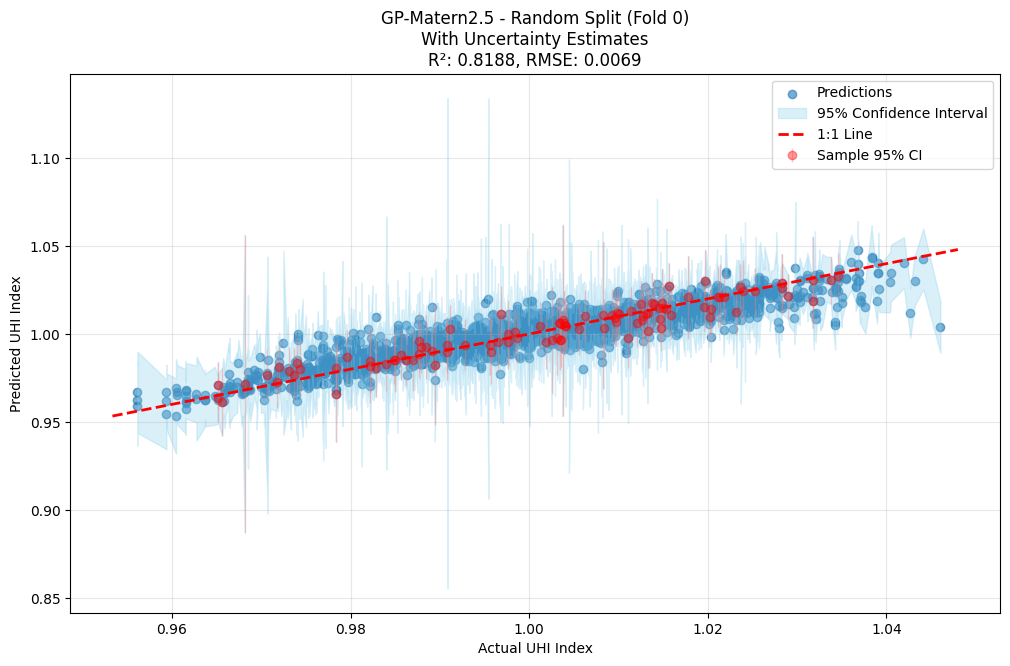

Uncertainty plot saved to: /content/drive/MyDrive/uhi/Code/Data/output/GP-Matern2p5_random_0_with_uncertainty_20250506_161803.png
Model saved to: /content/drive/MyDrive/uhi/Code/Data/models/run_20250506_161803/GP-Matern2p5/random_0.joblib
Metadata saved to: /content/drive/MyDrive/uhi/Code/Data/models/run_20250506_161803/GP-Matern2p5/random_0_metadata.json
Generating standard actual vs. predicted plot...


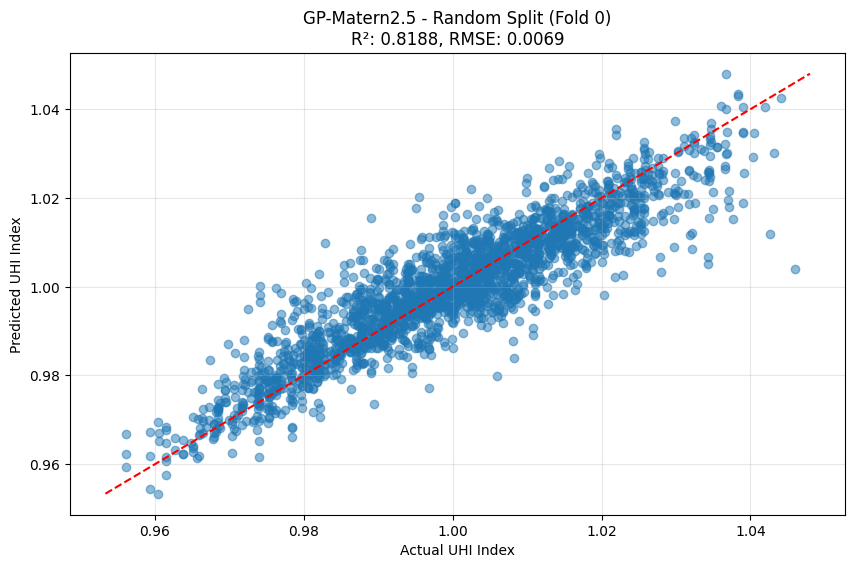

Standard plot saved to: /content/drive/MyDrive/uhi/Code/Data/output/GP-Matern2p5_random_0_actual_vs_pred_20250506_161803.png

GP-Matern2.5 training completed successfully!
R²: 0.8188
RMSE: 0.0069
Model saved to: /content/drive/MyDrive/uhi/Code/Data/models/run_20250506_161803/GP-Matern2p5/random_0.joblib


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, RBF, WhiteKernel, RationalQuadratic
from sklearn.metrics import mean_squared_error, r2_score
import joblib
import os
import json
import traceback
from datetime import datetime

model_name = "GP-Matern2.5"
split_type = "random"
fold_idx = 0

try:
    print(f"\n{'=' * 50}")
    print(f"Training {model_name} on {split_type} split (fold {fold_idx})...")
    print(f"{'=' * 50}")

    if split_type == 'random':
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42 + fold_idx)
    elif split_type == 'spatial':
        if 'coords' not in locals():
            raise NameError("The 'coords' variable is not defined. It is required for spatial split.")
        from sklearn.model_selection import GroupKFold
        tile_size = 0.01
        groups = ((coords[:, 0] // tile_size).astype(int) * 100000 +
                  (coords[:, 1] // tile_size).astype(int))
        gkf = GroupKFold(n_splits=5)
        splits = list(gkf.split(X, y, groups=groups))
        if fold_idx == 0:
            train_idx, test_idx = splits[0]
        elif fold_idx > 0 and fold_idx <= len(splits):
             train_idx, test_idx = splits[fold_idx-1]
        else:
            raise ValueError(f"Invalid fold_idx {fold_idx} for spatial split with {len(splits)} splits.")
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    else:
        raise ValueError(f"Unknown split_type: {split_type}")

    print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
    print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

    if isinstance(X_train, pd.DataFrame) and (X_train.isna().any().any() or X_test.isna().any().any()):
        print("Detected NaN values in the data split, handling them...")
        for col in X_train.columns:
            if pd.api.types.is_numeric_dtype(X_train[col]):
                col_mean_train = X_train[col].mean()
                X_train[col] = X_train[col].fillna(col_mean_train)
                X_test[col] = X_test[col].fillna(col_mean_train)

        if X_train.isna().any().any() or X_test.isna().any().any():
            print("Warning: Some NaN values could not be handled by mean imputation. Using dropna as a last resort.")
            X_train_before_dropna = X_train.shape[0]
            X_test_before_dropna = X_test.shape[0]
            X_train = X_train.dropna()
            y_train = y_train.loc[X_train.index]
            X_test = X_test.dropna()
            y_test = y_test.loc[X_test.index]
            print(f"Rows dropped from X_train: {X_train_before_dropna - X_train.shape[0]}")
            print(f"Rows dropped from X_test: {X_test_before_dropna - X_test.shape[0]}")

    if y_train.isna().any():
        print("NaNs found in y_train. Attempting to drop corresponding rows.")
        y_train = y_train.dropna()
        X_train = X_train.loc[y_train.index]
    if y_test.isna().any():
        print("NaNs found in y_test. Attempting to drop corresponding rows.")
        y_test = y_test.dropna()
        X_test = X_test.loc[y_test.index]

    print(f"Shapes after NaN handling: X_train: {X_train.shape}, y_train: {y_train.shape}, X_test: {X_test.shape}, y_test: {y_test.shape}")

    kernel_to_use = Matern(length_scale=1.0, nu=2.5, length_scale_bounds=(1e-5, 1e5)) + \
                    WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-5, 1e5))

    model = GaussianProcessRegressor(kernel=kernel_to_use, n_restarts_optimizer=5, random_state=42, alpha=1e-10)
    print(f"Initialized Gaussian Process model with Matérn(nu=2.5) kernel.")

    print("Starting model training...")
    model.fit(X_train, y_train)
    print("Model training completed.")

    print("Making predictions...")
    y_pred, y_std = model.predict(X_test, return_std=True)
    print("Predictions made.")

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mse)
    metrics = {'mse': float(mse), 'r2': float(r2), 'rmse': float(rmse)}
    print("\nMetrics calculated:")
    print(f"  R²: {r2:.4f}")
    print(f"  MSE: {mse:.4f}")
    print(f"  RMSE: {rmse:.4f}")

    print("Generating uncertainty plot...")
    plt.figure(figsize=(12, 7))
    plt.scatter(y_test, y_pred, alpha=0.6, label='Predictions')
    sort_idx = np.argsort(y_test.values.flatten())
    y_test_sorted = y_test.values.flatten()[sort_idx]
    y_pred_sorted = y_pred.flatten()[sort_idx]
    y_std_sorted = y_std.flatten()[sort_idx]
    lower_bound = y_pred_sorted - 2 * y_std_sorted
    upper_bound = y_pred_sorted + 2 * y_std_sorted
    plt.fill_between(y_test_sorted, lower_bound, upper_bound, color='skyblue', alpha=0.3, label='95% Confidence Interval')
    sample_size_for_error_bars = min(100, len(y_test))
    if sample_size_for_error_bars > 0:
        idx = np.random.choice(range(len(y_test)), size=sample_size_for_error_bars, replace=False)
        y_test_np = y_test.values if isinstance(y_test, pd.Series) else y_test
        plt.errorbar(y_test_np[idx], y_pred[idx], yerr=2*y_std[idx], fmt='o', alpha=0.4, color='red', ecolor='lightcoral', elinewidth=1, capsize=0, label='Sample 95% CI')
    plt.plot([min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())],
             [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())], 'r--', lw=2, label='1:1 Line')
    plt.xlabel('Actual UHI Index')
    plt.ylabel('Predicted UHI Index')
    plt.title(f"{model_name} - {split_type.capitalize()} Split (Fold {fold_idx})\nWith Uncertainty Estimates\nR²: {r2:.4f}, RMSE: {rmse:.4f}")
    plt.grid(True, alpha=0.3)
    plt.legend()
    uncertainty_plot_path = f"{OUTPUT_DIR}/{model_name.replace(' ', '_').replace('.', 'p')}_{split_type}_{fold_idx}_with_uncertainty_{timestamp}.png"
    plt.savefig(uncertainty_plot_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"Uncertainty plot saved to: {uncertainty_plot_path}")

    model_folder = f"{RUN_DIR}/{model_name.replace(' ', '_').replace('.', 'p')}"
    os.makedirs(model_folder, exist_ok=True)
    model_path = f"{model_folder}/{split_type}_{fold_idx}.joblib"
    joblib.dump(model, model_path)
    print(f"Model saved to: {model_path}")

    metadata_path = f"{model_folder}/{split_type}_{fold_idx}_metadata.json"

    kernel_params_for_json = {}
    if hasattr(model.kernel_, 'get_params'):
        params_dict = model.kernel_.get_params(deep=True)
        for key, value in params_dict.items():
            if isinstance(value, (str, int, float, bool, list, dict)) or value is None:
                kernel_params_for_json[key] = value
            else:
                kernel_params_for_json[key] = str(value)
    else:
        kernel_params_for_json = str(model.kernel_)


    metadata = {
        'model_name': model_name,
        'split_type': split_type,
        'fold_idx': fold_idx,
        'timestamp': timestamp,
        'metrics': metrics,
        'model_path': model_path,
        'plot_path': uncertainty_plot_path,
        'X_train_shape': list(X_train.shape),
        'X_test_shape': list(X_test.shape),
        'kernel_definition_initial': str(kernel_to_use),
        'optimized_kernel_parameters': kernel_params_for_json
    }
    with open(metadata_path, 'w') as f:
        json.dump(metadata, f, indent=2)
    print(f"Metadata saved to: {metadata_path}")

    print("Generating standard actual vs. predicted plot...")
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, y_pred, alpha=0.5)
    plt.plot([min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())],
             [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())], 'r--')
    plt.xlabel('Actual UHI Index')
    plt.ylabel('Predicted UHI Index')
    plt.title(f"{model_name} - {split_type.capitalize()} Split (Fold {fold_idx})\nR²: {r2:.4f}, RMSE: {rmse:.4f}")
    plt.grid(True, alpha=0.3)
    standard_plot_path = f"{OUTPUT_DIR}/{model_name.replace(' ', '_').replace('.', 'p')}_{split_type}_{fold_idx}_actual_vs_pred_{timestamp}.png"
    plt.savefig(standard_plot_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"Standard plot saved to: {standard_plot_path}")

    print(f"\n{model_name} training completed successfully!")
    print(f"R²: {metrics['r2']:.4f}")
    print(f"RMSE: {metrics['rmse']:.4f}")
    print(f"Model saved to: {model_path}")
    final_model = model
    final_metrics = metrics
    final_model_path = model_path

except Exception as e:
    error_msg = f"Error training {model_name}: {str(e)}"
    traceback_str = traceback.format_exc()
    print(f"\n{error_msg}")
    print(traceback_str)
    error_folder = f"{RUN_DIR}/errors"
    os.makedirs(error_folder, exist_ok=True)
    error_file_path = f"{error_folder}/{model_name.replace(' ', '_').replace('.', 'p')}_error_{timestamp}.txt"
    with open(error_file_path, 'w') as f:
        f.write(f"Error training {model_name} on {split_type} split (fold {fold_idx}) at {timestamp}:\n")
        f.write(str(e) + "\n\n")
        f.write(traceback_str)
    print(f"Error details saved to: {error_file_path}")
    final_model, final_metrics, final_model_path = None, None, None

# Dropout (NOT HERE)

In [ ]:
model_name = "MC Dropout"
split_type = "random"
fold_idx = 0

model, metrics, model_path = train_single_model(
    model_name=model_name,
    split_type=split_type,
    fold_idx=fold_idx
)

print(f"\n{model_name} training completed successfully!")
print(f"R²: {metrics['r2']:.4f}")
print(f"RMSE: {metrics['rmse']:.4f}")

In [ ]:
model_name = "MC Dropout Improved"
split_type = "random"
fold_idx = 0

model, metrics, model_path = train_single_model(
    model_name=model_name,
    split_type=split_type,
    fold_idx=fold_idx
)

print(f"\n{model_name} training completed successfully!")
print(f"R²: {metrics['r2']:.4f}")
print(f"RMSE: {metrics['rmse']:.4f}")

# More Probs

In [ ]:
model_name = "Bayesian NN"
split_type = "random"
fold_idx = 0

model, metrics, model_path = train_single_model(
    model_name=model_name,
    split_type=split_type,
    fold_idx=fold_idx
)

print(f"\n{model_name} training completed successfully!")
print(f"R²: {metrics['r2']:.4f}")
print(f"RMSE: {metrics['rmse']:.4f}")

In [ ]:
model_name = "Pretrained BNN"
split_type = "random"
fold_idx = 0

model, metrics, model_path = train_single_model(
    model_name=model_name,
    split_type=split_type,
    fold_idx=fold_idx
)

print(f"\n{model_name} training completed successfully!")
print(f"R²: {metrics['r2']:.4f}")
print(f"RMSE: {metrics['rmse']:.4f}")

In [ ]:
model_name = "Deep Ensemble"
split_type = "random"
fold_idx = 0

model, metrics, model_path = train_single_model(
    model_name=model_name,
    split_type=split_type,
    fold_idx=fold_idx
)

print(f"\n{model_name} training completed successfully!")
print(f"R²: {metrics['r2']:.4f}")
print(f"RMSE: {metrics['rmse']:.4f}")

In [ ]:
model_name = "Quantile RF"
split_type = "random"
fold_idx = 0

model, metrics, model_path = train_single_model(
    model_name=model_name,
    split_type=split_type,
    fold_idx=fold_idx
)

print(f"\n{model_name} training completed successfully!")
print(f"R²: {metrics['r2']:.4f}")
print(f"RMSE: {metrics['rmse']:.4f}")